# Taller B3-T4 — Investigación
# Preprocesado López de Prado (5 Técnicas) + Clasificación Binaria

Siguiendo a **Marcos López de Prado** (*Advances in Financial Machine Learning*, 2018), la predicción financiera se plantea como un problema de **clasificación**, no de regresión:
- **Objetivo**: predecir si cada activo alcanzará su barrera de take-profit antes del stop-loss (UP=1) o no (DOWN/NEUTRAL=0)
- **Loss**: Binary Cross-Entropy
- **Métrica principal**: Accuracy

| # | Técnica | Aplicación |
|---|---|---|
| 1 | **Event-Based Bars** | Dollar Bars sobre volumen diario de 23 activos (comparativa) |
| 2 | **FFD** | Features de entrada con d* por activo, preservando memoria |
| 3 | **RMT** | Covarianza 23×23 limpia para construcción de carteras |
| 4 | **Triple Barrera** | Genera las **etiquetas Y** de clasificación |
| 5 | **Purged K-Fold** | Validación cruzada sin data leakage |


## 1. Imports y configuración

In [1]:
!pip install yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, os

import yfinance as yf

import tensorflow as tf
import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, BatchNormalization, Input, Add, Activation
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

from scipy import stats
from scipy.linalg import eigh
from scipy.optimize import minimize_scalar, minimize
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

os.makedirs('figuras_inv', exist_ok=True)
os.makedirs('figuras_inv/convergencia', exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

print(f'TF {tf.__version__} | GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


TF 2.21.0 | GPU: False


## 2. Carga de datos OHLCV (desde 1960, con volumen para Dollar Bars)

In [2]:
TICKERS = [
    'AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE',
    'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK',
    'MSI', 'PG', 'XOM'
]

# Datos desde 1960, igual que el notebook de competición
raw_data   = yf.download(TICKERS, start='1960-01-01', end='2024-12-31',
                         auto_adjust=True, progress=True)
close_raw  = raw_data['Close'].dropna(axis=1)
volume_raw = raw_data['Volume'][close_raw.columns].fillna(0)

TICKERS  = list(close_raw.columns)
N_ASSETS = len(TICKERS)

log_prices_daily = np.log(close_raw)              # log-precios diarios
returns_daily    = log_prices_daily.diff().dropna()  # retornos log diarios

# Datos 2025 para carteras
raw_2025     = yf.download(TICKERS, start='2025-01-01', auto_adjust=True, progress=True)
close_2025   = raw_2025['Close'][TICKERS].dropna(axis=1)
returns_2025 = np.log(close_2025).diff().dropna()
TICKERS_2025 = list(close_2025.columns)

print(f'Activos : {N_ASSETS}')
print(f'Periodo : {close_raw.index[0].date()} → {close_raw.index[-1].date()}')
print(f'Retornos diarios : {returns_daily.shape}   # ~16.000 días × 23 activos')
print(f'Datos 2025       : {returns_2025.shape}')

[*********************100%***********************]  23 of 23 completed
[*********************100%***********************]  23 of 23 completed

Activos : 23
Periodo : 1962-01-02 → 2024-12-30
Retornos diarios : (15856, 23)   # ~16.000 días × 23 activos
Datos 2025       : (341, 23)


## Técnica 1 — Event-Based Bars: Dollar Bars

Las **Dollar Bars** (López de Prado, Cap. 2) se forman cada vez que el dollar volume total acumulado supera un umbral. A diferencia de las time bars (1 barra = 1 día), las dollar bars son **más uniformes en actividad económica** y producen retornos con menor kurtosis.

> **Nota**: esta técnica se usa para la **comparativa estadística**. El pipeline de entrenamiento (T2→T5) trabaja sobre los **datos diarios** para mantener suficientes muestras (~16.000) para las 16 combinaciones de ventanas.

Time Bars   :  15856 barras  (datos diarios 1960-2024)
Dollar Bars :   6091 barras  (target=10000)


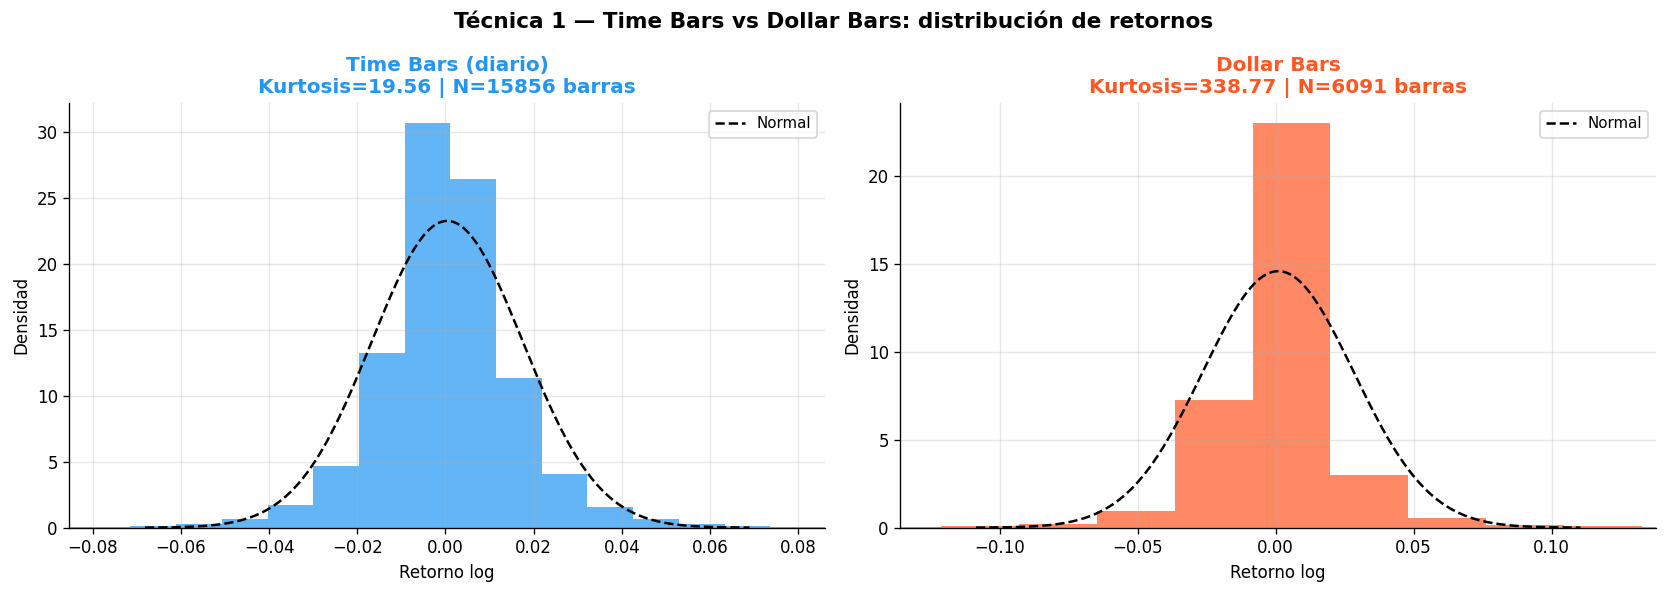


✓ Pipeline de entrenamiento: datos DIARIOS (1960-2024)


In [4]:
def build_dollar_bars(close_df, volume_df, n_bars_target=2000):
    """
    Agrupa días consecutivos hasta acumular $threshold en dollar volume total.
    Cada barra es el último precio de cierre del grupo.
    """
    dv        = (close_df * volume_df).sum(axis=1)
    dv        = dv[dv > 0]
    threshold = dv.sum() / n_bars_target
    bar_ids   = (dv.cumsum() // threshold).astype(int)

    aligned_close  = close_df.reindex(dv.index)
    close_bars = aligned_close.groupby(bar_ids).last()
    dates_bars = aligned_close.index.to_series().groupby(bar_ids).last()
    close_bars.index = dates_bars.values
    return close_bars


N_BARS_TARGET     = 10000
dollar_bars_close = build_dollar_bars(close_raw, volume_raw, N_BARS_TARGET)
ret_dollar        = np.log(dollar_bars_close).diff().dropna()
ret_time          = returns_daily

print(f'Time Bars   : {len(ret_time):>6} barras  (datos diarios 1960-2024)')
print(f'Dollar Bars : {len(ret_dollar):>6} barras  (target={N_BARS_TARGET})')

# Comparativa estadística
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Técnica 1 — Time Bars vs Dollar Bars: distribución de retornos',
             fontsize=13, fontweight='bold')

for ax, (ret, label, color) in zip(axes, [
    (ret_time,   'Time Bars (diario)',  COLORS[0]),
    (ret_dollar, 'Dollar Bars',         COLORS[1]),
]):
    flat = ret.values.flatten(); flat = flat[np.isfinite(flat)]
    ax.hist(flat, bins=100, density=True, alpha=0.7, color=color, edgecolor='none')
    mu, sig = flat.mean(), flat.std()
    x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
    ax.plot(x, stats.norm.pdf(x, mu, sig), 'k--', lw=1.5, label='Normal')
    kurt = stats.kurtosis(flat, fisher=True)
    ax.set_title(f'{label}\nKurtosis={kurt:.2f} | N={len(ret)} barras',
                 fontweight='bold', color=color)
    ax.set_xlabel('Retorno log'); ax.set_ylabel('Densidad')
    ax.set_xlim(mu - 5*sig, mu + 5*sig); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('figuras_inv/t1_dollar_bars.png', dpi=120, bbox_inches='tight')
plt.show()

# El pipeline de entrenamiento usa datos DIARIOS
close_base      = close_raw.copy()
log_prices_base = log_prices_daily.copy()
print('\n✓ Pipeline de entrenamiento: datos DIARIOS (1960-2024)')

## Técnica 2 — Diferenciación Fraccional (FFD)

Los log-precios diarios **no son estacionarios** (d=0). Los retornos simples (d=1) son estacionarios pero **pierden toda la memoria histórica de precios**, que puede ser información útil para el modelo.

La **FFD** encuentra el `d*` mínimo por activo que logra estacionariedad ADF (p<0.05), preservando el máximo de memoria. Las series FFD serán las **features X** del modelo.

In [5]:
def get_ffd_weights(d, thres=1e-5):
    w = [1.0]; k = 1
    while True:
        wk = -w[-1] * (d - k + 1) / k
        if abs(wk) < thres: break
        w.append(wk); k += 1
    return np.array(w[::-1])

def frac_diff_ffd(series, d, thres=1e-5):
    w = get_ffd_weights(d, thres); width = len(w)
    vals = series.values.astype(float)
    out  = np.full(len(vals), np.nan)
    for i in range(width - 1, len(vals)):
        out[i] = np.dot(w, vals[i - width + 1 : i + 1])
    return pd.Series(out, index=series.index)

def find_d_star(series, adf_pval=0.05):
    for d in np.round(np.arange(0.05, 1.05, 0.05), 2):
        ffd = frac_diff_ffd(series, d).dropna()
        if len(ffd) < 30: continue
        if adfuller(ffd, maxlag=1, regression='c', autolag=None)[1] < adf_pval:
            return d
    return 1.0

print('Buscando d* para cada activo (datos diarios 1960-2024)...')
d_star_dict = {t: find_d_star(log_prices_base[t])
               for t in TICKERS if t in log_prices_base.columns}
d_star_s = pd.Series(d_star_dict, name='d*')
print(f'Media d* = {d_star_s.mean():.3f} | Mediana = {d_star_s.median():.3f}')
print(d_star_s.sort_values().to_string())

# Aplicar FFD
ffd_df = pd.DataFrame(
    {t: frac_diff_ffd(log_prices_base[t], d_star_dict[t]) for t in d_star_dict}
).dropna()

print(f'\n✓ FFD aplicado. Shape: {ffd_df.shape}')
print(f'  Periodo FFD: {ffd_df.index[0].date()} → {ffd_df.index[-1].date()}')

Buscando d* para cada activo (datos diarios 1960-2024)...
Media d* = 0.204 | Mediana = 0.200
ED     0.05
IP     0.10
HPQ    0.15
BA     0.15
MSI    0.15
CNP    0.20
CAT    0.20
CVX    0.20
IBM    0.20
DIS    0.20
HON    0.20
GE     0.20
KR     0.20
AEP    0.20
DTE    0.25
GD     0.25
KO     0.25
JNJ    0.25
MRK    0.25
MMM    0.25
XOM    0.25
PG     0.25
MO     0.30

✓ FFD aplicado. Shape: (11782, 23)
  Periodo FFD: 1978-04-10 → 2024-12-30


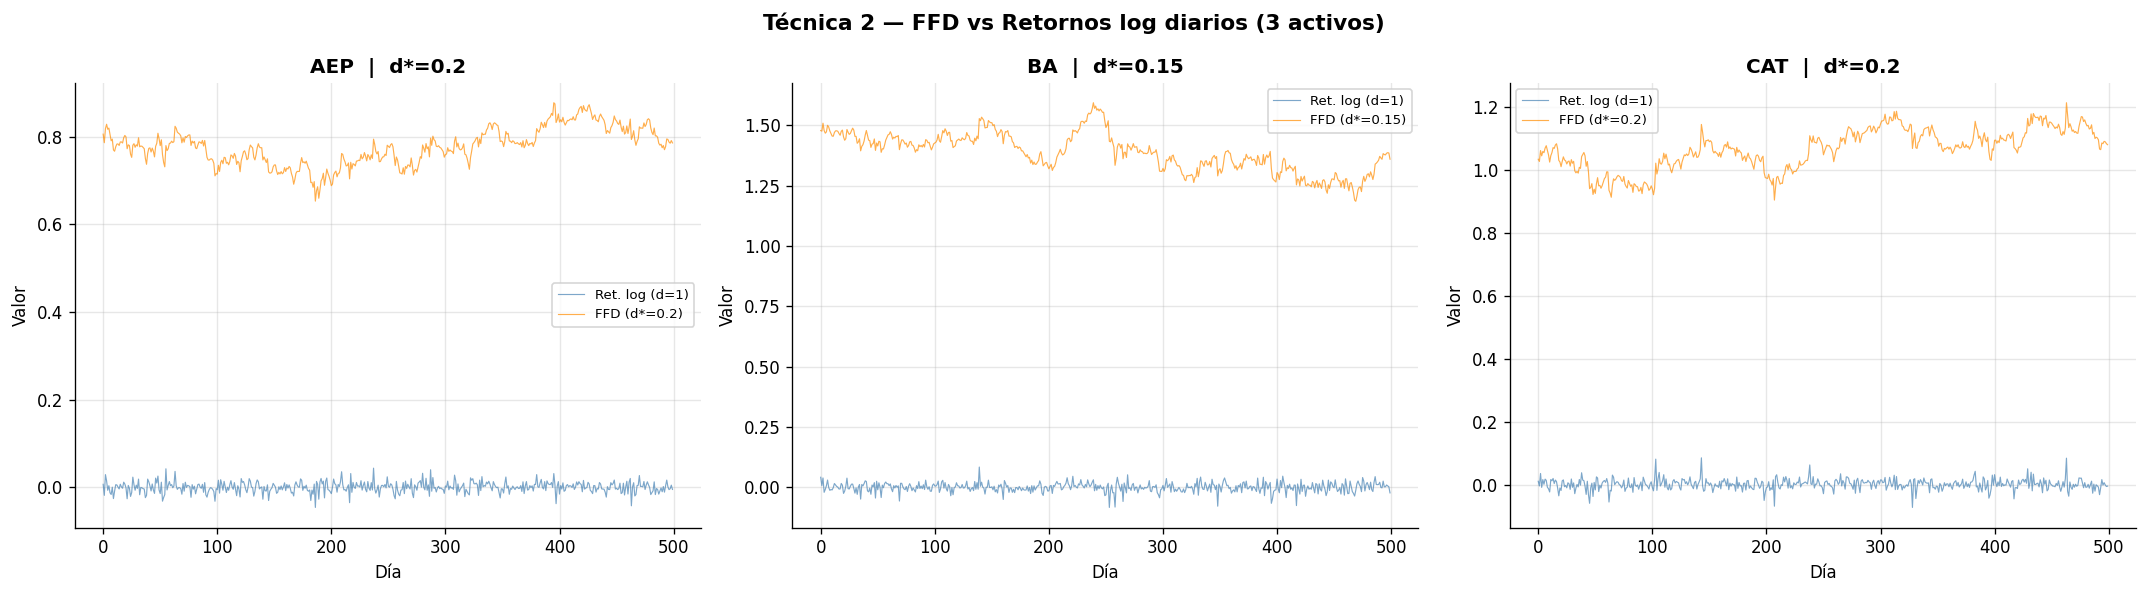

In [6]:
# Visualización FFD vs retornos brutos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Técnica 2 — FFD vs Retornos log diarios (3 activos)',
             fontsize=13, fontweight='bold')
for i, ticker in enumerate(TICKERS[:3]):
    if ticker not in ffd_df.columns: continue
    ax = axes[i]; d = d_star_dict[ticker]; n = min(500, len(ffd_df))
    ret_aln = returns_daily[ticker].reindex(ffd_df.index)
    ax.plot(range(n), ret_aln.iloc[-n:].values,
            color='steelblue', lw=0.7, alpha=0.7, label='Ret. log (d=1)')
    ax.plot(range(n), ffd_df[ticker].iloc[-n:].values,
            color='darkorange', lw=0.7, alpha=0.7, label=f'FFD (d*={d})')
    ax.set_title(f'{ticker}  |  d*={d}', fontweight='bold')
    ax.set_xlabel('Día'); ax.set_ylabel('Valor'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('figuras_inv/t2_ffd.png', dpi=120, bbox_inches='tight')
plt.show()

## Técnica 3 — Limpieza de Covarianza Ruidosa (RMT)

La mayoría de eigenvalores de la covarianza empírica 23×23 son **ruido estadístico** que sigue la distribución de **Marchenko-Pastur**. El clipping RMT da una covarianza más estable para la optimización de carteras.

RMT — q=689.4 | σ²=1.993797 | λ_max=2.148561
Eigenvalores señal: 1/23


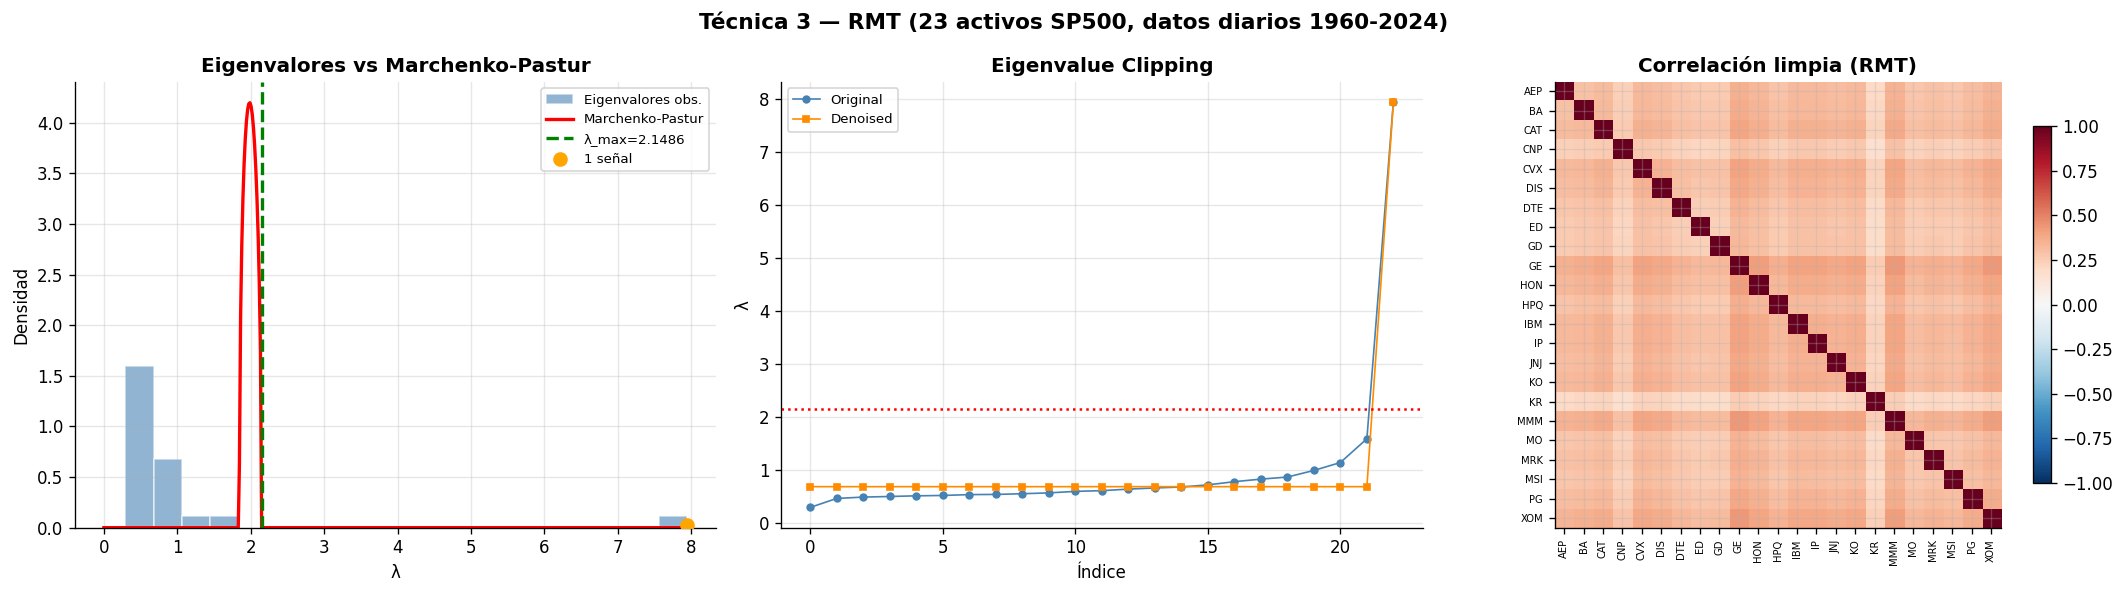

In [7]:
def marchenko_pastur_pdf(sigma2, q, x):
    lp = sigma2*(1 + 1/np.sqrt(q))**2; lm = sigma2*(1 - 1/np.sqrt(q))**2
    x = np.atleast_1d(x).astype(float); pdf = np.zeros_like(x)
    mask = (x >= lm) & (x <= lp)
    if mask.any():
        xm = x[mask]
        pdf[mask] = (q/(2*np.pi*sigma2)) * np.sqrt(
            np.clip((lp - xm)*(xm - lm), 0, None)) / xm
    return pdf, lp, lm

def fit_sigma2(evals, q):
    def loss(s2):
        if s2 <= 0: return 1e10
        x = np.linspace(evals.min()+1e-8, evals.max(), 500)
        pt, _, _ = marchenko_pastur_pdf(s2, q, x)
        try: po = stats.gaussian_kde(evals, bw_method=0.3)(x)
        except: return 1e10
        return np.sum((po - pt)**2)
    return minimize_scalar(loss, bounds=(1e-4, 2.0), method='bounded').x

def denoise_covariance(cov, q, alpha=1.0):
    std = np.sqrt(np.diag(cov)); std = np.where(std > 1e-12, std, 1.0)
    corr = cov / np.outer(std, std)
    evals, evecs = eigh(corr); evals = np.maximum(evals, 0)
    sigma2 = fit_sigma2(evals, q)
    _, lp, _ = marchenko_pastur_pdf(sigma2, q, evals)
    noise = evals <= lp; ec = evals.copy()
    if noise.any(): ec[noise] = (1-alpha)*evals[noise] + alpha*evals[noise].mean()
    corr_c = evecs @ np.diag(ec) @ evecs.T; np.fill_diagonal(corr_c, 1.0)
    cov_c = corr_c * np.outer(std, std)
    return cov_c, lp, sigma2, int((~noise).sum()), evals, ec

# Aplicar RMT sobre retornos diarios
cov_noisy = np.cov(returns_daily.values.T)
q_rmt = len(returns_daily) / N_ASSETS
cov_clean, lam_plus, sigma2_fit, n_signal, evals_orig, evals_clean_arr = \
    denoise_covariance(cov_noisy, q_rmt)

print(f'RMT — q={q_rmt:.1f} | σ²={sigma2_fit:.6f} | λ_max={lam_plus:.6f}')
print(f'Eigenvalores señal: {n_signal}/{N_ASSETS}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Técnica 3 — RMT (23 activos SP500, datos diarios 1960-2024)',
             fontsize=13, fontweight='bold')

ax = axes[0]
x_r = np.linspace(1e-6, max(evals_orig.max(), lam_plus*1.3), 500)
mp, _, _ = marchenko_pastur_pdf(sigma2_fit, q_rmt, x_r)
ax.hist(evals_orig, bins=20, density=True, alpha=0.6,
        color='steelblue', edgecolor='white', label='Eigenvalores obs.')
ax.plot(x_r, mp, 'r-', lw=2, label=f'Marchenko-Pastur')
ax.axvline(lam_plus, color='green', ls='--', lw=2, label=f'λ_max={lam_plus:.4f}')
sig_ev = evals_orig[evals_orig > lam_plus]
ax.scatter(sig_ev, [0.03]*len(sig_ev), color='orange', s=60, zorder=5,
           label=f'{len(sig_ev)} señal')
ax.set_title('Eigenvalores vs Marchenko-Pastur', fontweight='bold')
ax.set_xlabel('λ'); ax.set_ylabel('Densidad'); ax.legend(fontsize=8)

ax = axes[1]
idx_s = np.argsort(evals_orig)
ax.plot(evals_orig[idx_s], 'o-', color='steelblue', ms=4, lw=1, label='Original')
ax.plot(evals_clean_arr[idx_s], 's-', color='darkorange', ms=4, lw=1, label='Denoised')
ax.axhline(lam_plus, color='red', ls=':', lw=1.5)
ax.set_title('Eigenvalue Clipping', fontweight='bold')
ax.set_xlabel('Índice'); ax.set_ylabel('λ'); ax.legend(fontsize=8)

ax = axes[2]
std_d = np.sqrt(np.diag(cov_clean))
corr_c_plot = cov_clean / np.outer(std_d, std_d)
im = ax.imshow(corr_c_plot, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(N_ASSETS)); ax.set_yticks(range(N_ASSETS))
ax.set_xticklabels(TICKERS, rotation=90, fontsize=6)
ax.set_yticklabels(TICKERS, fontsize=6)
ax.set_title('Correlación limpia (RMT)', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('figuras_inv/t3_rmt.png', dpi=120, bbox_inches='tight')
plt.show()

## Técnica 4 — Etiquetado por Triple Barrera

**La técnica central de López de Prado** para clasificación financiera. Convierte cada barra en una etiqueta:
- **+1** (Take-Profit): el precio sube `pt×σ` antes de expirar → clase UP
- **−1** (Stop-Loss): el precio baja `sl×σ` antes de expirar → clase DOWN  
- **0** (Expira): tiempo máximo agotado sin señal clara → NEUTRAL

Para la **clasificación binaria** mapeamos: **UP=1**, DOWN o NEUTRAL=0.

**Adaptación multi-activo**: se aplica por activo independientemente. El `output_window` de cada combinación define el horizonte temporal de la barrera (n_bars=out_w).

In [8]:
def get_ewma_vol(close_series, span=20):
    return np.log(close_series / close_series.shift(1)).dropna().ewm(span=span).std()

def triple_barrier_label(close_series, vol_series, pt_mult=1.5, sl_mult=1.5, n_bars=20):
    """
    Etiqueta cada barra con {-1, 0, +1}.
    n_bars = horizonte temporal máximo (= output_window en el bucle de entrenamiento).
    """
    close_arr = close_series.values
    vol_arr   = vol_series.reindex(close_series.index).ffill().bfill().values
    labels    = np.zeros(len(close_arr), dtype=int)
    for i in range(len(close_arr) - n_bars):
        p0 = close_arr[i]; vol = vol_arr[i]
        if vol <= 0 or np.isnan(vol): continue
        upper = p0 * (1 + pt_mult * vol)
        lower = p0 * (1 - sl_mult * vol)
        for j in range(1, n_bars + 1):
            p = close_arr[i + j]
            if p >= upper:   labels[i] = 1;  break
            elif p <= lower: labels[i] = -1; break
    return pd.Series(labels, index=close_series.index)

PT_MULT = 1.5
SL_MULT = 1.5

# Precomputar etiquetas triple barrera para cada output_window
# (cada out_w define el horizonte de la barrera temporal)
OUTPUT_WINDOWS = [1, 5, 30, 90]

print('Precomputando etiquetas de Triple Barrera para cada output_window...')
print('(esto puede tardar 2-3 minutos)\n')

tb_labels = {}  # {out_w: DataFrame(index=dates, columns=TICKERS)}
for out_w in OUTPUT_WINDOWS:
    labels_outw = {}
    for ticker in TICKERS:
        if ticker not in close_base.columns: continue
        vol = get_ewma_vol(close_base[ticker], span=20)
        labels_outw[ticker] = triple_barrier_label(
            close_base[ticker], vol, PT_MULT, SL_MULT, n_bars=out_w
        )
    tb_labels[out_w] = pd.DataFrame(labels_outw)

    df = tb_labels[out_w]
    up  = (df == 1).mean().mean() * 100
    dn  = (df == -1).mean().mean() * 100
    neu = (df == 0).mean().mean() * 100
    print(f'  out_w={out_w:2d}d  → UP={up:.1f}%  DOWN={dn:.1f}%  NEUTRAL={neu:.1f}%')

print('\n✓ Etiquetas triple barrera precomputadas.')

Precomputando etiquetas de Triple Barrera para cada output_window...
(esto puede tardar 2-3 minutos)

  out_w= 1d  → UP=7.6%  DOWN=6.2%  NEUTRAL=86.2%
  out_w= 5d  → UP=36.1%  DOWN=30.9%  NEUTRAL=33.1%
  out_w=30d  → UP=53.7%  DOWN=45.6%  NEUTRAL=0.7%
  out_w=90d  → UP=53.8%  DOWN=45.6%  NEUTRAL=0.6%

✓ Etiquetas triple barrera precomputadas.


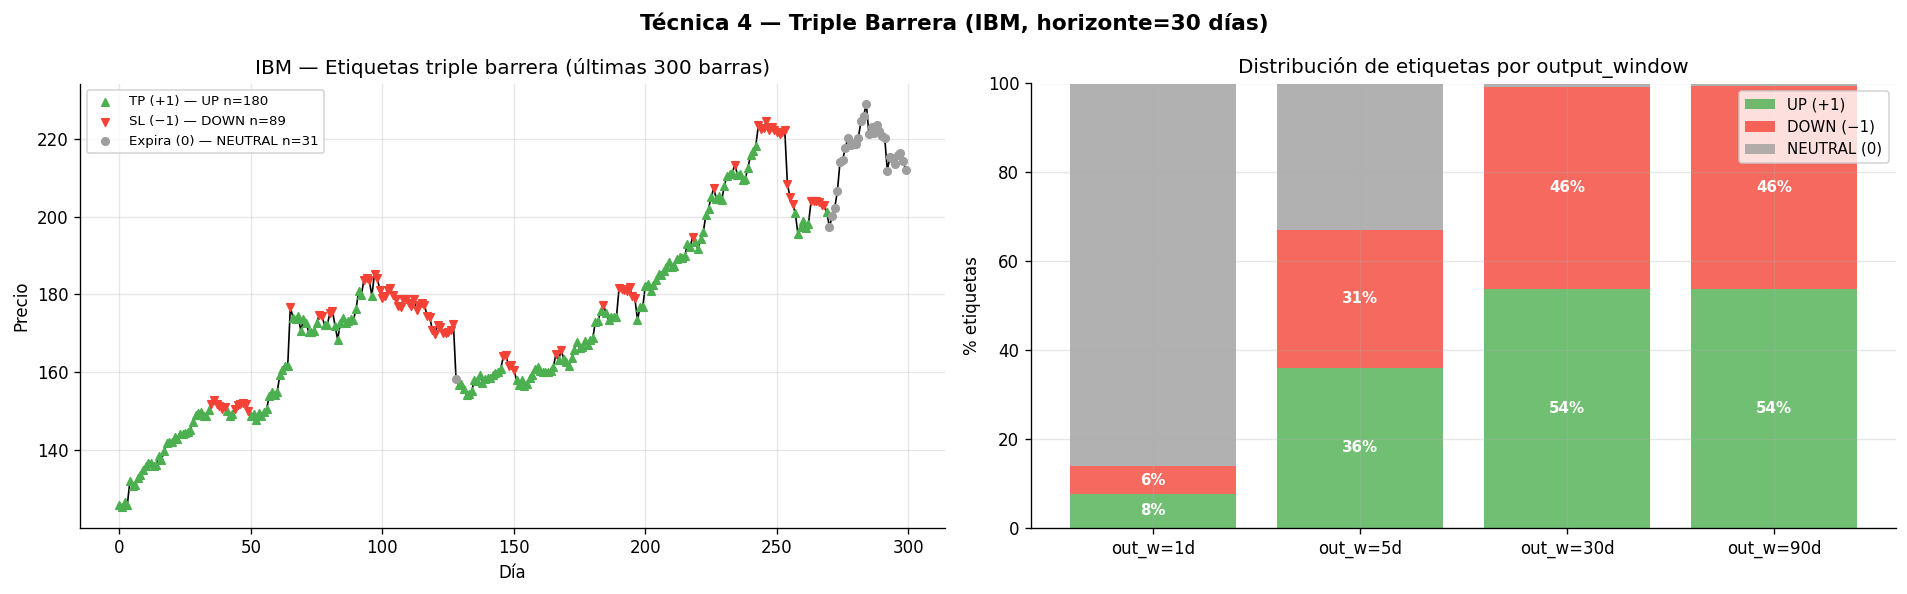

In [9]:
# Visualización triple barrera (ejemplo con out_w=20, IBM)
ticker_ex = 'IBM' if 'IBM' in TICKERS else TICKERS[0]
labels_20 = tb_labels.get(30, tb_labels[OUTPUT_WINDOWS[2]])
n_show    = min(300, len(close_base))
px_show   = close_base[ticker_ex].iloc[-n_show:]
lbl_show  = labels_20[ticker_ex].reindex(px_show.index).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Técnica 4 — Triple Barrera (IBM, horizonte=30 días)',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(range(n_show), px_show.values, 'k-', lw=1, zorder=1)
for lbl, color, marker, name in [
    (1,  '#4CAF50', '^', 'TP (+1) — UP'),
    (-1, '#F44336', 'v', 'SL (−1) — DOWN'),
    (0,  '#9E9E9E', 'o', 'Expira (0) — NEUTRAL')
]:
    mask = lbl_show.values == lbl
    if mask.any():
        ax.scatter(np.where(mask)[0], px_show.values[mask],
                   color=color, marker=marker, s=20, zorder=3,
                   label=f'{name} n={mask.sum()}')
ax.set_title(f'{ticker_ex} — Etiquetas triple barrera (últimas {n_show} barras)')
ax.set_xlabel('Día'); ax.set_ylabel('Precio'); ax.legend(fontsize=8)

ax = axes[1]
out_ws_plot = OUTPUT_WINDOWS
up_rates  = [(tb_labels[w] == 1).mean().mean() * 100 for w in out_ws_plot]
dn_rates  = [(tb_labels[w] == -1).mean().mean() * 100 for w in out_ws_plot]
neu_rates = [(tb_labels[w] == 0).mean().mean() * 100 for w in out_ws_plot]
x_pos = range(len(out_ws_plot))
ax.bar(x_pos, up_rates,  label='UP (+1)',      color='#4CAF50', alpha=0.8)
ax.bar(x_pos, dn_rates,  bottom=up_rates, label='DOWN (−1)', color='#F44336', alpha=0.8)
ax.bar(x_pos, neu_rates, bottom=[u+d for u,d in zip(up_rates, dn_rates)],
       label='NEUTRAL (0)', color='#9E9E9E', alpha=0.8)
ax.set_xticks(list(x_pos))
ax.set_xticklabels([f'out_w={w}d' for w in out_ws_plot])
ax.set_ylabel('% etiquetas'); ax.set_ylim(0, 100)
ax.set_title('Distribución de etiquetas por output_window')
ax.legend(fontsize=9)
for i, (u, d, n) in enumerate(zip(up_rates, dn_rates, neu_rates)):
    ax.text(i, u/2, f'{u:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    ax.text(i, u + d/2, f'{d:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('figuras_inv/t4_triple_barrera.png', dpi=120, bbox_inches='tight')
plt.show()

## Técnica 5 — Purged K-Fold Cross-Validation

Las ventanas de entrada solapadas crean correlación serial entre muestras consecutivas. El **Purged K-Fold** elimina del train las muestras dentro de `embargo = input_window` índices del borde del test, previniendo data leakage.

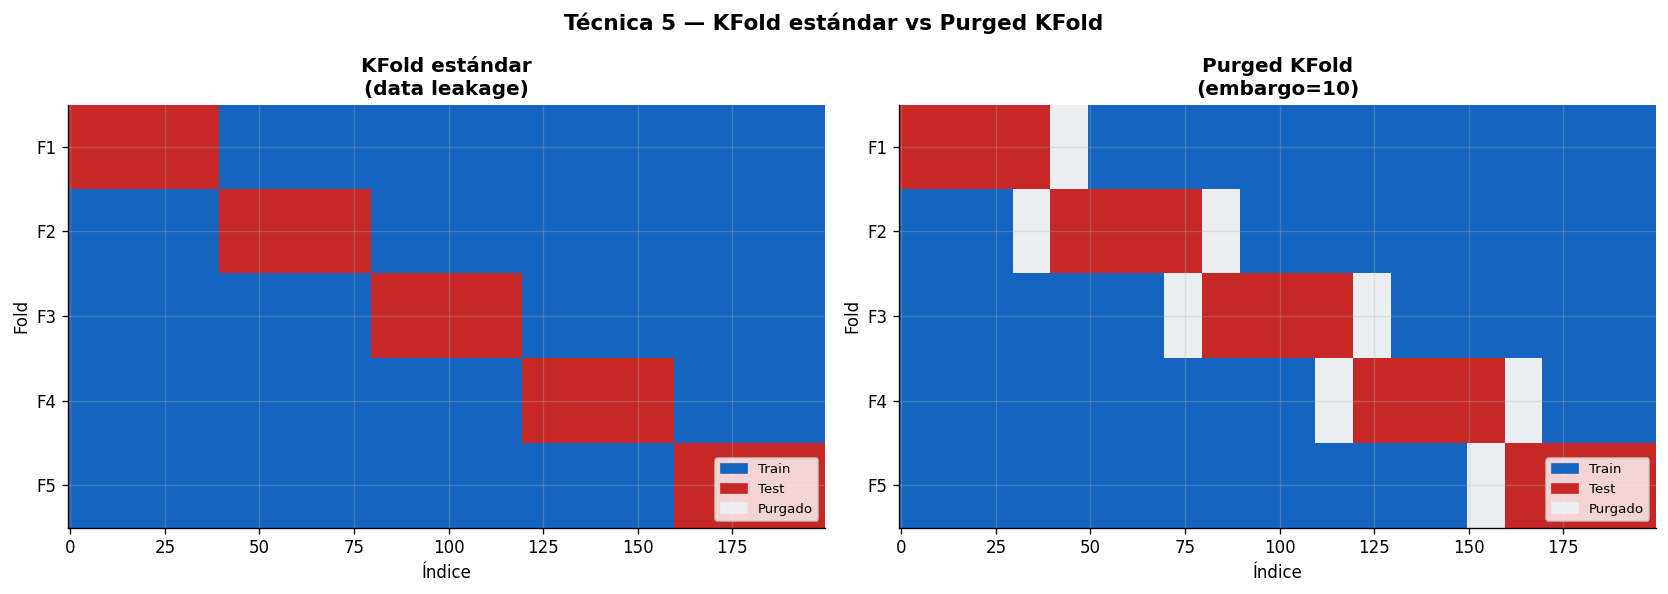

✓ Purged K-Fold implementado.


In [10]:
class PurgedKFold:
    def __init__(self, n_splits=5, embargo=0):
        self.n_splits = n_splits
        self.embargo  = embargo

    def split(self, X):
        n = len(X); idx = np.arange(n); fs = n // self.n_splits
        for k in range(self.n_splits):
            ts = k * fs; te = (k+1)*fs if k < self.n_splits-1 else n
            ps = max(0, ts - self.embargo); pe = min(n, te + self.embargo)
            yield np.concatenate([idx[:ps], idx[pe:]]), idx[ts:te]

from sklearn.model_selection import KFold as SKFold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Técnica 5 — KFold estándar vs Purged KFold', fontsize=13, fontweight='bold')
n_demo = 200; X_demo = np.arange(n_demo)
for ax, (label, splits) in zip(axes, [
    ('KFold estándar\n(data leakage)', list(SKFold(n_splits=5, shuffle=False).split(X_demo))),
    ('Purged KFold\n(embargo=10)',     list(PurgedKFold(n_splits=5, embargo=10).split(X_demo)))
]):
    mat = np.zeros((5, n_demo), dtype=int)
    for k, (tr, ts) in enumerate(splits): mat[k, tr] = 1; mat[k, ts] = 2
    cmap = plt.cm.colors.ListedColormap(['#ECEFF1', '#1565C0', '#C62828'])
    ax.imshow(mat, cmap=cmap, aspect='auto', vmin=0, vmax=2)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Índice'); ax.set_ylabel('Fold')
    ax.set_yticks(range(5)); ax.set_yticklabels([f'F{k+1}' for k in range(5)])
    patches = [mpatches.Patch(color='#1565C0', label='Train'),
               mpatches.Patch(color='#C62828', label='Test'),
               mpatches.Patch(color='#ECEFF1', label='Purgado')]
    ax.legend(handles=patches, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('figuras_inv/t5_purged_kfold.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ Purged K-Fold implementado.')

## Pipeline completo — Resumen

```
Precios OHLCV diarios (23 activos SP500, 1960-2024, ~16.000 días)
         │
[T1] Dollar Bars   ← comparativa estadística (menor kurtosis)
         │
[T2] FFD (d*)      ← X = features estacionarias con memoria
         │                 d* mínimo por activo (ADF p<0.05)
         │
[T3] RMT           ← covarianza 23×23 denoised → carteras
         │
[T4] Triple Barrera ← Y = etiqueta binaria {UP=1, DOWN/NEUTRAL=0}
         │             horizonte = output_window días
         │
[T5] Purged K-Fold  ← validación sin leakage, embargo=input_window
         │
    Clasificación binaria (7 MLP × 16 combinaciones)
    Loss: Binary Cross-Entropy | Métrica: Accuracy
```

## 6. Función de clasificación y modelos MLP

### Cambio clave respecto a la competición
| | Competición | Investigación (López de Prado) |
|---|---|---|
| **Y** | Retorno futuro promedio (float) | Etiqueta triple barrera {0, 1} (binary) |
| **Loss** | MAE | Binary Cross-Entropy |
| **Métrica** | MAE (↓ mejor) | Accuracy (↑ mejor) |
| **Activación salida** | Linear | Sigmoid |
| **Baseline** | Buy & Hold (media ventana) | Historical UP rate |

In [11]:
def create_classification_data(ffd_data, labels_data, input_window, output_window):
    """
    Construye ventanas de clasificación alineando FFD (X) con triple barrera (Y).

    X[i] = FFD features de los días [i, i+input_window)
    Y[i] = etiqueta binaria de triple barrera en el día i+input_window
           (lo que ocurre DESPUÉS de la ventana de entrada, con horizonte=output_window)
           1 = UP (hit take-profit),  0 = DOWN o NEUTRAL

    La triple barrera ya tiene encoded el horizonte output_window en sus etiquetas.
    """
    ffd_arr = ffd_data.values if isinstance(ffd_data, pd.DataFrame) else ffd_data
    # Alinear etiquetas al índice FFD
    lbl_arr = labels_data.reindex(ffd_data.index).fillna(0).values  # (T, 23)

    n = min(len(ffd_arr), len(lbl_arr))
    ffd_arr = ffd_arr[:n]; lbl_arr = lbl_arr[:n]

    X_out, y_out = [], []
    for i in range(n - input_window - output_window + 1):
        X_out.append(ffd_arr[i : i + input_window])            # (in_w, 23)
        # Etiqueta en el primer día del futuro (después de la ventana de entrada)
        label_raw = lbl_arr[i + input_window]                  # (23,)
        y_binary  = (label_raw == 1).astype(float)             # 1=UP, 0=DOWN/NEUTRAL
        y_out.append(y_binary)

    return np.array(X_out), np.array(y_out)  # shapes: (N, in_w, 23), (N, 23)


def accuracy_score(y_true, y_pred_prob, threshold=0.5):
    """Accuracy binaria: fracción de predicciones correctas sobre todos los activos."""
    y_pred = (y_pred_prob > threshold).astype(float)
    return float(np.mean(y_pred == y_true))


print('✓ Función de clasificación definida.')

✓ Función de clasificación definida.


In [12]:
# ── Modelos MLP para clasificación binaria ────────────────────
# Diferencias vs competición:
#   - Activación de salida: sigmoid (en lugar de linear)
#   - Loss: binary_crossentropy (en lugar de MAE)
#   - Métrica: binary_accuracy

def build_mlp_shallow(d, o):
    m = Sequential([Dense(128, activation='relu', input_dim=d),
                    Dense(o, activation='sigmoid')], name='MLP_Shallow')
    m.compile(loss='binary_crossentropy', optimizer=Adam(1e-3),
              metrics=['binary_accuracy'])
    return m

def build_mlp_medium(d, o):
    m = Sequential([Dense(256, activation='relu', input_dim=d),
                    Dense(128, activation='relu'),
                    Dense(o, activation='sigmoid')], name='MLP_Medium')
    m.compile(loss='binary_crossentropy', optimizer=Adam(1e-3),
              metrics=['binary_accuracy'])
    return m

def build_mlp_deep(d, o):
    m = Sequential([Dense(512, activation='relu', input_dim=d),
                    Dense(256, activation='relu'),
                    Dense(128, activation='relu'),
                    Dense(64,  activation='relu'),
                    Dense(o, activation='sigmoid')], name='MLP_Deep')
    m.compile(loss='binary_crossentropy', optimizer=Adam(5e-4),
              metrics=['binary_accuracy'])
    return m

def build_mlp_dropout(d, o):
    m = Sequential([Dense(256, activation='relu', input_dim=d), Dropout(0.3),
                    Dense(256, activation='relu'), Dropout(0.3),
                    Dense(128, activation='relu'), Dropout(0.2),
                    Dense(o, activation='sigmoid')], name='MLP_Dropout')
    m.compile(loss='binary_crossentropy', optimizer=Adam(1e-3),
              metrics=['binary_accuracy'])
    return m

def build_mlp_batchnorm(d, o):
    m = Sequential([Dense(256, activation='relu', input_dim=d), BatchNormalization(),
                    Dense(256, activation='relu'), BatchNormalization(),
                    Dense(128, activation='relu'), BatchNormalization(),
                    Dense(o, activation='sigmoid')], name='MLP_BatchNorm')
    m.compile(loss='binary_crossentropy', optimizer=Adam(1e-3),
              metrics=['binary_accuracy'])
    return m

def build_mlp_wide(d, o):
    m = Sequential([Dense(1024, activation='relu', input_dim=d),
                    Dense(512,  activation='relu'),
                    Dense(o, activation='sigmoid')], name='MLP_Wide')
    m.compile(loss='binary_crossentropy', optimizer=Adam(5e-4),
              metrics=['binary_accuracy'])
    return m

def build_mlp_residual(d, o):
    inp  = Input(shape=(d,))
    proj = Dense(256, activation='linear')(inp)
    x    = Dense(256, activation='relu')(proj)
    x    = Dense(256, activation='linear')(x)
    x    = Add()([x, proj]); x = Activation('relu')(x)
    y_   = Dense(256, activation='relu')(x)
    y_   = Dense(256, activation='linear')(y_)
    y_   = Add()([y_, x]); y_ = Activation('relu')(y_)
    out  = Dense(o, activation='sigmoid')(y_)
    m    = Model(inputs=inp, outputs=out, name='MLP_Residual')
    m.compile(loss='binary_crossentropy', optimizer=Adam(5e-4),
              metrics=['binary_accuracy'])
    return m

MODEL_BUILDERS = {
    'MLP-Shallow':   build_mlp_shallow,
    'MLP-Medium':    build_mlp_medium,
    'MLP-Deep':      build_mlp_deep,
    'MLP-Dropout':   build_mlp_dropout,
    'MLP-BatchNorm': build_mlp_batchnorm,
    'MLP-Wide':      build_mlp_wide,
    'MLP-Residual':  build_mlp_residual,
}
print(f'{len(MODEL_BUILDERS)} arquitecturas MLP listas (sigmoid + binary_crossentropy).')

7 arquitecturas MLP listas (sigmoid + binary_crossentropy).


## 7. Bucle principal — 16 combinaciones (clasificación binaria)

Para cada combinación (input_window × output_window):
- **X**: FFD features (input_window días × 23 activos)
- **Y**: etiqueta binaria de triple barrera con horizonte=output_window
- **Validación**: Purged K-Fold (5 folds, embargo=input_window)
- **Métrica**: Accuracy (mayor = mejor)

In [13]:
INPUT_WINDOWS  = [5, 10, 30, 90]
OUTPUT_WINDOWS = [1, 5, 30, 90]
MAX_EPOCHS  = 150
PATIENCE    = 15
BATCH_SIZE  = 256

results_inv   = []
histories_inv = {}
best_models_inv = {}

# Para carteras: guardar mejor modelo de salida=90d
best_model_90d  = None
best_acc_90d    = -np.inf
best_in_w_90d   = None
best_name_90d   = None
input_dim_90d   = None
X_test_90d_seq  = None
y_test_90d      = None

cbs = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE,
                  restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=7, min_lr=1e-6, verbose=0)
]

for ci, (in_w, out_w) in enumerate(
    [(iw, ow) for iw in INPUT_WINDOWS for ow in OUTPUT_WINDOWS], 1
):
    print(f'\n{"="*64}')
    print(f'  [{ci:02d}/16]  Entrada={in_w}d | Salida={out_w}d')
    print(f'{"="*64}')

    # ── Construir X (FFD) e Y (triple barrera binaria) ────────
    labels_outw = tb_labels[out_w]                     # etiquetas con horizonte=out_w
    common_idx  = ffd_df.index.intersection(labels_outw.index)
    ffd_aln     = ffd_df.loc[common_idx]
    lbl_aln     = labels_outw.loc[common_idx]

    X_seq, y_seq = create_classification_data(ffd_aln, lbl_aln, in_w, out_w)

    if len(X_seq) < 200:
        print(f'  ⚠ Muestras insuficientes ({len(X_seq)}), saltando.'); continue

    # ── Split 90/10 sin shuffle ───────────────────────────────
    sp            = int(len(X_seq) * 0.9)
    X_tr_s, X_ts_s = X_seq[:sp], X_seq[sp:]
    y_tr,   y_ts   = y_seq[:sp], y_seq[sp:]

    X_tr_f = X_tr_s.reshape(len(X_tr_s), -1)  # (N_train, in_w*23)
    X_ts_f = X_ts_s.reshape(len(X_ts_s), -1)  # (N_test,  in_w*23)
    idim   = X_tr_f.shape[1]
    odim   = y_tr.shape[1]  # 23

    print(f'  Datos — Train: {X_tr_f.shape} | Test: {X_ts_f.shape}')
    print(f'  UP rate en train: {y_tr.mean():.3f} | test: {y_ts.mean():.3f}')

    # ── Baseline: Historical UP Rate ──────────────────────────
    # Predice UP para cada activo si su tasa histórica en train > 50%
    up_rate_train  = y_tr.mean(axis=0)                    # (23,)
    baseline_pred  = np.tile(up_rate_train > 0.5, (len(y_ts), 1)).astype(float)
    baseline_acc   = accuracy_score(y_ts, baseline_pred)
    results_inv.append({
        'in_window': in_w, 'out_window': out_w,
        'model': 'Historical UP Rate', 'params': 0,
        'acc_val': baseline_acc, 'acc_val_std': 0, 'acc_test': baseline_acc,
    })
    print(f'  [Historical UP Rate]  Acc test={baseline_acc:.4f}')

    # ── Entrenar cada MLP ─────────────────────────────────────
    best_acc_combo = -np.inf
    best_nm_combo  = None

    for model_name, builder in MODEL_BUILDERS.items():
        tf.random.set_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)

        # Purged K-Fold para accuracy de validación
        pkf = PurgedKFold(n_splits=5, embargo=in_w)
        acc_folds = []
        for tr_idx, ts_idx in pkf.split(X_tr_f):
            nv = max(1, int(len(tr_idx) * 0.1))
            mf = builder(idim, odim)
            mf.fit(
                X_tr_f[tr_idx[:-nv]], y_tr[tr_idx[:-nv]],
                validation_data=(X_tr_f[tr_idx[-nv:]], y_tr[tr_idx[-nv:]]),
                epochs=80, batch_size=BATCH_SIZE,
                callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                                         restore_best_weights=True, verbose=0)],
                verbose=0
            )
            acc_folds.append(accuracy_score(y_tr[ts_idx],
                                            mf.predict(X_tr_f[ts_idx], verbose=0)))
            keras.backend.clear_session()

        acc_val_mean = np.mean(acc_folds)
        acc_val_std  = np.std(acc_folds)

        # Modelo final sobre todo el train
        tf.random.set_seed(RANDOM_SEED)
        nv_f  = max(1, int(len(X_tr_f) * 0.05))
        model = builder(idim, odim)
        hist  = model.fit(
            X_tr_f[:-nv_f], y_tr[:-nv_f],
            validation_data=(X_tr_f[-nv_f:], y_tr[-nv_f:]),
            epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
            callbacks=cbs, verbose=0
        )
        histories_inv[(in_w, out_w, model_name)] = hist.history

        n_params  = model.count_params()
        y_pred_ts = model.predict(X_ts_f, verbose=0)     # probabilidades [0,1]
        acc_ts    = accuracy_score(y_ts, y_pred_ts)

        results_inv.append({
            'in_window': in_w, 'out_window': out_w,
            'model': model_name, 'params': n_params,
            'acc_val': acc_val_mean, 'acc_val_std': acc_val_std,
            'acc_test': acc_ts,
        })
        print(f'  [{model_name:<15}]  '
              f'Val(PKF)={acc_val_mean:.4f}±{acc_val_std:.4f}  '
              f'Test={acc_ts:.4f}  Params={n_params:,}')

        if acc_ts > best_acc_combo:
            best_acc_combo = acc_ts
            best_nm_combo  = model_name

        # Guardar mejor de salida=90d para carteras
        if out_w == 90 and acc_ts > best_acc_90d:
            best_acc_90d  = acc_ts
            best_in_w_90d = in_w
            best_name_90d = model_name
            input_dim_90d = idim
            best_model_90d = builder(idim, odim)
            best_model_90d.set_weights(model.get_weights())
            X_test_90d_seq = X_ts_s
            y_test_90d     = y_ts

        keras.backend.clear_session()

    best_models_inv[(in_w, out_w)] = (best_nm_combo, best_acc_combo)
    print(f'  ★ Mejor: {best_nm_combo}  (Acc test={best_acc_combo:.4f})')

print('\n✓ Entrenamiento completado.')
print(f'Mejor modelo 90d: {best_name_90d} '
      f'(entrada {best_in_w_90d}d | Acc={best_acc_90d:.4f})')


  [01/16]  Entrada=5d | Salida=1d
  Datos — Train: (10599, 115) | Test: (1178, 115)
  UP rate en train: 0.076 | test: 0.067
  [Historical UP Rate]  Acc test=0.9329

  [MLP-Shallow    ]  Val(PKF)=0.9239±0.0042  Test=0.9329  Params=17,815
  [MLP-Medium     ]  Val(PKF)=0.9239±0.0042  Test=0.9329  Params=65,559
  [MLP-Deep       ]  Val(PKF)=0.9239±0.0042  Test=0.9329  Params=233,367
  [MLP-Dropout    ]  Val(PKF)=0.9239±0.0042  Test=0.9329  Params=131,351
  [MLP-BatchNorm  ]  Val(PKF)=0.9239±0.0042  Test=0.7248  Params=133,911
  [MLP-Wide       ]  Val(PKF)=0.9239±0.0042  Test=0.9329  Params=655,383
  [MLP-Residual   ]  Val(PKF)=0.9239±0.0042  Test=0.9329  Params=298,775
  ★ Mejor: MLP-Shallow  (Acc test=0.9329)

  [02/16]  Entrada=5d | Salida=5d
  Datos — Train: (10595, 115) | Test: (1178, 115)
  UP rate en train: 0.365 | test: 0.361
  [Historical UP Rate]  Acc test=0.6394
  [MLP-Shallow    ]  Val(PKF)=0.6334±0.0042  Test=0.6394  Params=17,815
  [MLP-Medium     ]  Val(PKF)=0.6341±0.0034  T

## 8. Curvas de convergencia (Cross-Entropy Loss)

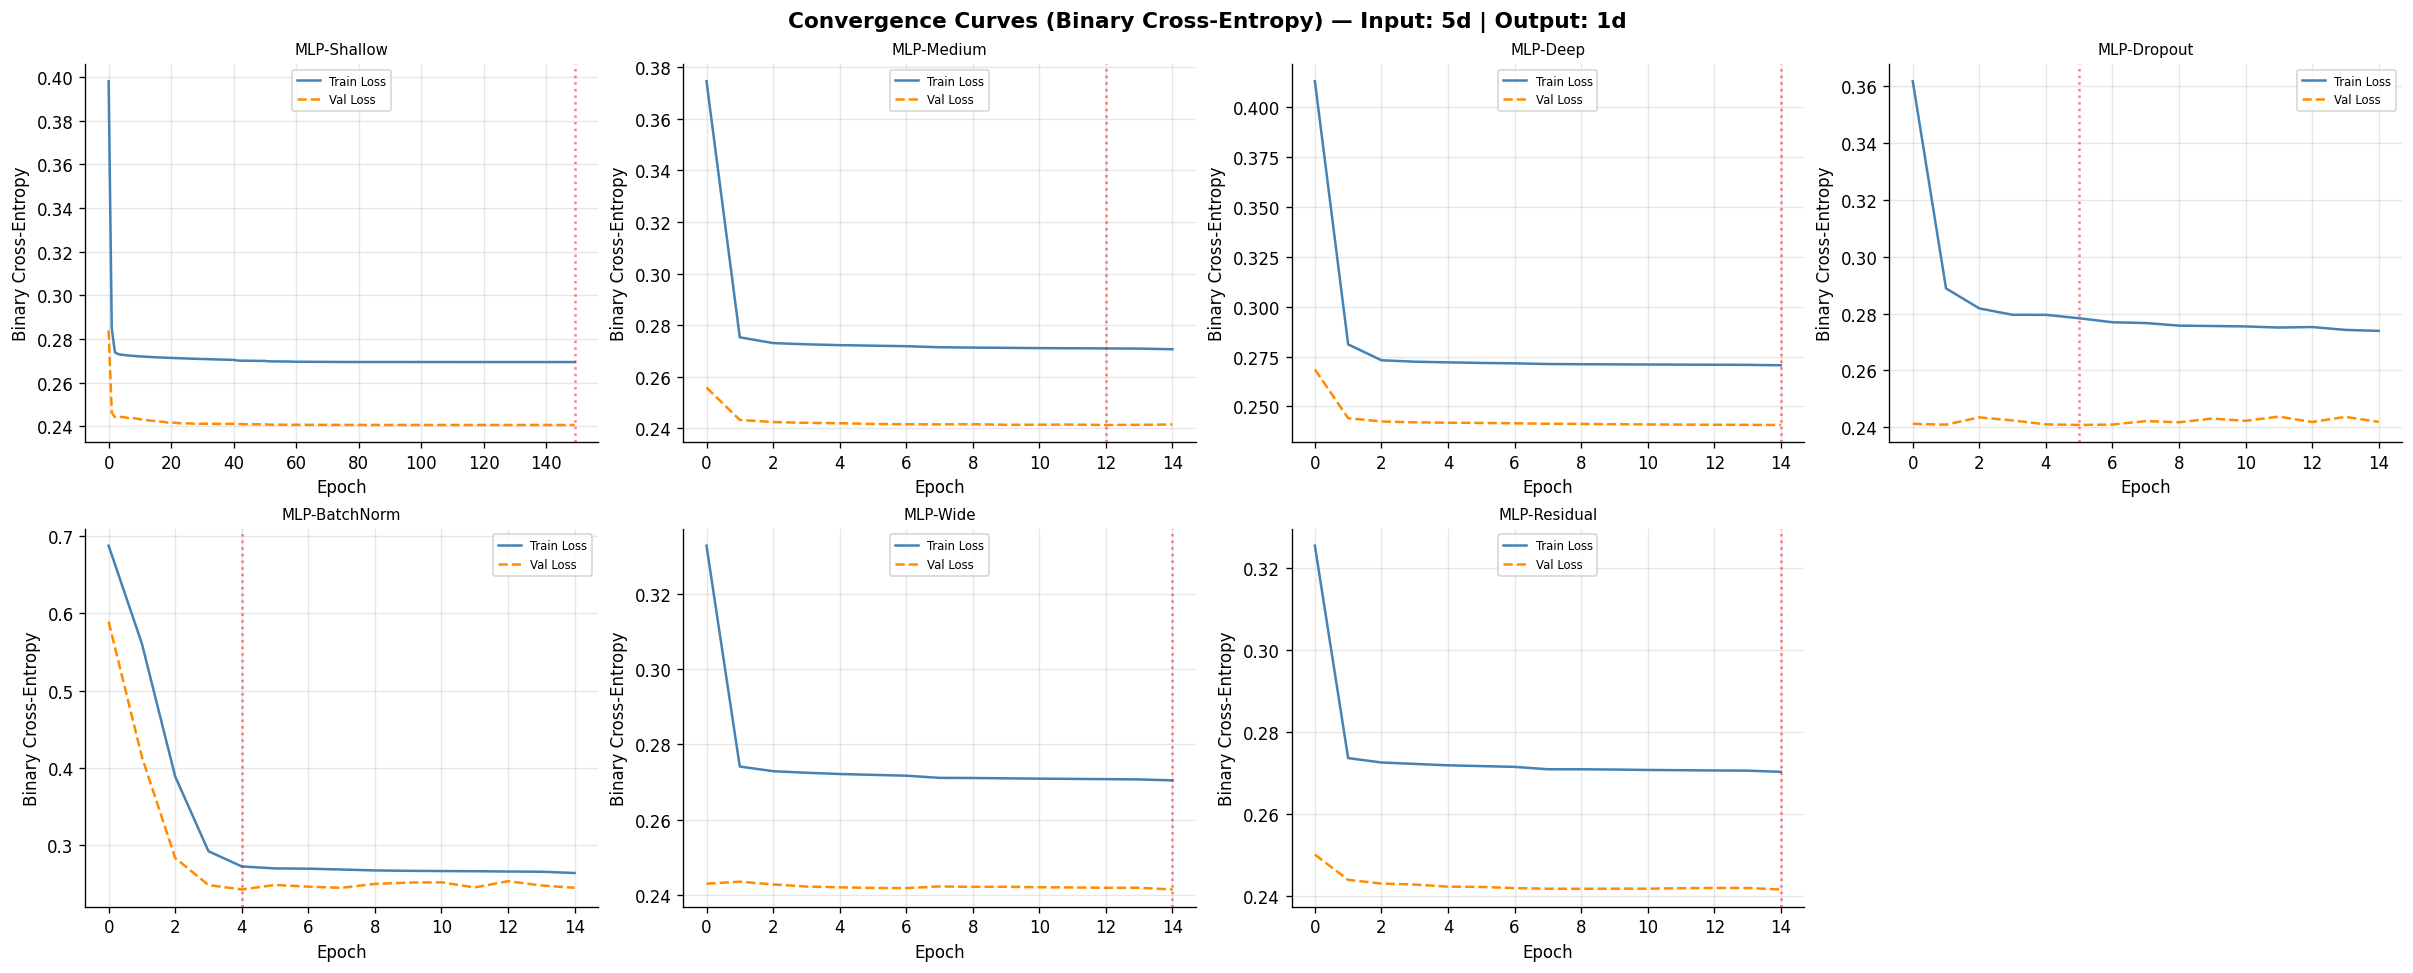

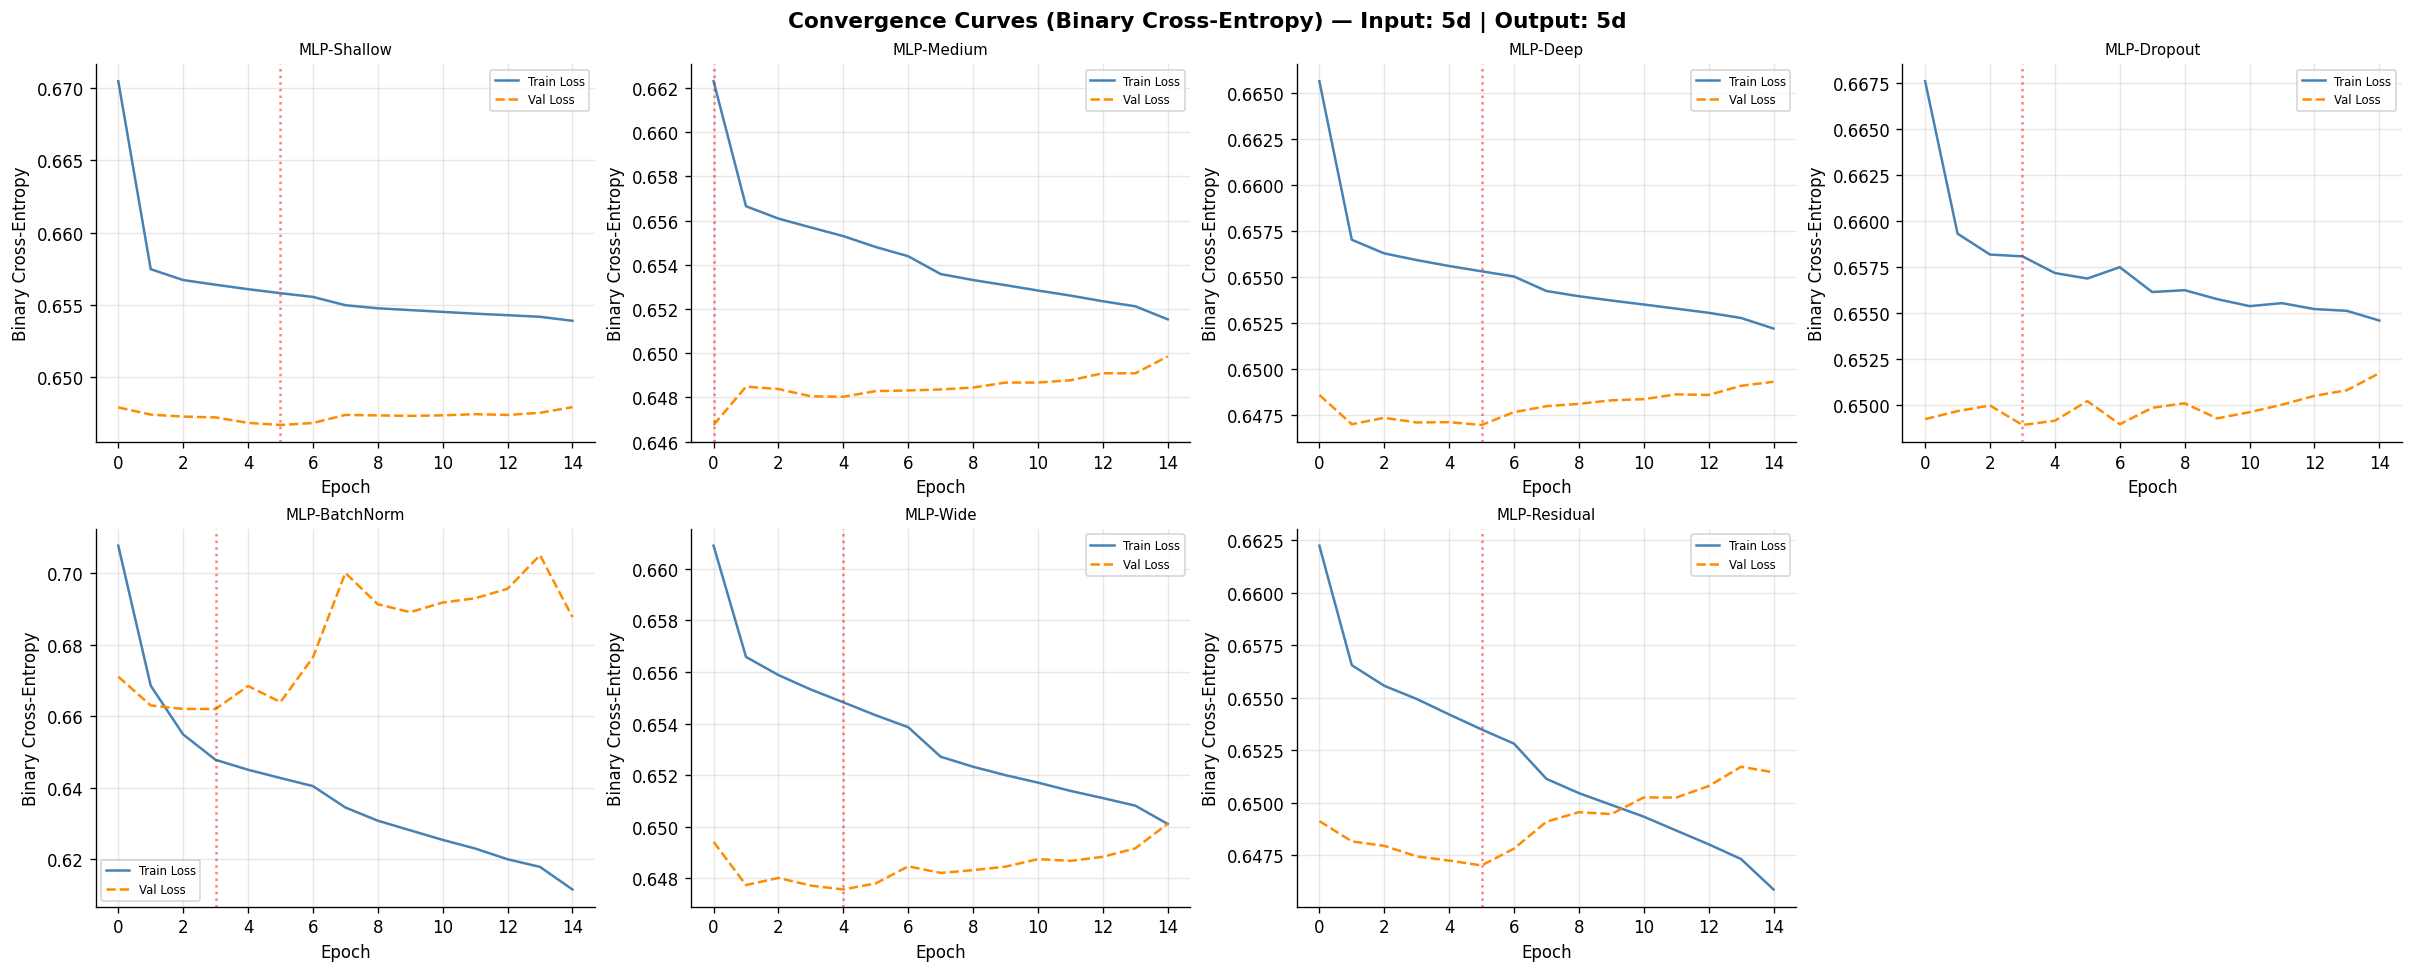

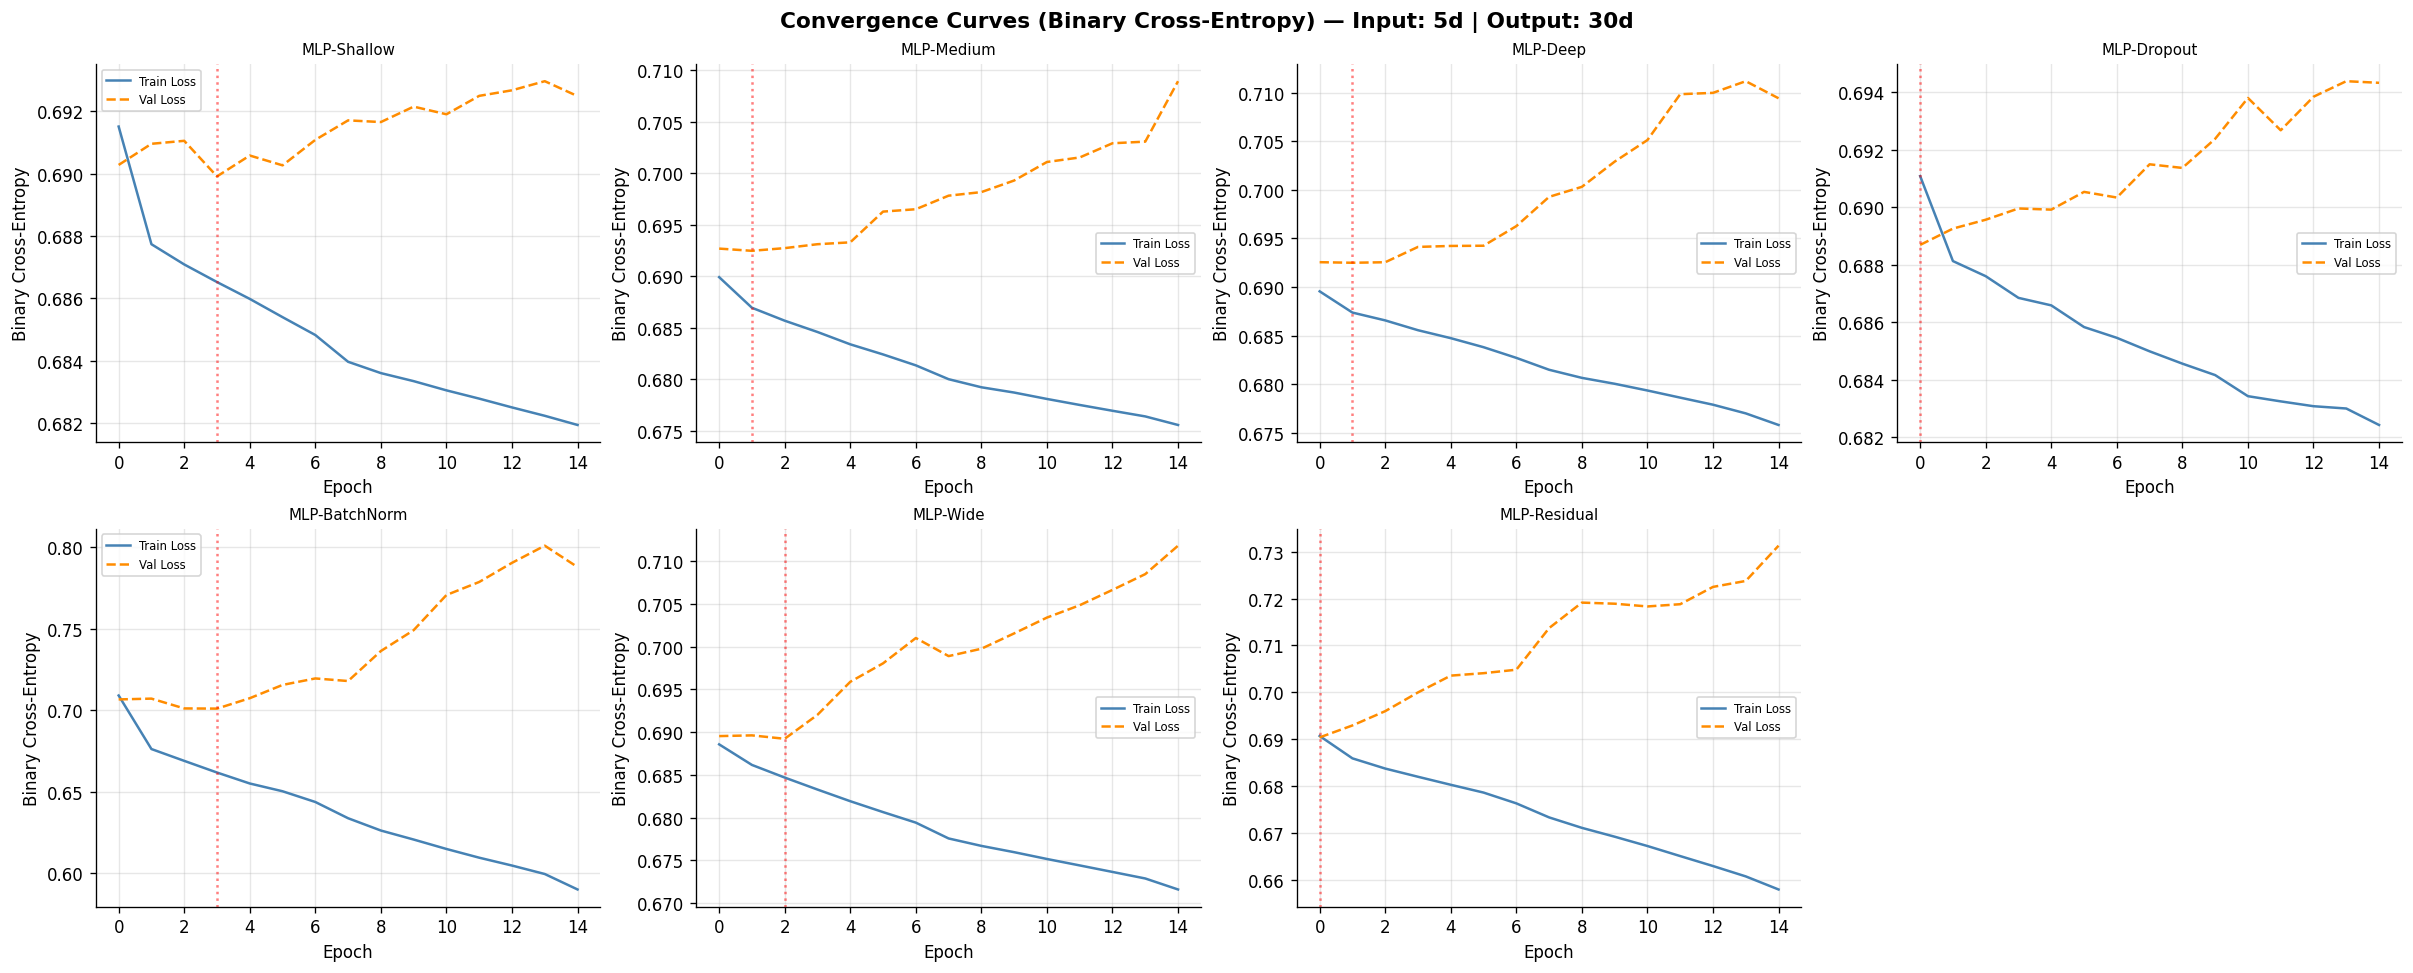

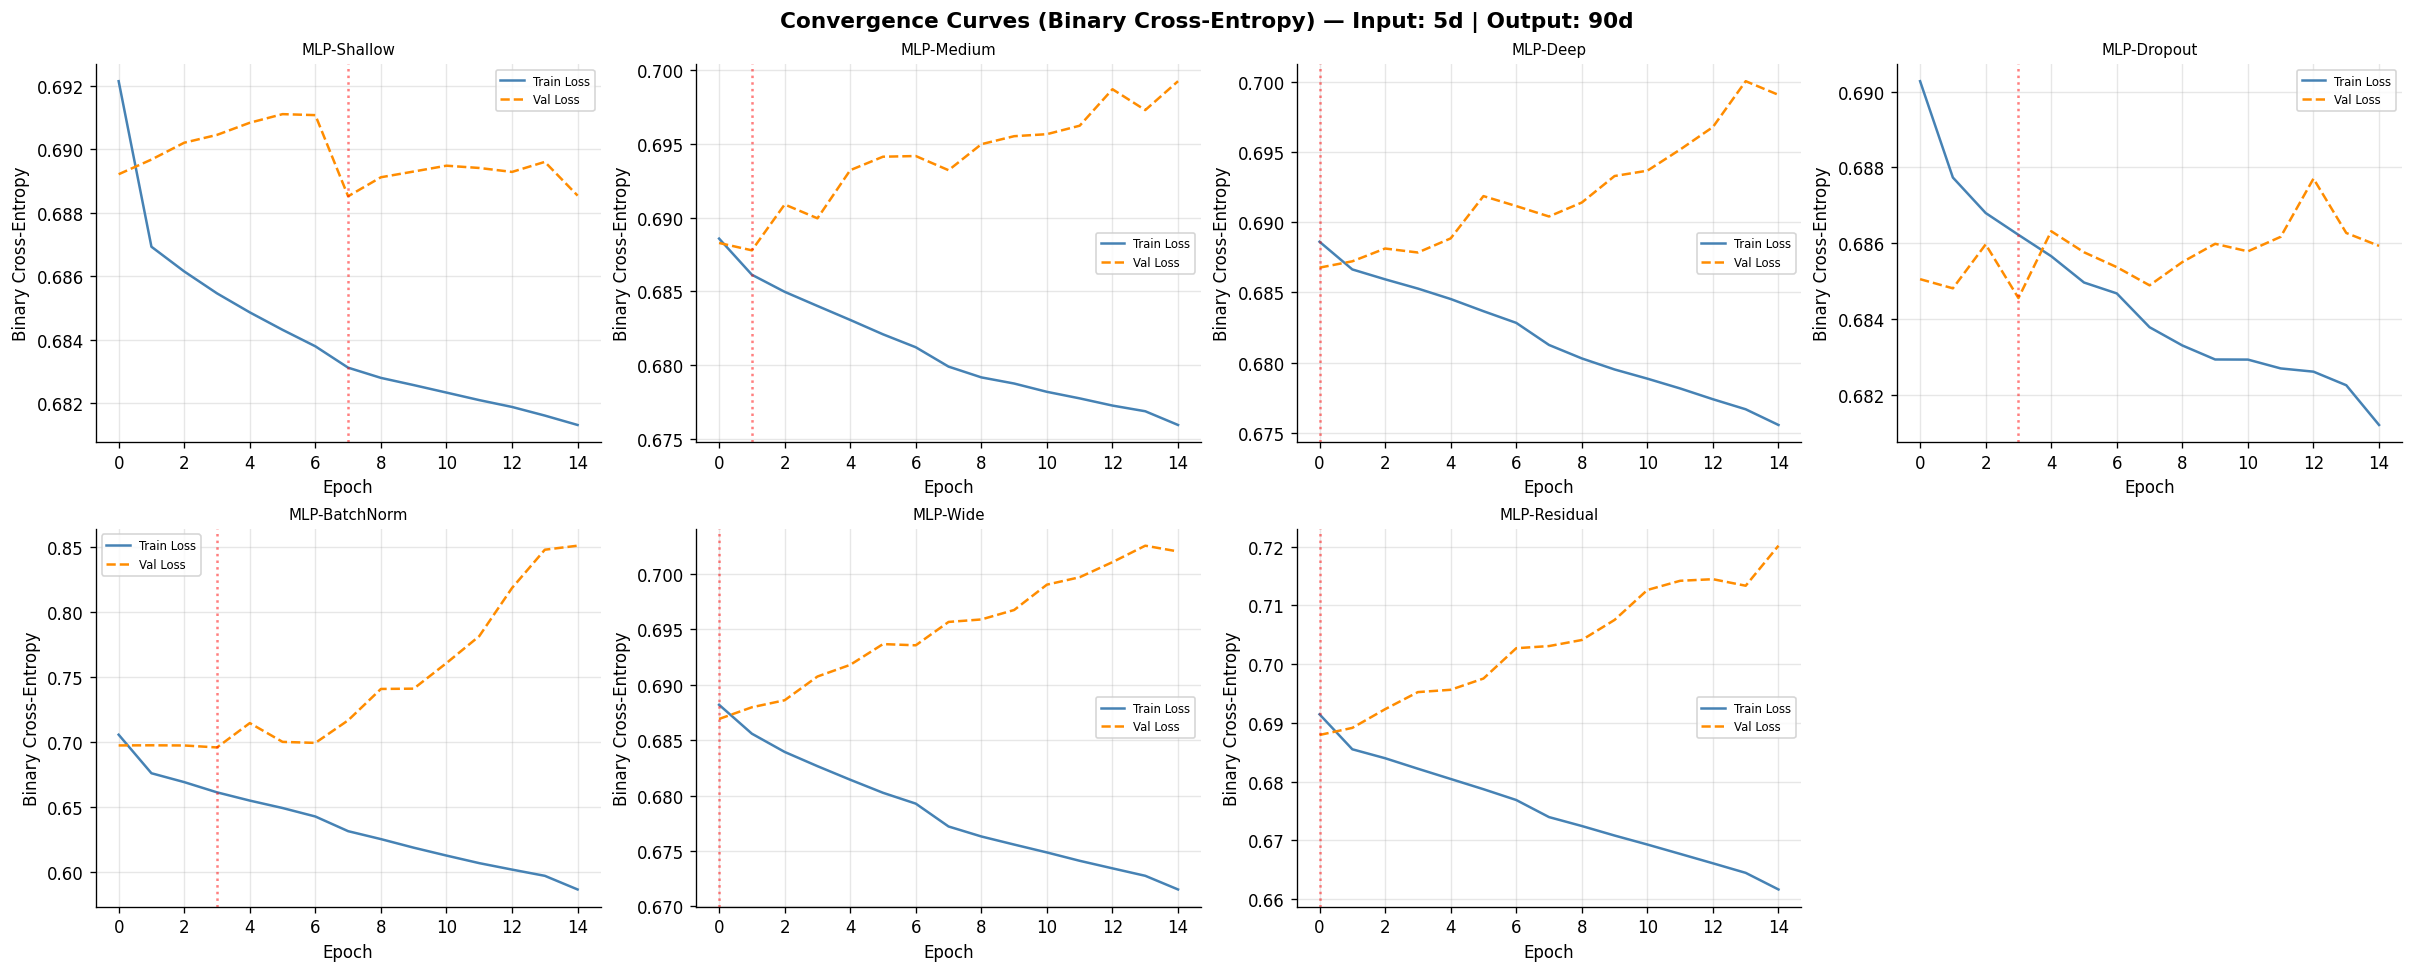

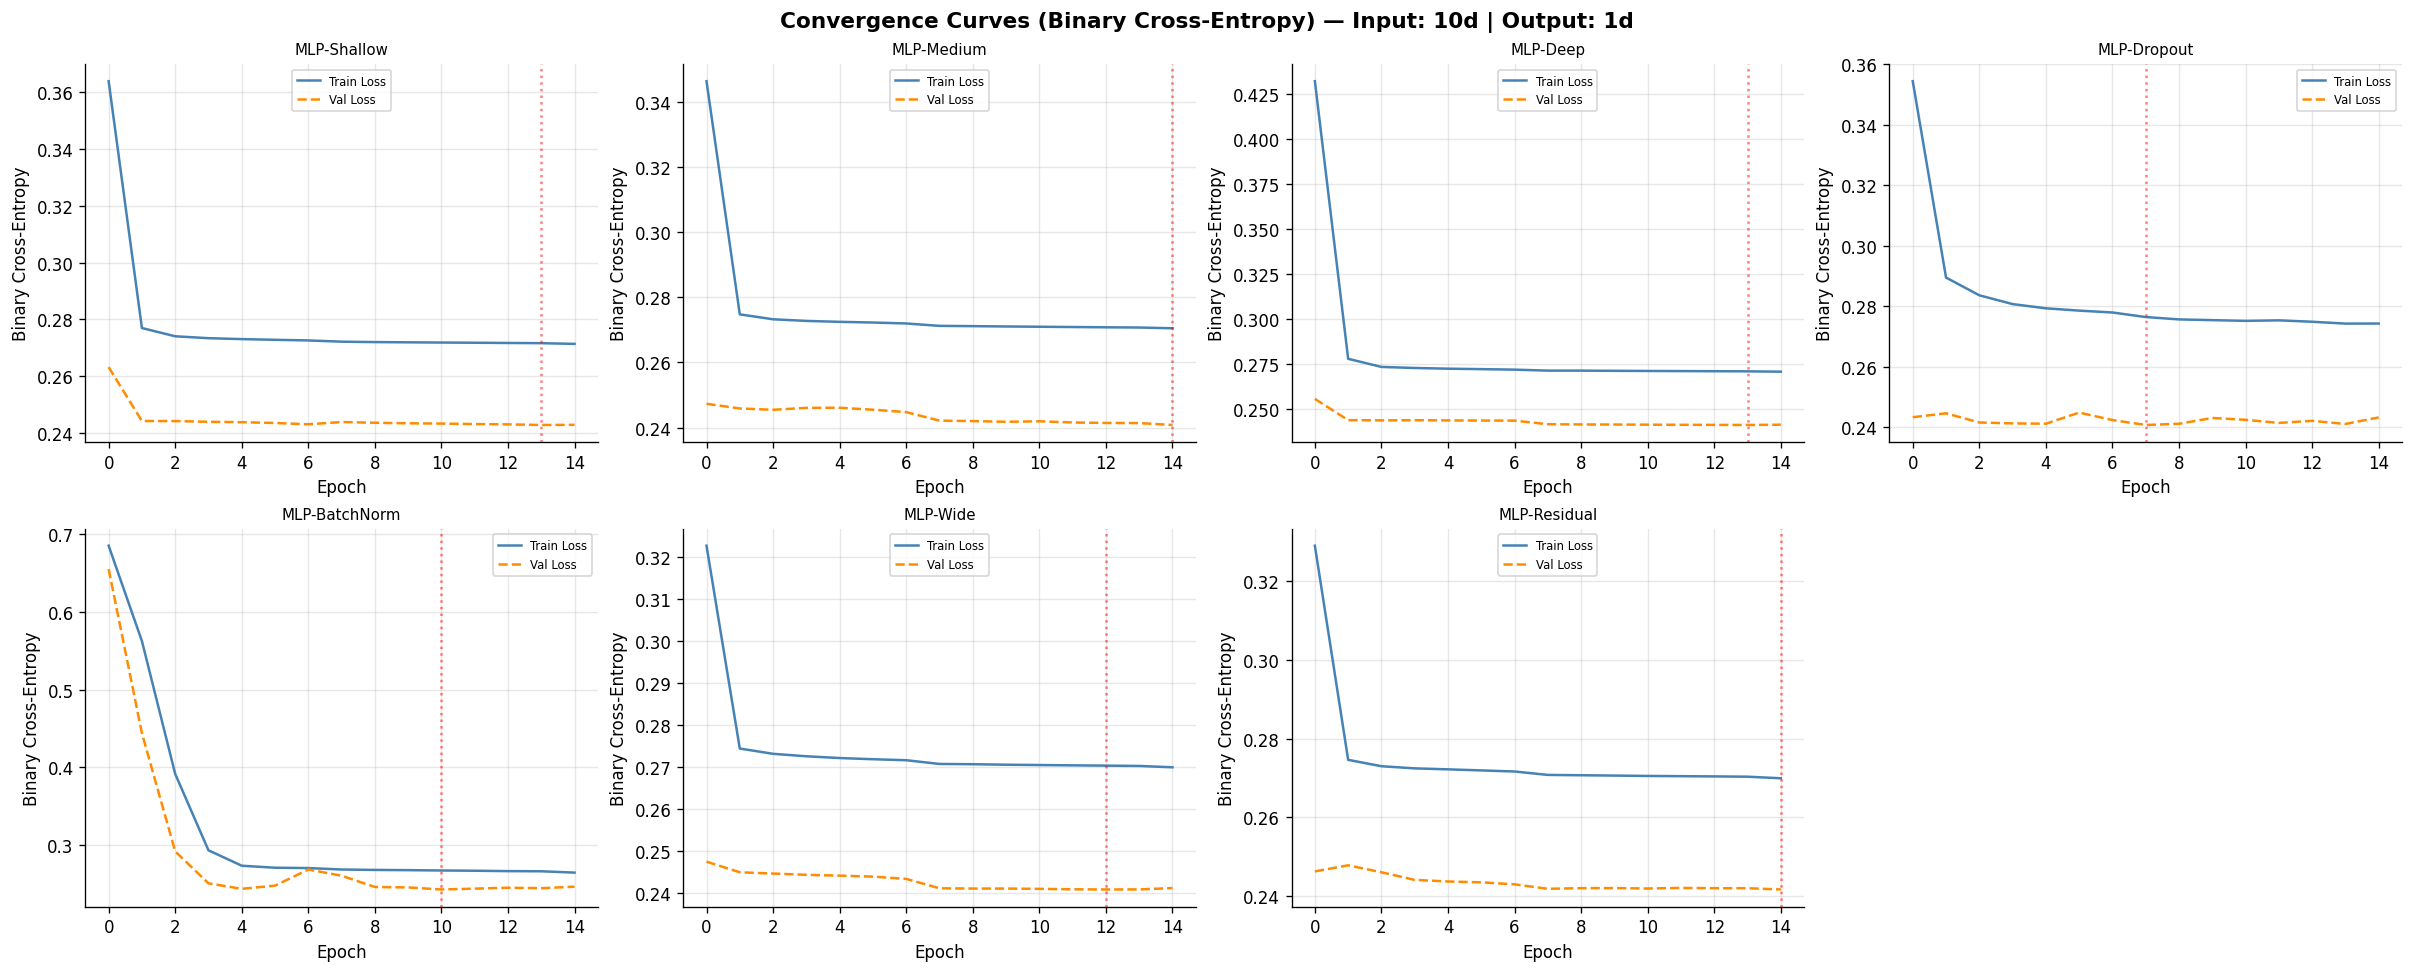

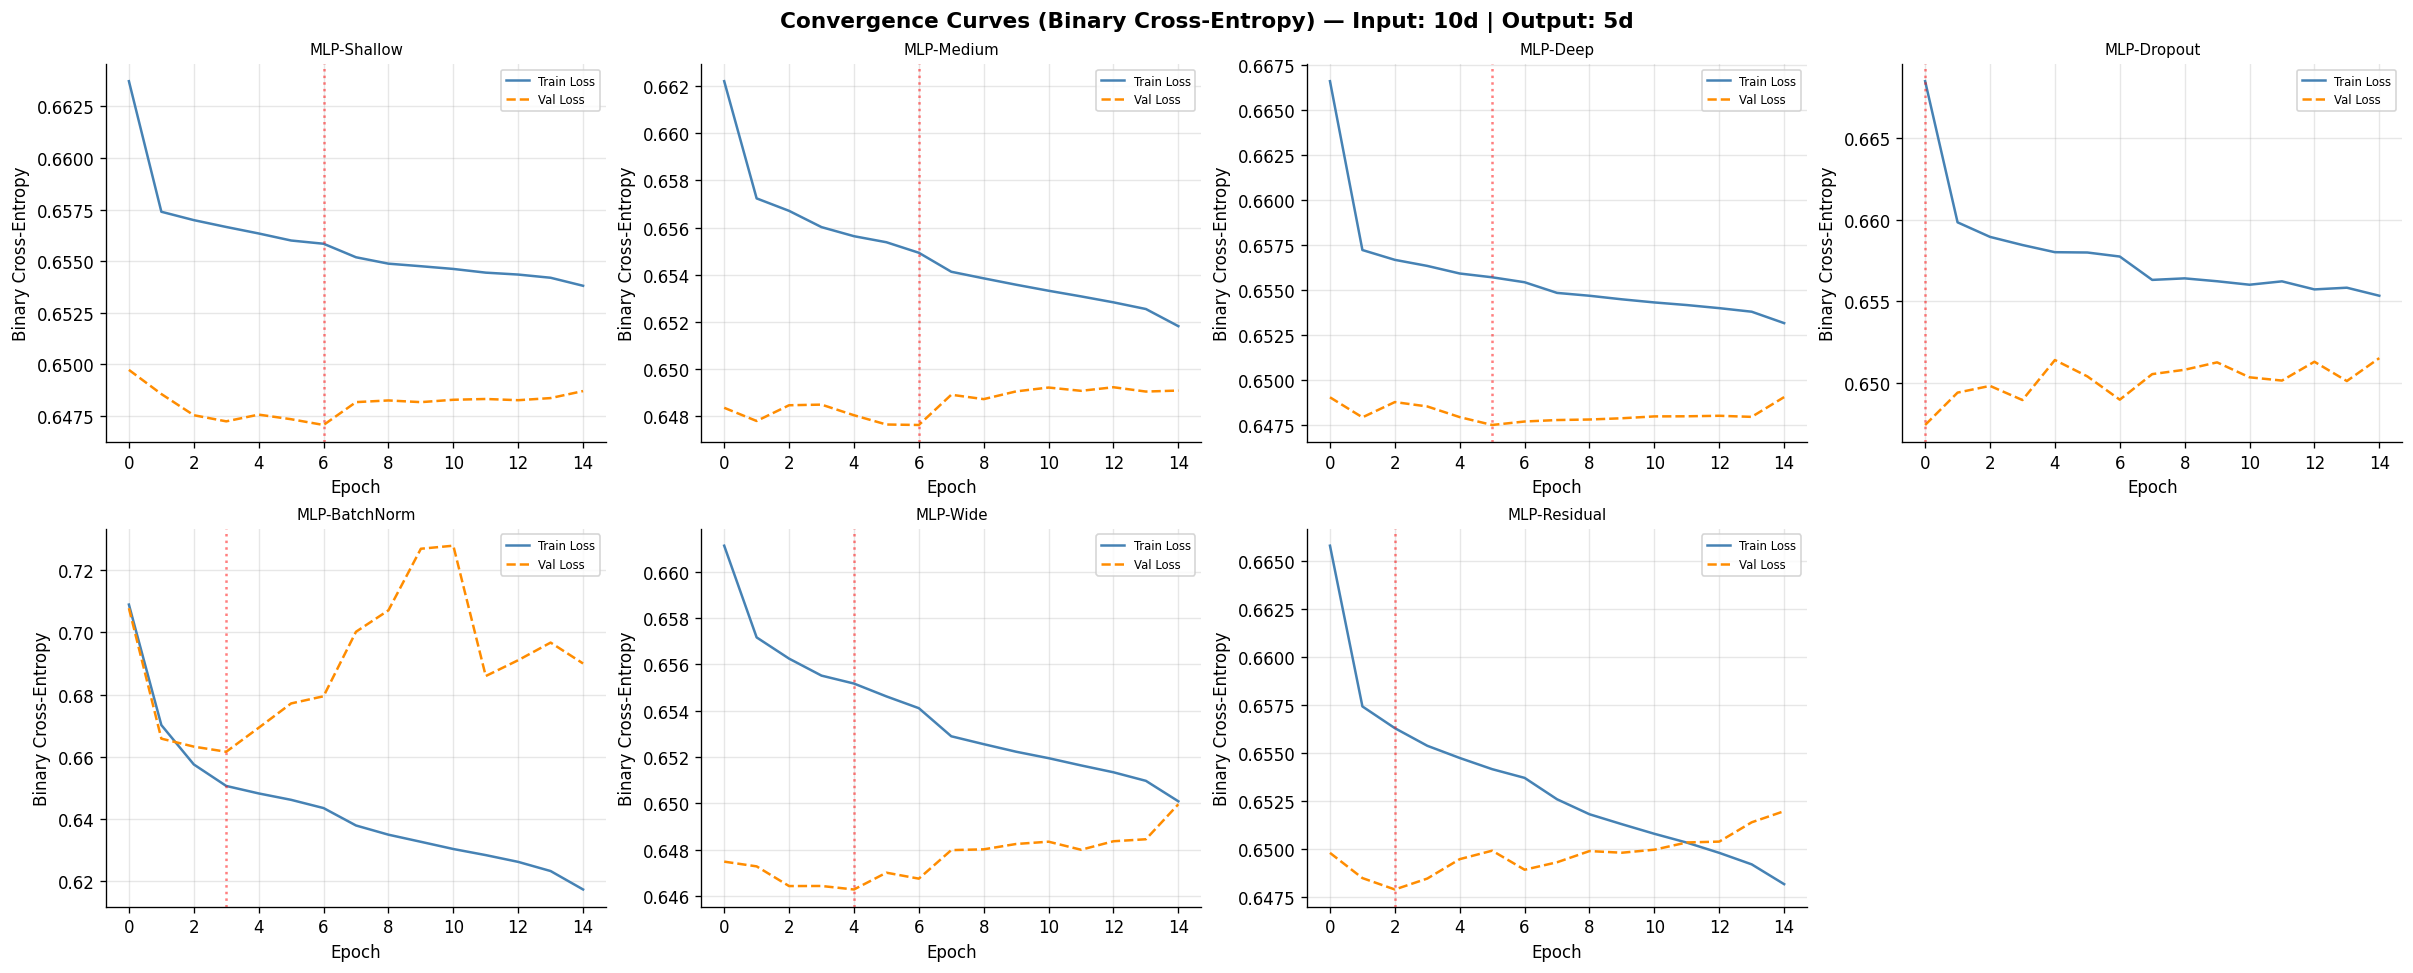

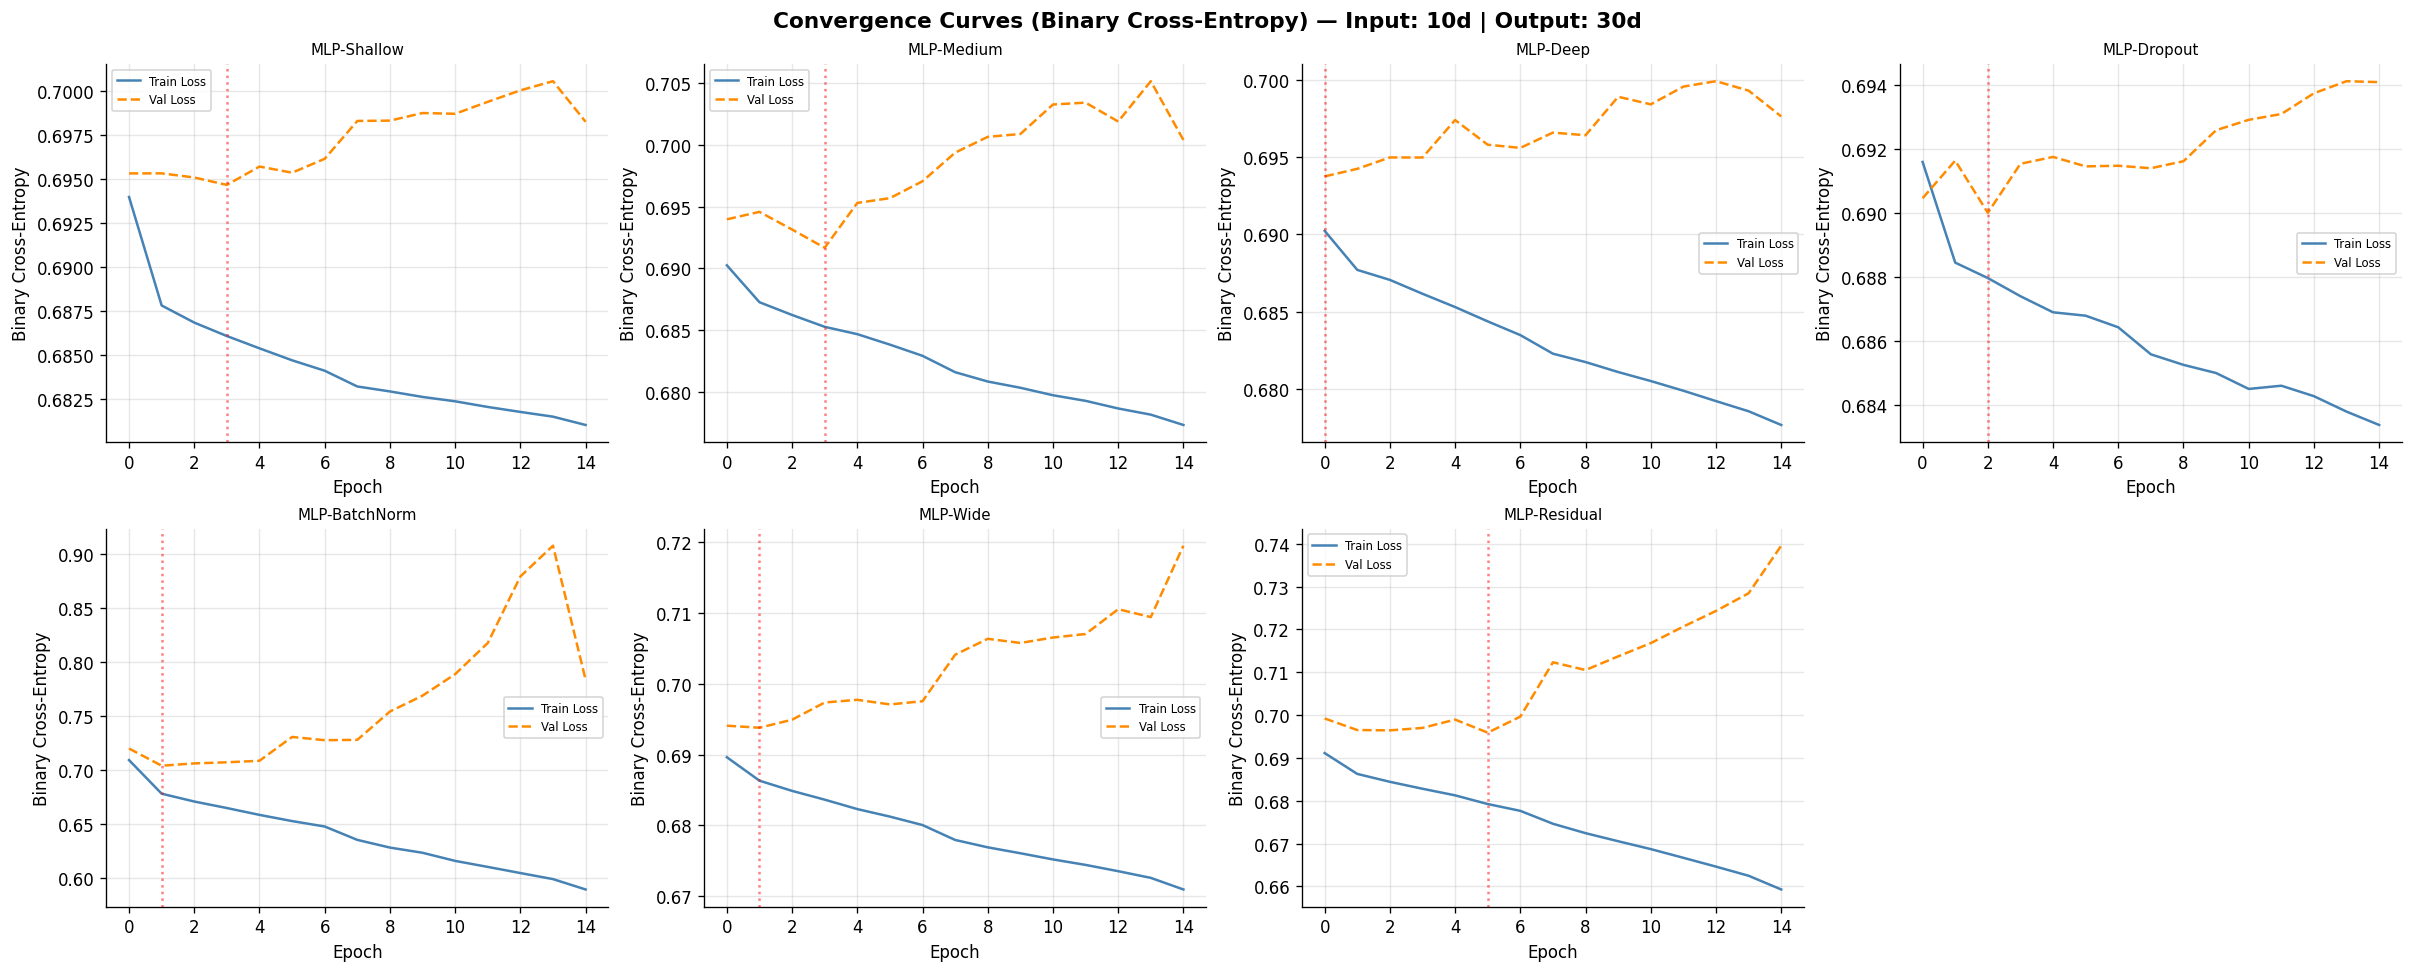

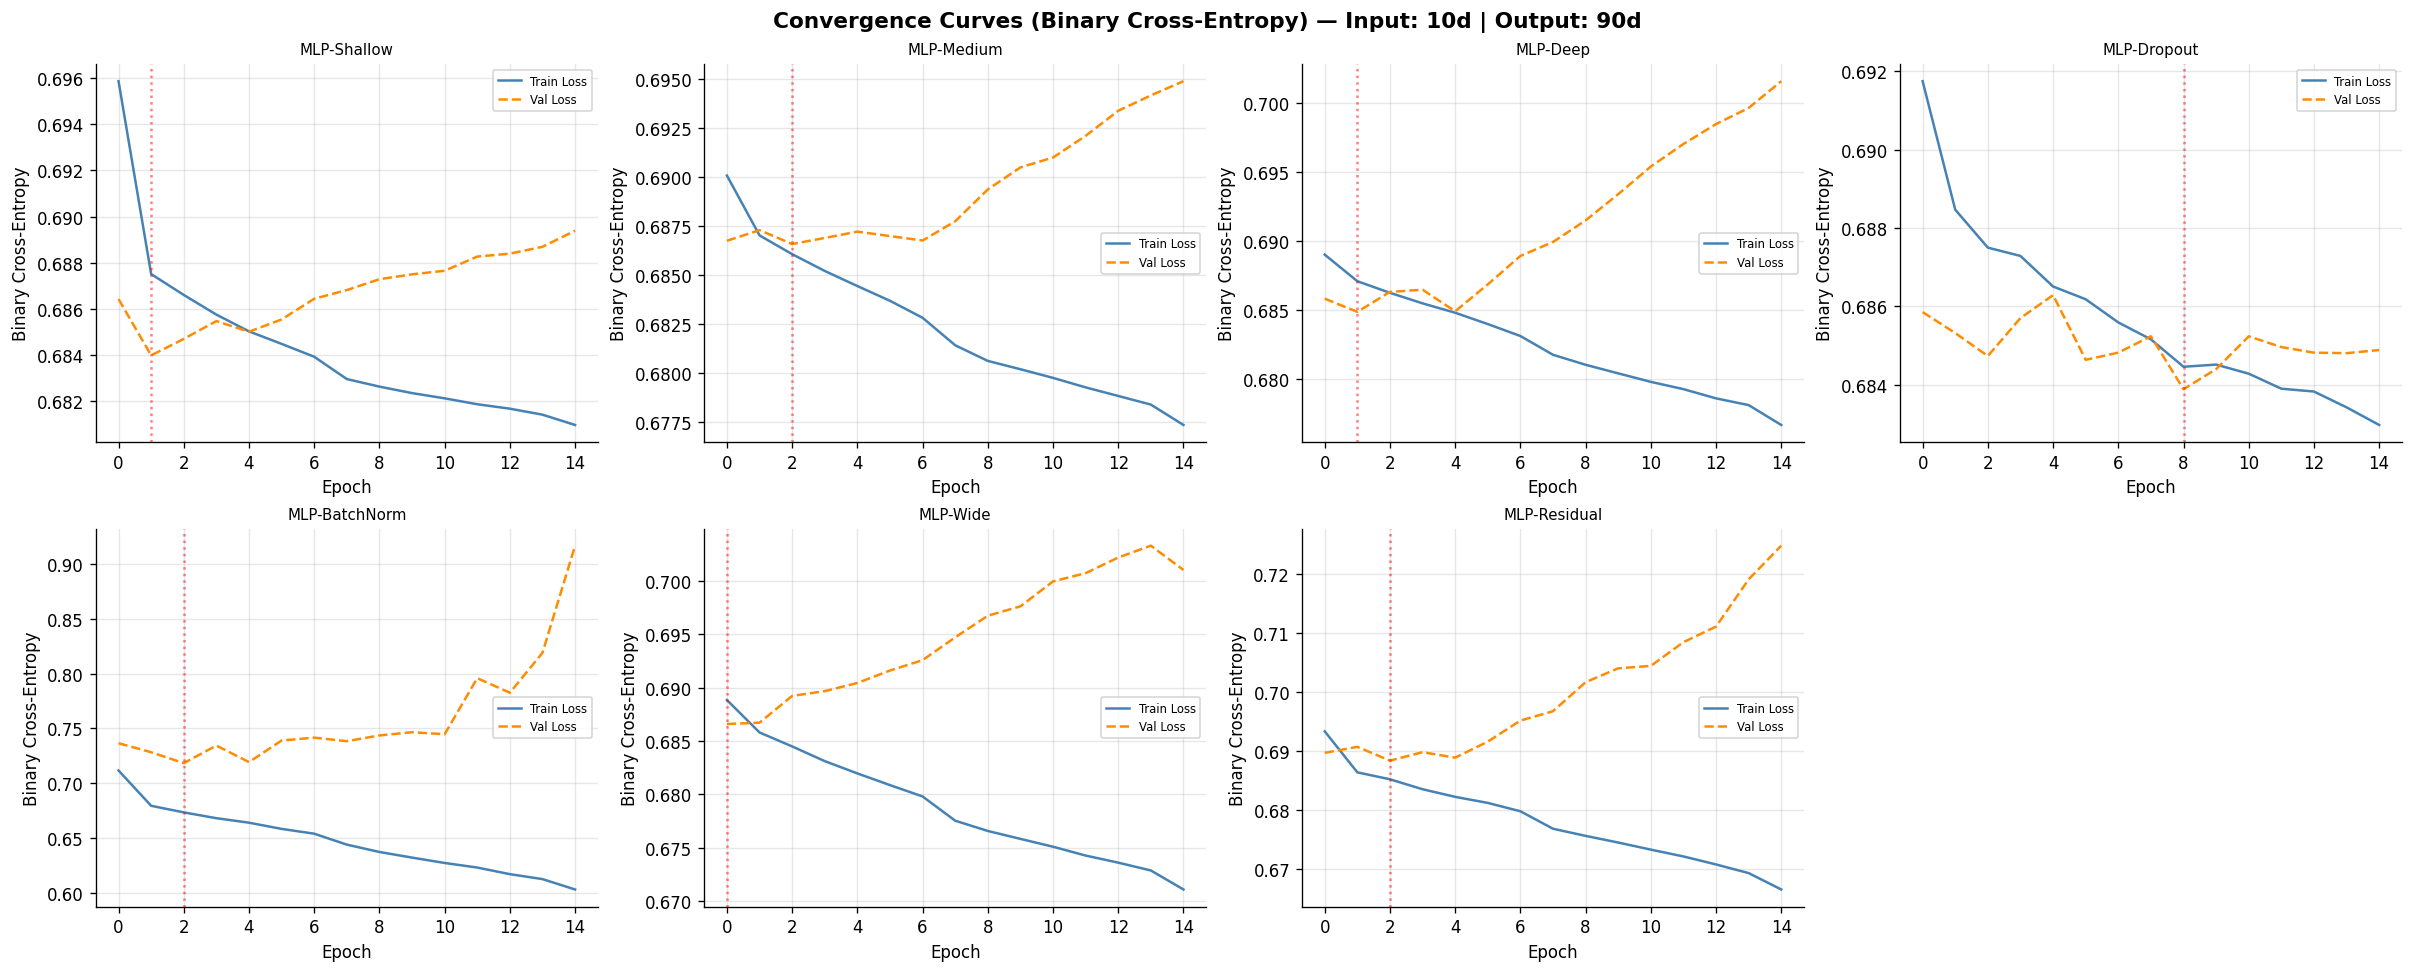

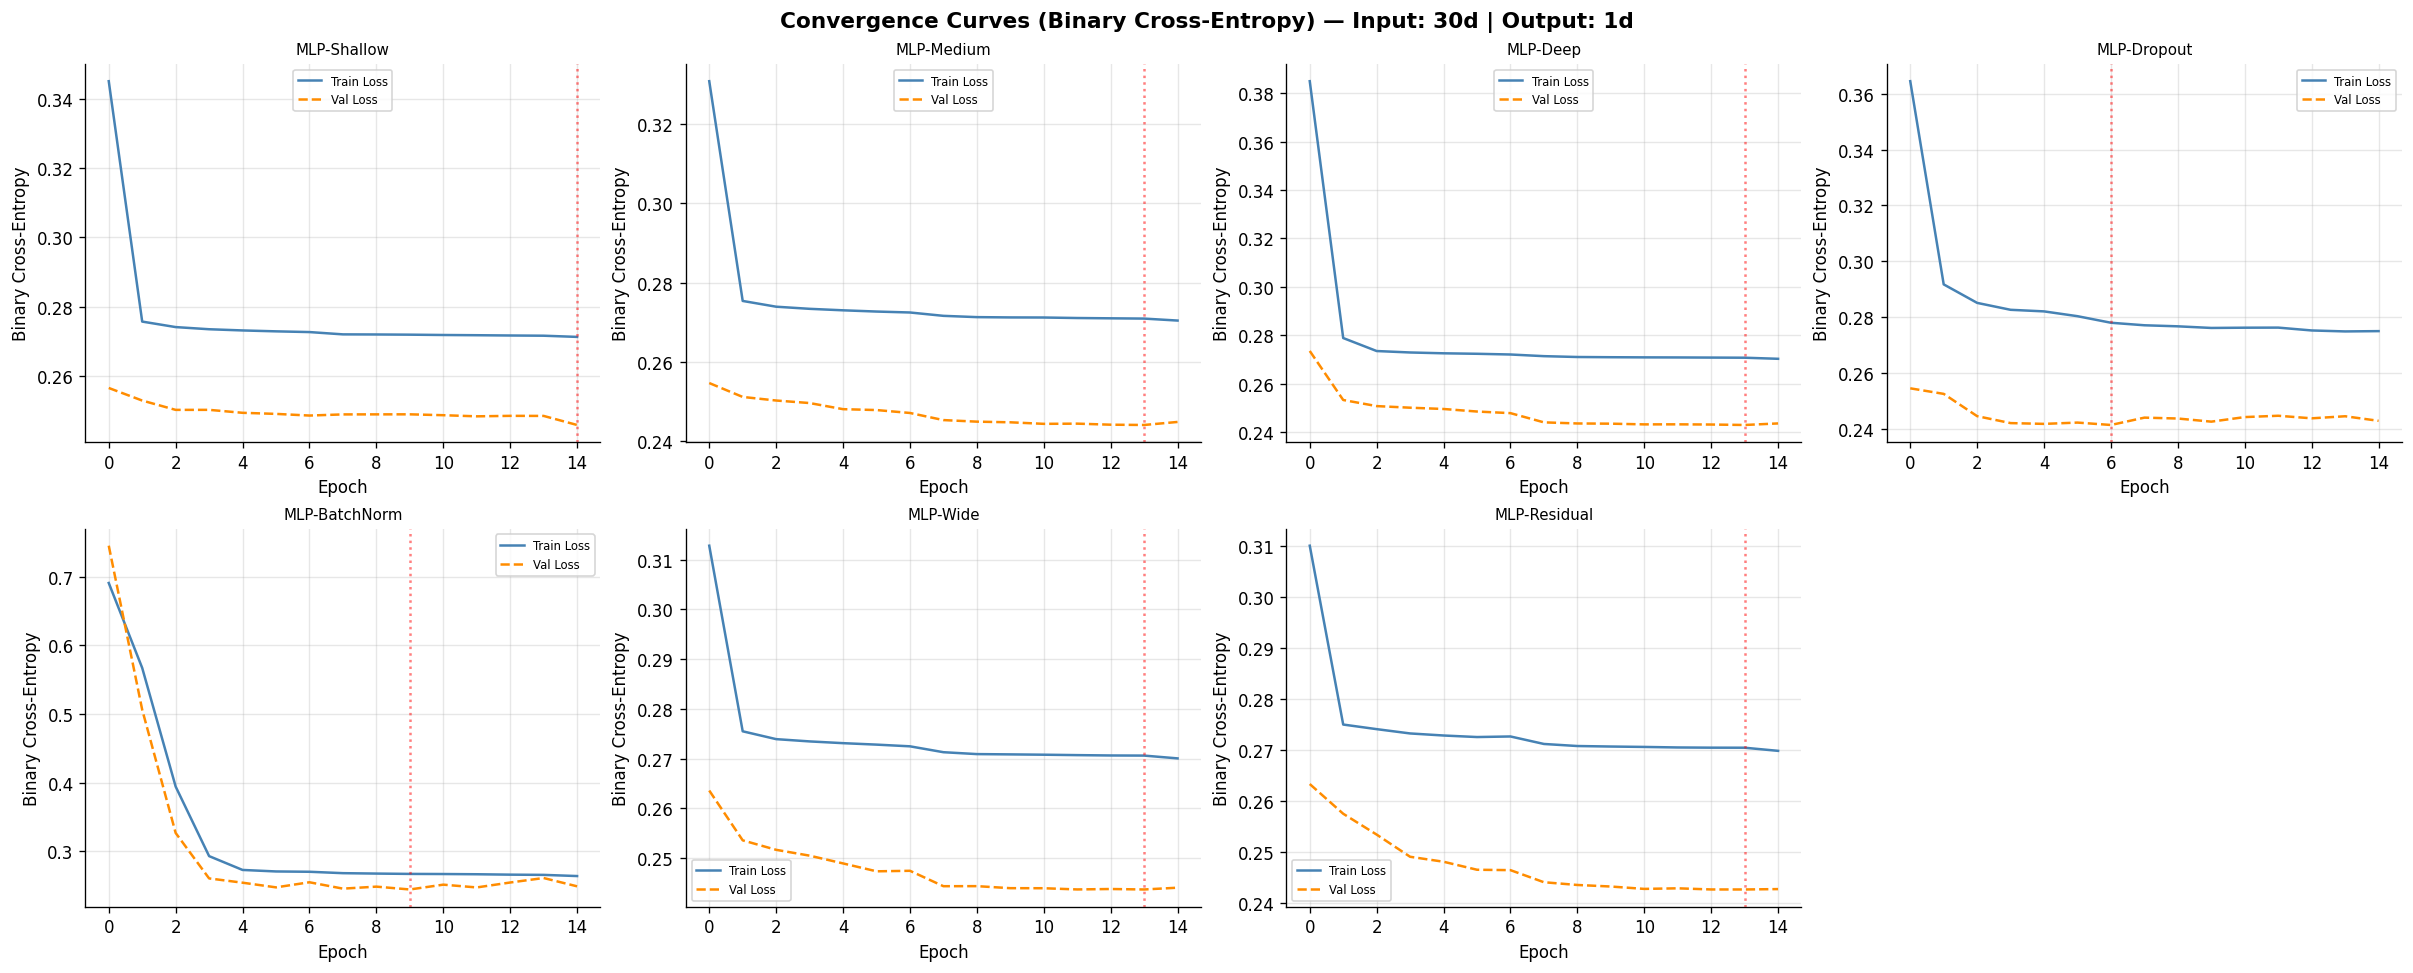

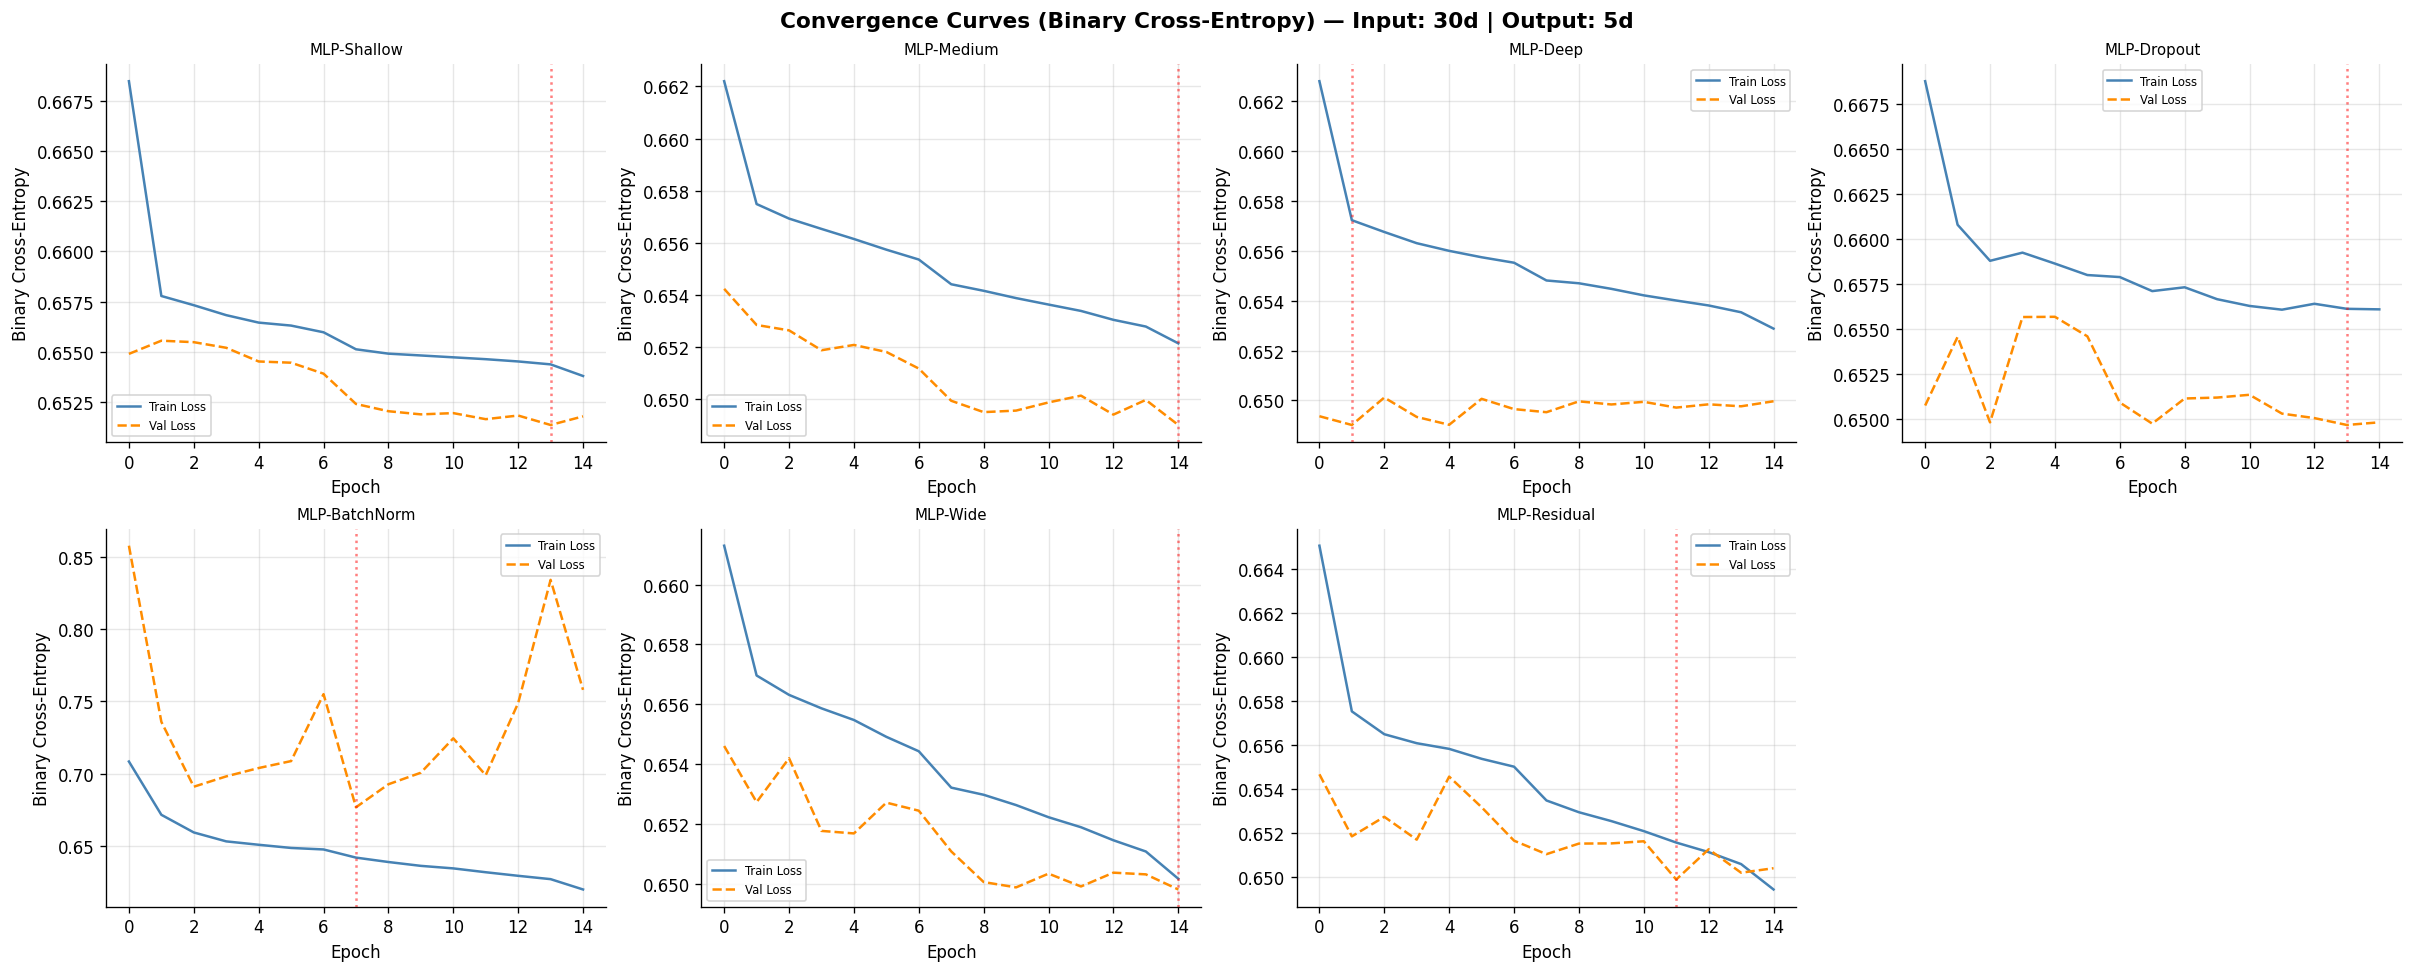

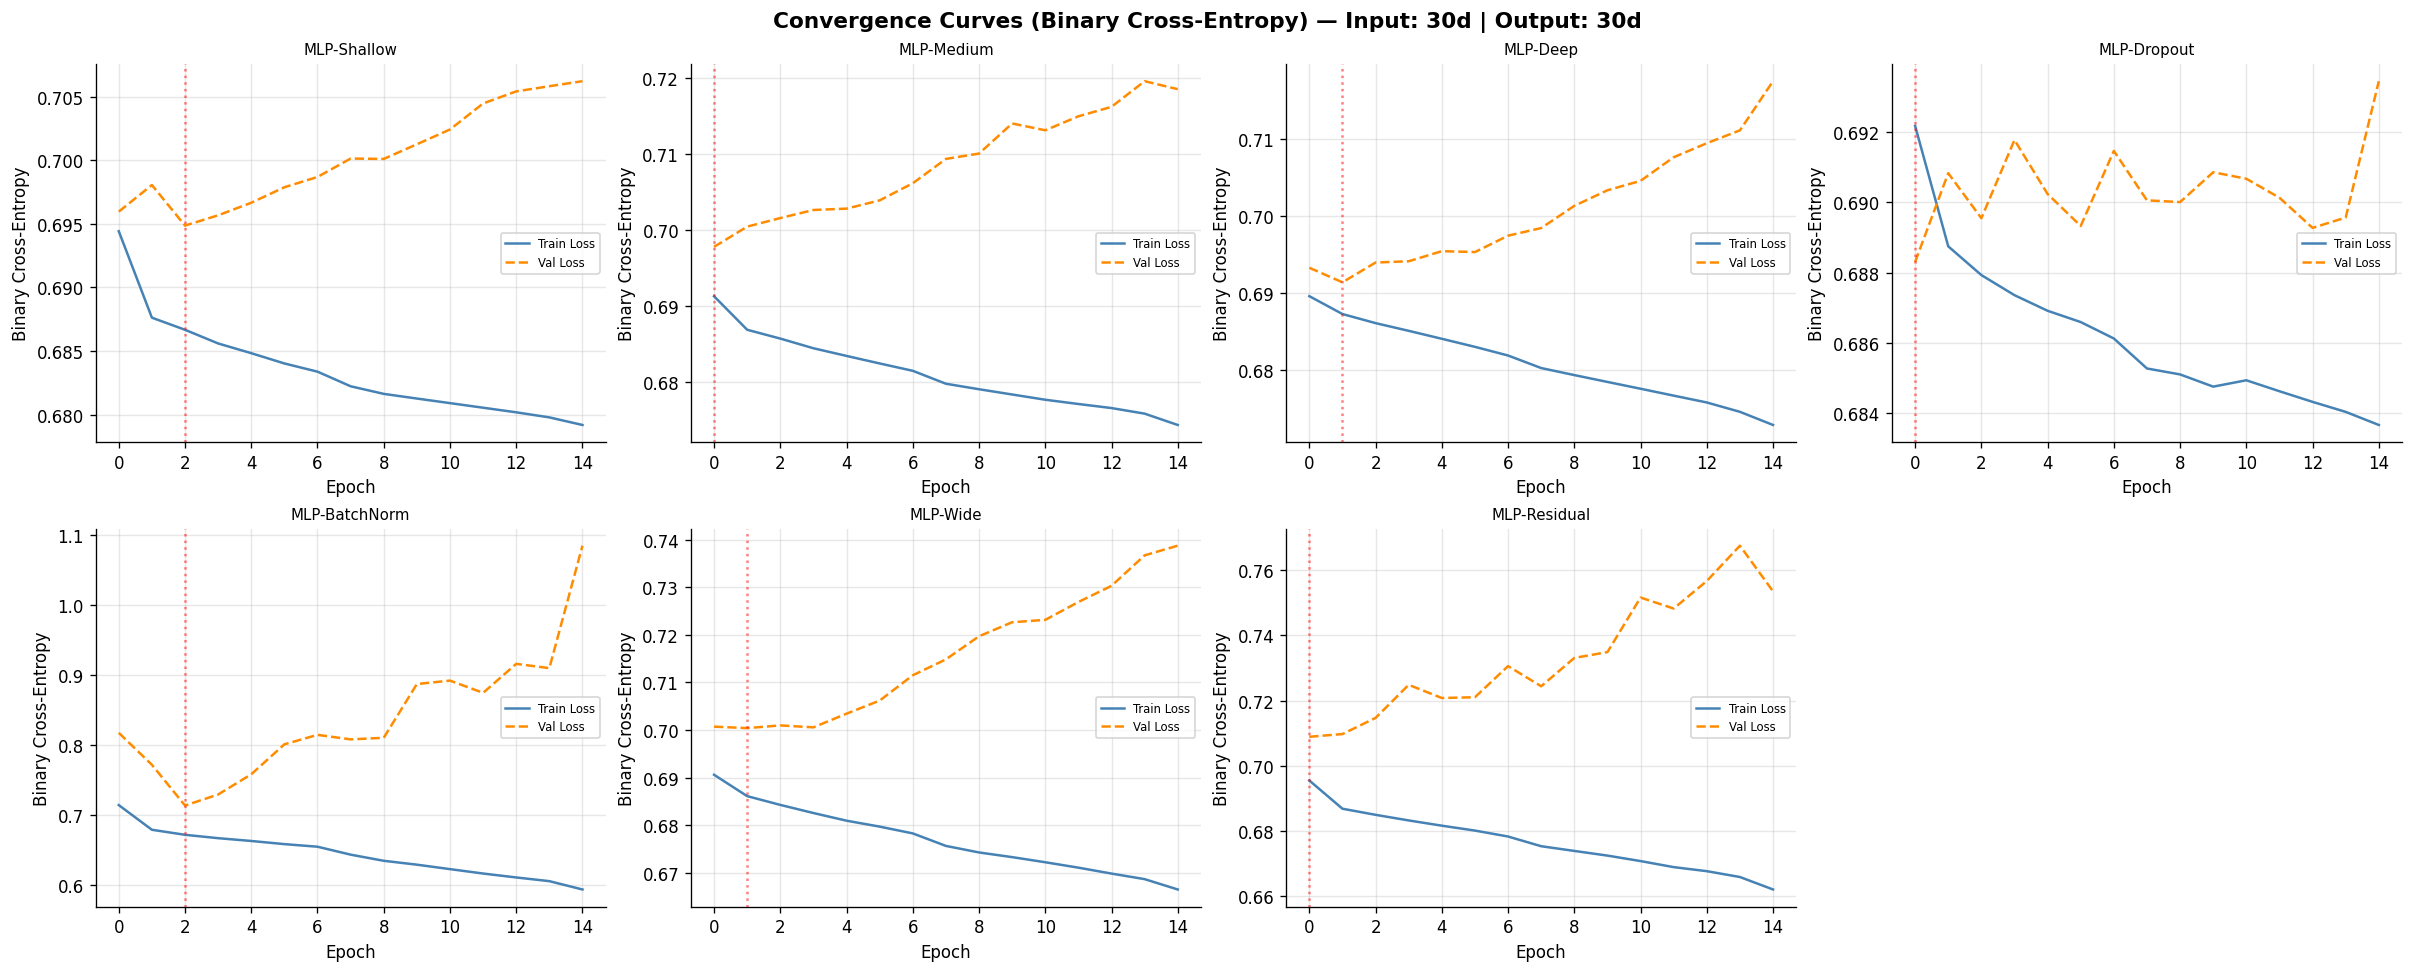

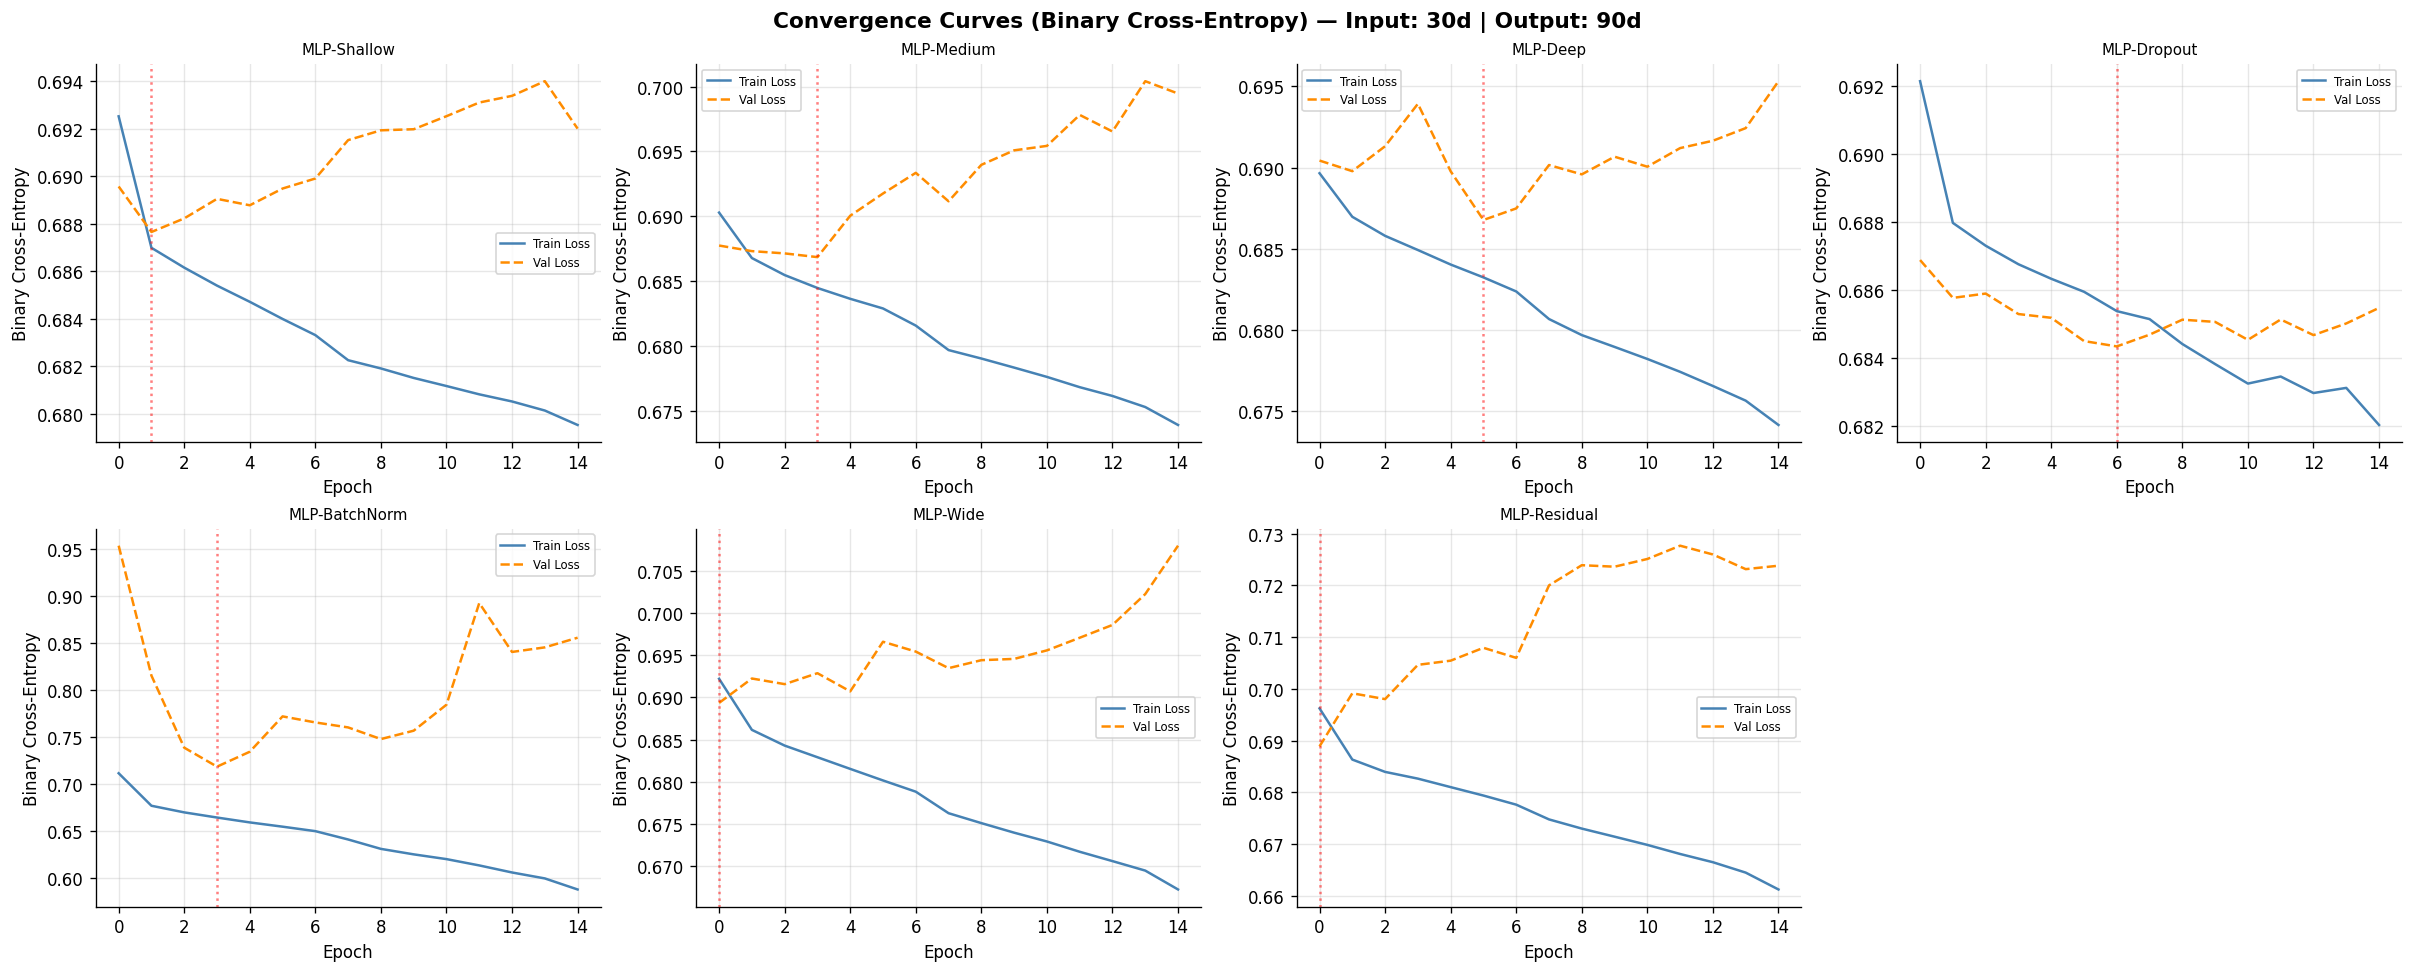

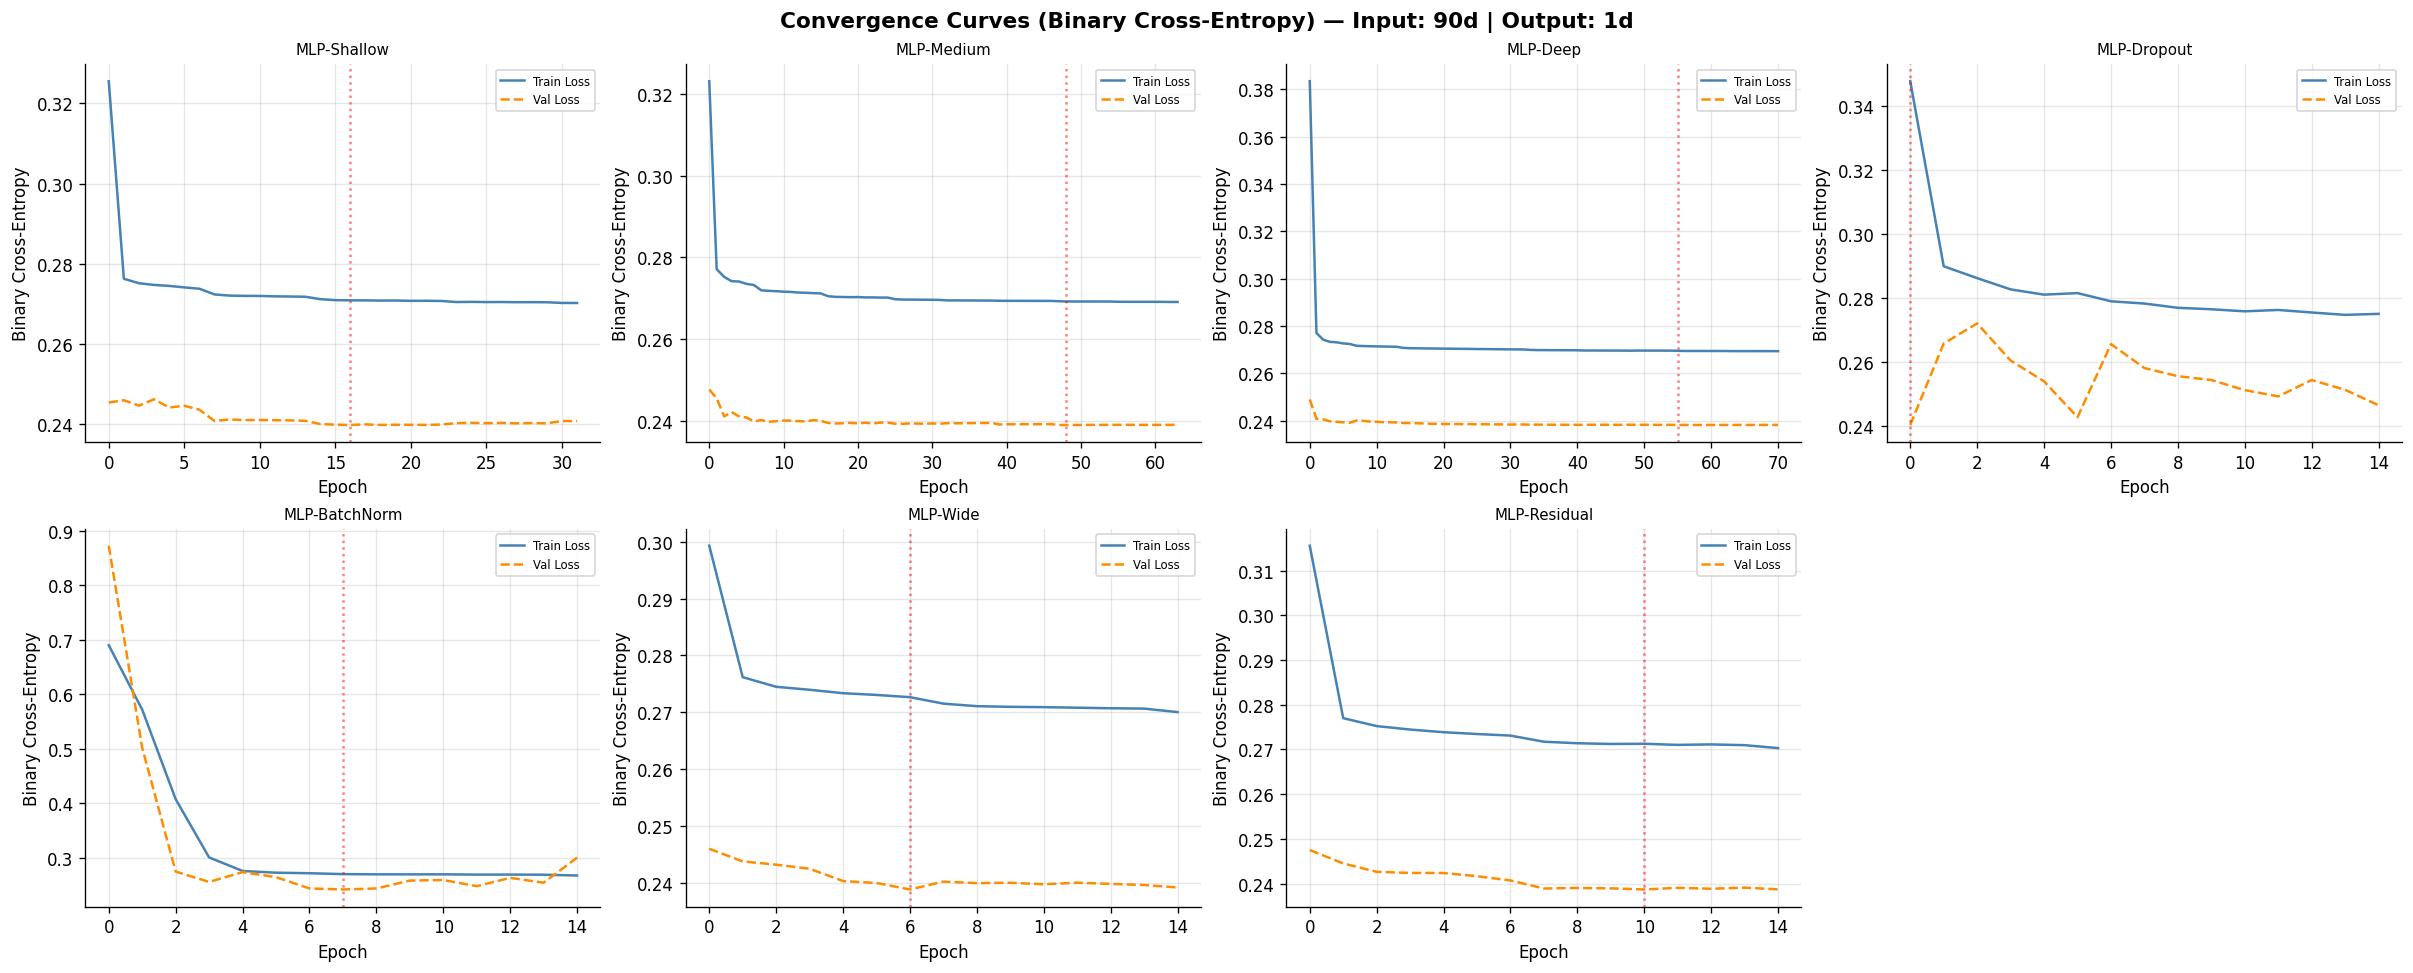

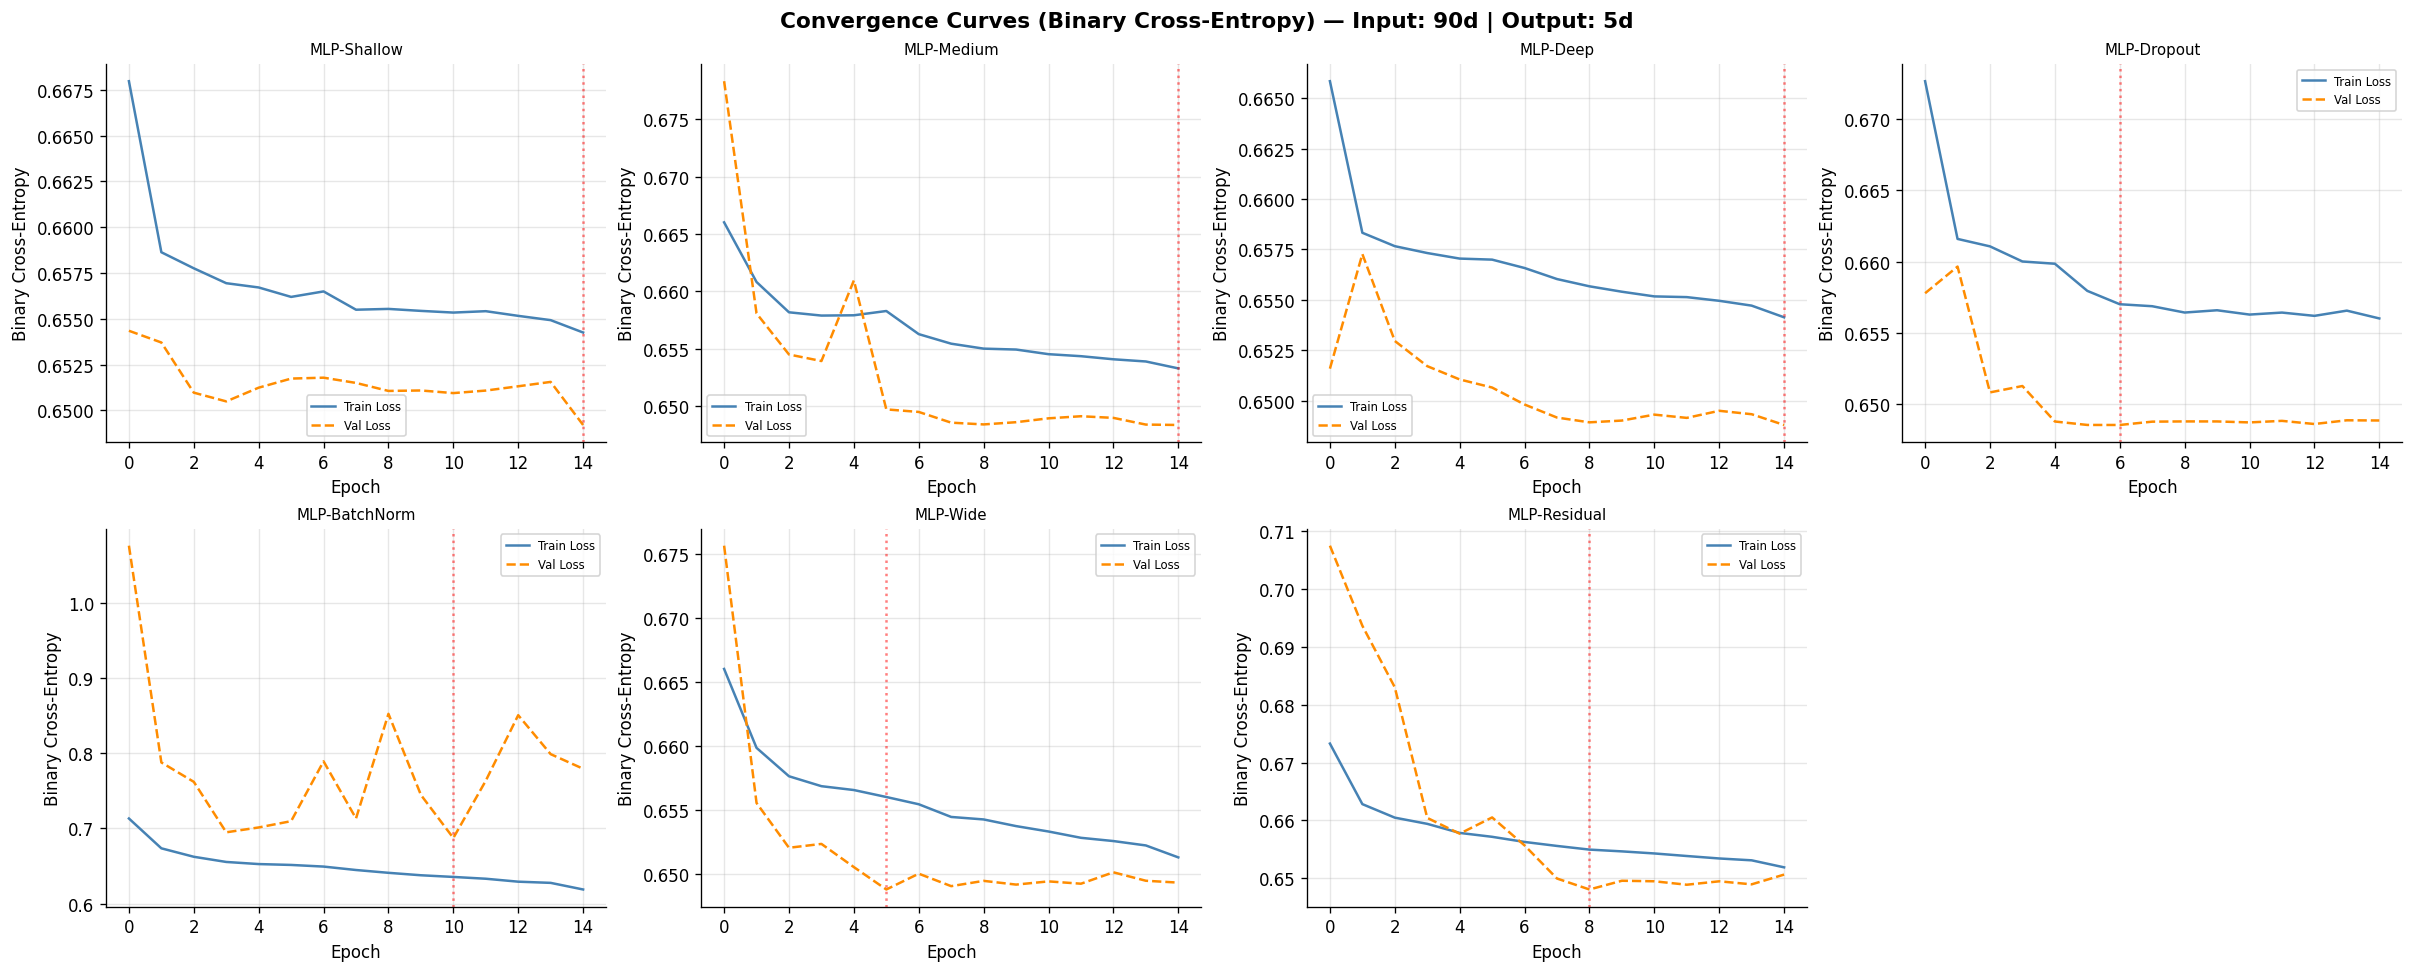

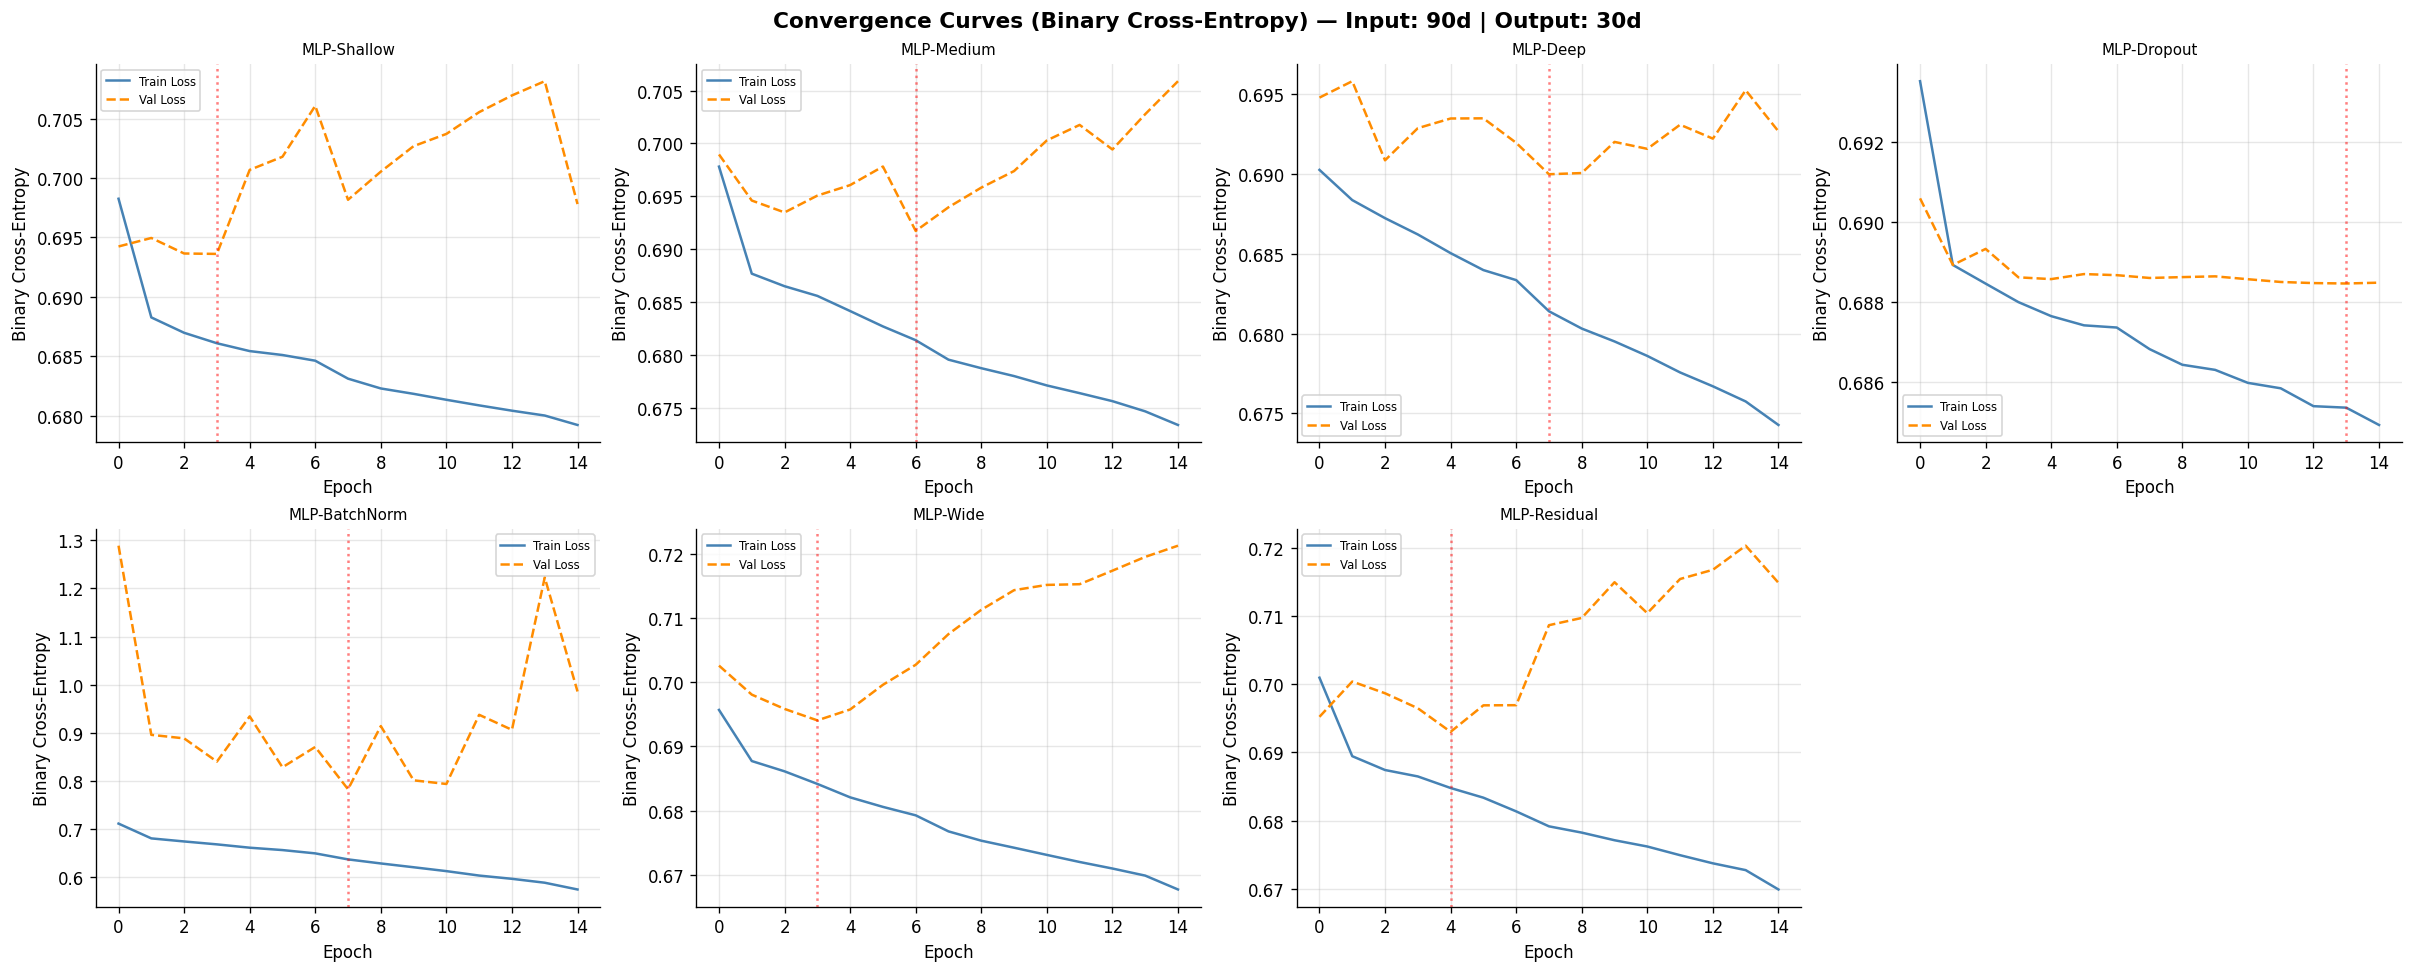

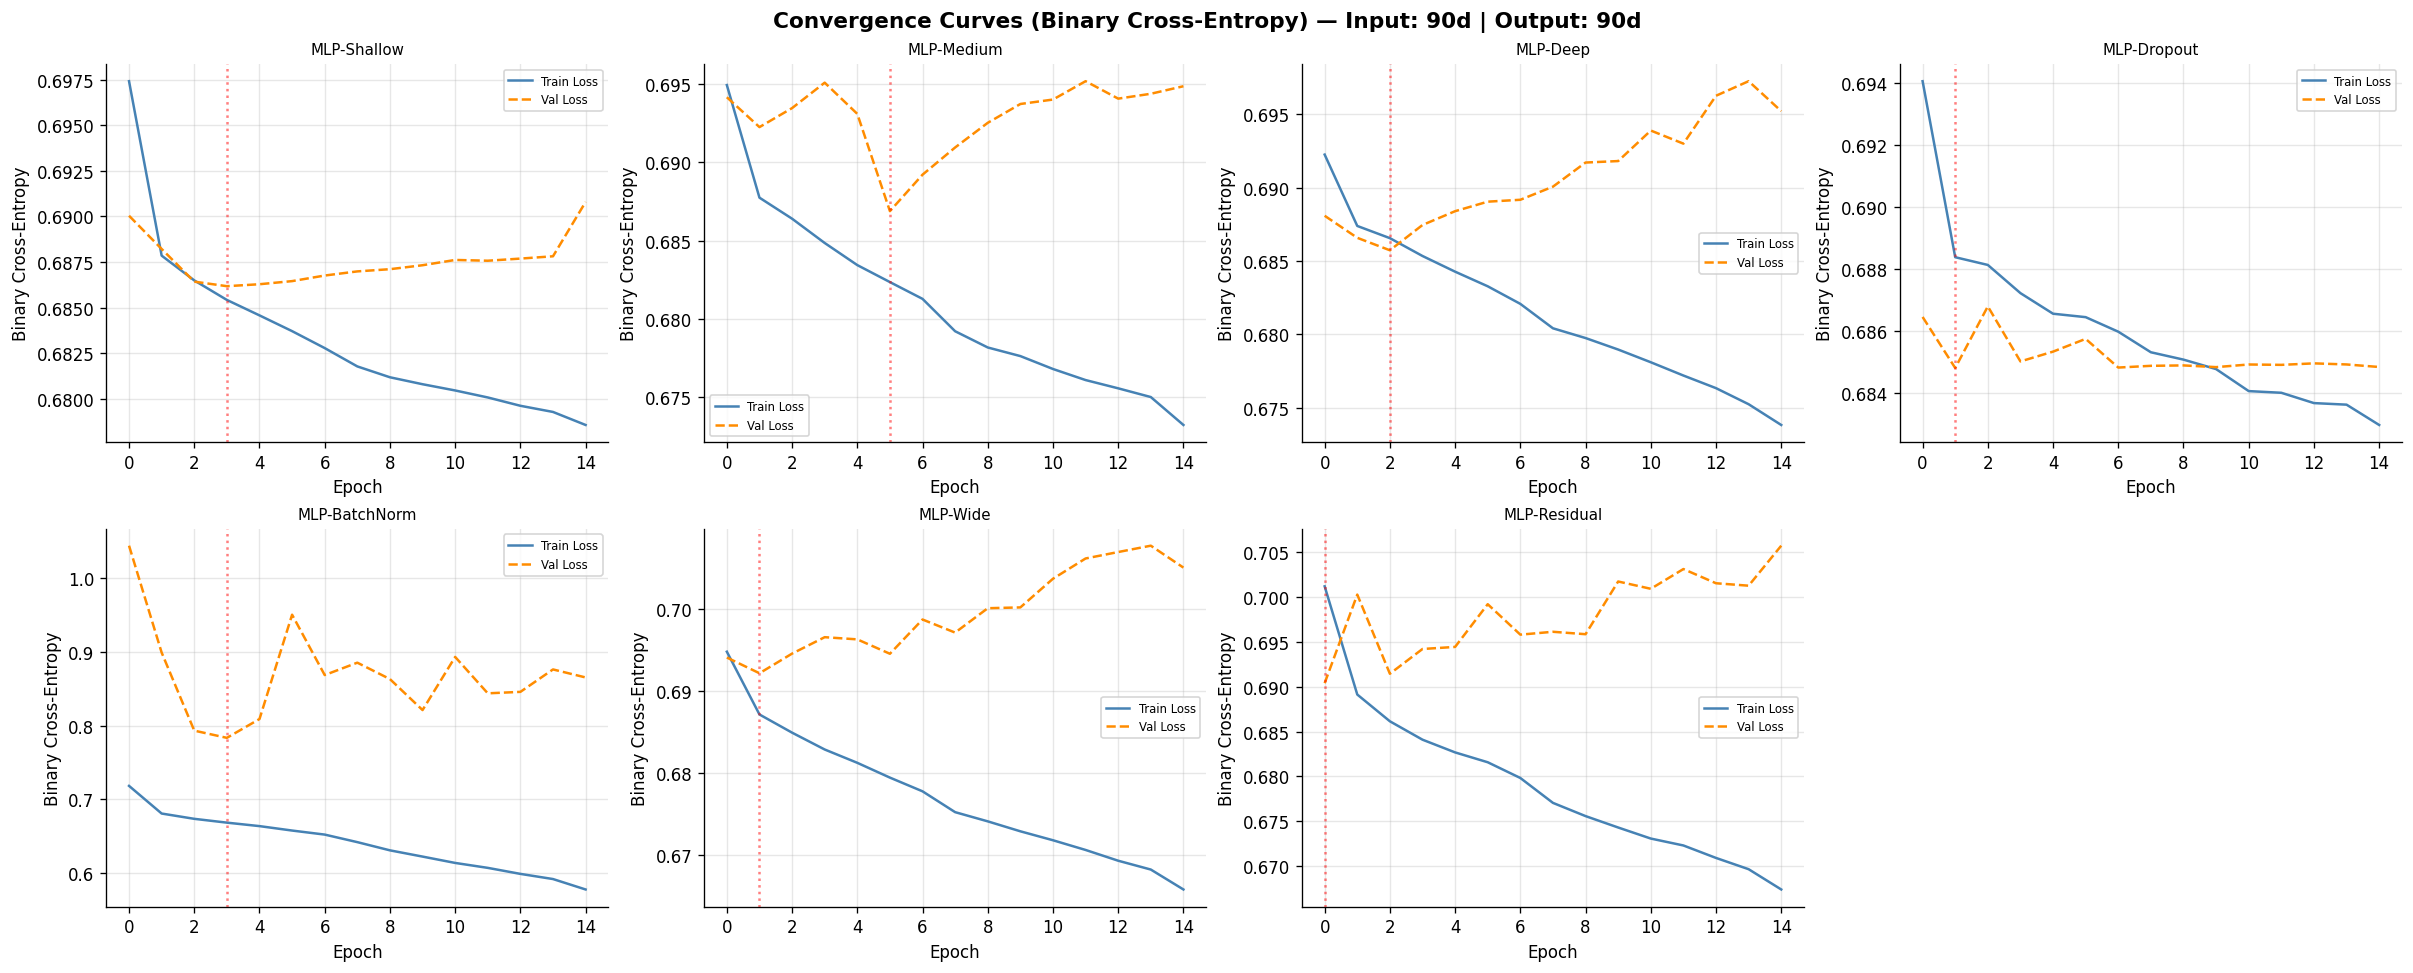

In [14]:
model_names = list(MODEL_BUILDERS.keys())

for in_w in INPUT_WINDOWS:
    for out_w in OUTPUT_WINDOWS:
        fig, axes = plt.subplots(2, 4, figsize=(20, 8), constrained_layout=True)
        fig.suptitle(
            f'Convergence Curves (Binary Cross-Entropy) — Input: {in_w}d | Output: {out_w}d',
            fontsize=13, fontweight='bold'
        )
        axes[1, 3].set_visible(False)

        for ax, mn in zip(axes.flat[:7], model_names):
            hist = histories_inv.get((in_w, out_w, mn), {})
            if hist:
                ax.plot(hist['loss'],     color='steelblue',  lw=1.5, label='Train Loss')
                ax.plot(hist['val_loss'], color='darkorange', lw=1.5, ls='--', label='Val Loss')
                ax.axvline(np.argmin(hist['val_loss']), color='red', alpha=0.5, ls=':')
                ax.set_title(mn, fontsize=9)
                ax.set_xlabel('Epoch'); ax.set_ylabel('Binary Cross-Entropy')
                ax.legend(fontsize=7)

        fname = f'figuras_inv/convergencia/conv_in{in_w}_out{out_w}.png'
        plt.savefig(fname, dpi=110, bbox_inches='tight')
        plt.show()

## 9. Tablas de resultados por combinación (Accuracy)

In [15]:
results_inv_df = pd.DataFrame(results_inv)

for in_w in INPUT_WINDOWS:
    for out_w in OUTPUT_WINDOWS:
        sub = results_inv_df[
            (results_inv_df['in_window'] == in_w) &
            (results_inv_df['out_window'] == out_w)
        ].copy().sort_values('acc_test', ascending=False)  # mayor accuracy primero

        if sub.empty: continue
        best_name = best_models_inv.get((in_w, out_w), (None,))[0]

        print(f'\n{"─"*75}')
        print(f'  Entrada={in_w}d | Salida={out_w}d  '
              f'[FFD + Triple Barrera + Purged K-Fold | Clasificación Binaria]')
        print(f'{"─"*75}')

        disp = sub[['model', 'params', 'acc_val', 'acc_val_std', 'acc_test']].rename(columns={
            'model': 'Modelo', 'params': '# Params',
            'acc_val': 'Acc Val (PKF)', 'acc_val_std': 'Std Val',
            'acc_test': 'Acc Test'
        })
        for col in ['Acc Val (PKF)', 'Std Val', 'Acc Test']:
            disp[col] = disp[col].map('{:.4f}'.format)
        disp['# Params'] = disp['# Params'].map('{:,}'.format)

        def highlight_best(row):
            if row['Modelo'] == best_name:
                return ['font-weight: bold; text-decoration: underline'] * len(row)
            return [''] * len(row)

        display(disp.style.apply(highlight_best, axis=1))

print('\n✓ Tablas generadas.')


───────────────────────────────────────────────────────────────────────────
  Entrada=5d | Salida=1d  [FFD + Triple Barrera + Purged K-Fold | Clasificación Binaria]
───────────────────────────────────────────────────────────────────────────


,Modelo,# Params,Acc Val (PKF),Std Val,Acc Test
0,Historical UP Rate,0,0.9329,0.0000,0.9329
1,MLP-Shallow,"17,815",0.9239,0.0042,0.9329
2,MLP-Medium,"65,559",0.9239,0.0042,0.9329
3,MLP-Deep,"233,367",0.9239,0.0042,0.9329
4,MLP-Dropout,"131,351",0.9239,0.0042,0.9329
6,MLP-Wide,"655,383",0.9239,0.0042,0.9329
7,MLP-Residual,"298,775",0.9239,0.0042,0.9329
5,MLP-BatchNorm,"133,911",0.9239,0.0042,0.7248



───────────────────────────────────────────────────────────────────────────
  Entrada=5d | Salida=5d  [FFD + Triple Barrera + Purged K-Fold | Clasificación Binaria]
───────────────────────────────────────────────────────────────────────────


,Modelo,# Params,Acc Val (PKF),Std Val,Acc Test
8,Historical UP Rate,0,0.6394,0.0000,0.6394
9,MLP-Shallow,"17,815",0.6334,0.0042,0.6394
10,MLP-Medium,"65,559",0.6341,0.0034,0.6394
11,MLP-Deep,"233,367",0.6348,0.0037,0.6394
12,MLP-Dropout,"131,351",0.6348,0.0037,0.6394
14,MLP-Wide,"655,383",0.6344,0.0035,0.6394
15,MLP-Residual,"298,775",0.6331,0.0041,0.6394
13,MLP-BatchNorm,"133,911",0.6151,0.0138,0.5591



───────────────────────────────────────────────────────────────────────────
  Entrada=5d | Salida=30d  [FFD + Triple Barrera + Purged K-Fold | Clasificación Binaria]
───────────────────────────────────────────────────────────────────────────


...


───────────────────────────────────────────────────────────────────────────
  Entrada=90d | Salida=30d  [FFD + Triple Barrera + Purged K-Fold | Clasificación Binaria]
───────────────────────────────────────────────────────────────────────────


,Modelo,# Params,Acc Val (PKF),Std Val,Acc Test
112,Historical UP Rate,0,0.5486,0.0000,0.5486
116,MLP-Dropout,"631,831",0.5474,0.0130,0.5486
113,MLP-Shallow,"268,055",0.5399,0.0147,0.5473
115,MLP-Deep,"1,234,327",0.5403,0.0160,0.5438
119,MLP-Residual,"799,255",0.5324,0.0071,0.5357
118,MLP-Wide,"2,657,303",0.5361,0.0114,0.5341
114,MLP-Medium,"566,039",0.5379,0.0133,0.5273
117,MLP-BatchNorm,"634,391",0.5054,0.0106,0.5015



───────────────────────────────────────────────────────────────────────────
  Entrada=90d | Salida=90d  [FFD + Triple Barrera + Purged K-Fold | Clasificación Binaria]
───────────────────────────────────────────────────────────────────────────


,Modelo,# Params,Acc Val (PKF),Std Val,Acc Test
120,Historical UP Rate,0,0.5469,0.0000,0.5469
124,MLP-Dropout,"631,831",0.5518,0.0141,0.5469
123,MLP-Deep,"1,234,327",0.5440,0.0093,0.5459
122,MLP-Medium,"566,039",0.5394,0.0095,0.5403
126,MLP-Wide,"2,657,303",0.5386,0.0090,0.5381
127,MLP-Residual,"799,255",0.5268,0.0162,0.5310
121,MLP-Shallow,"268,055",0.5469,0.0152,0.5261
125,MLP-BatchNorm,"634,391",0.5096,0.0266,0.4859



✓ Tablas generadas.


## 10. Gráficas comparativas por combinación

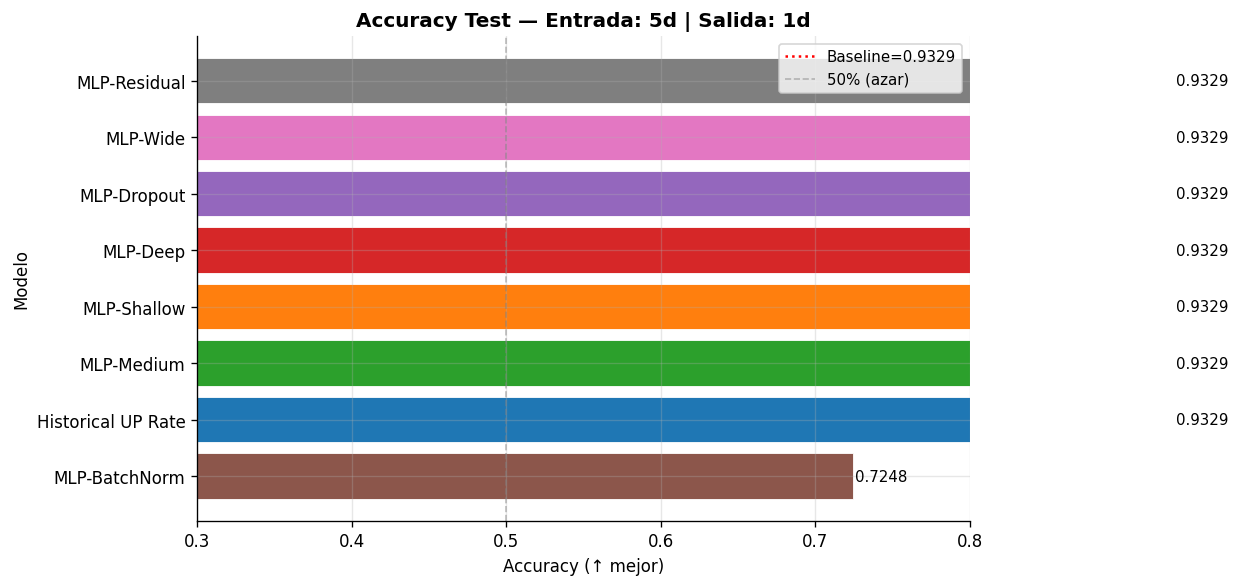

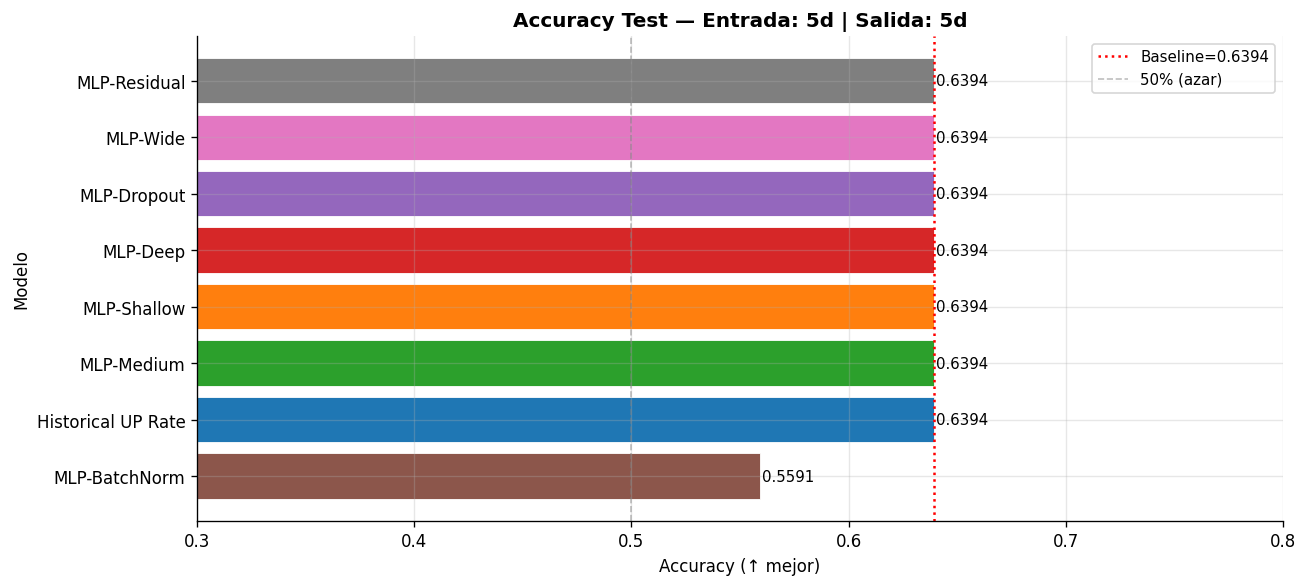

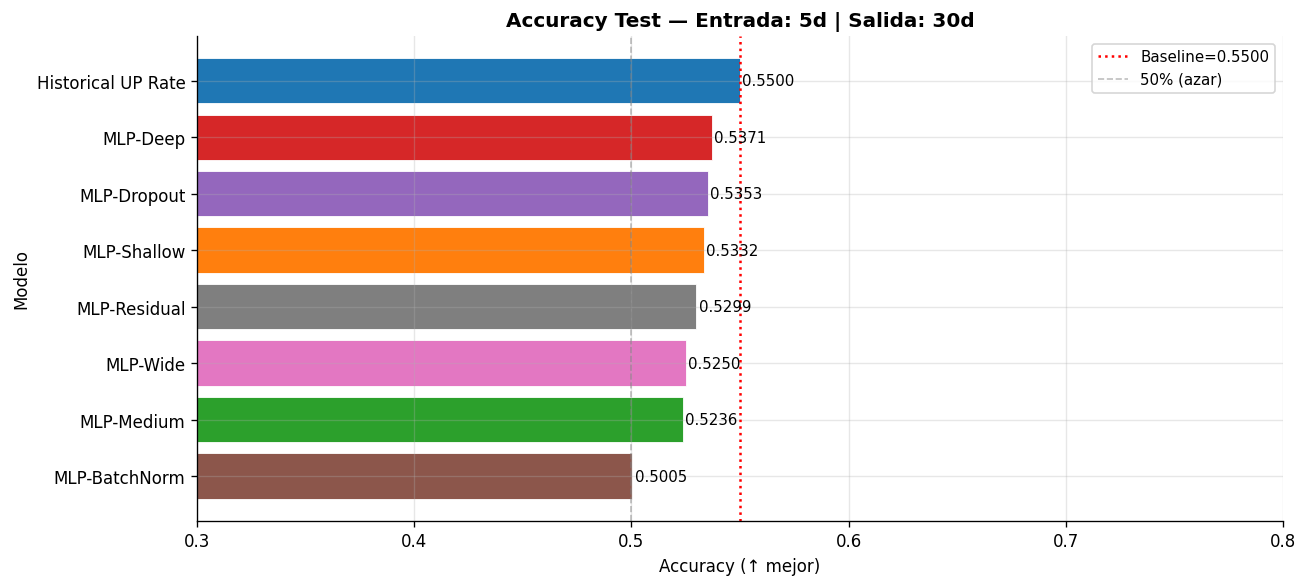

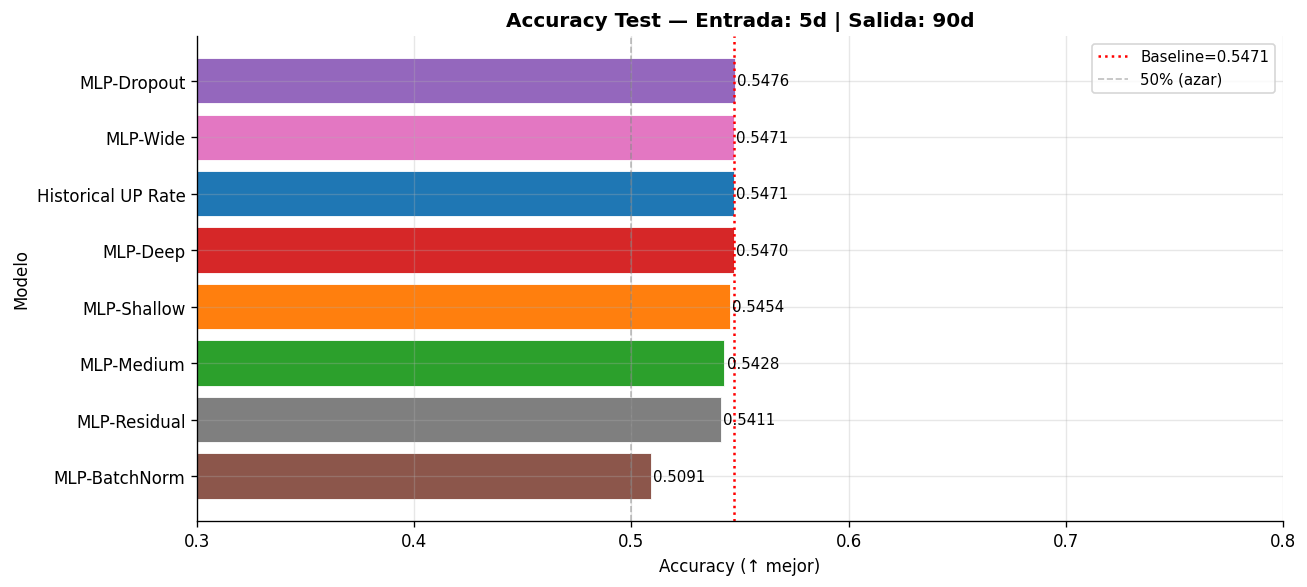

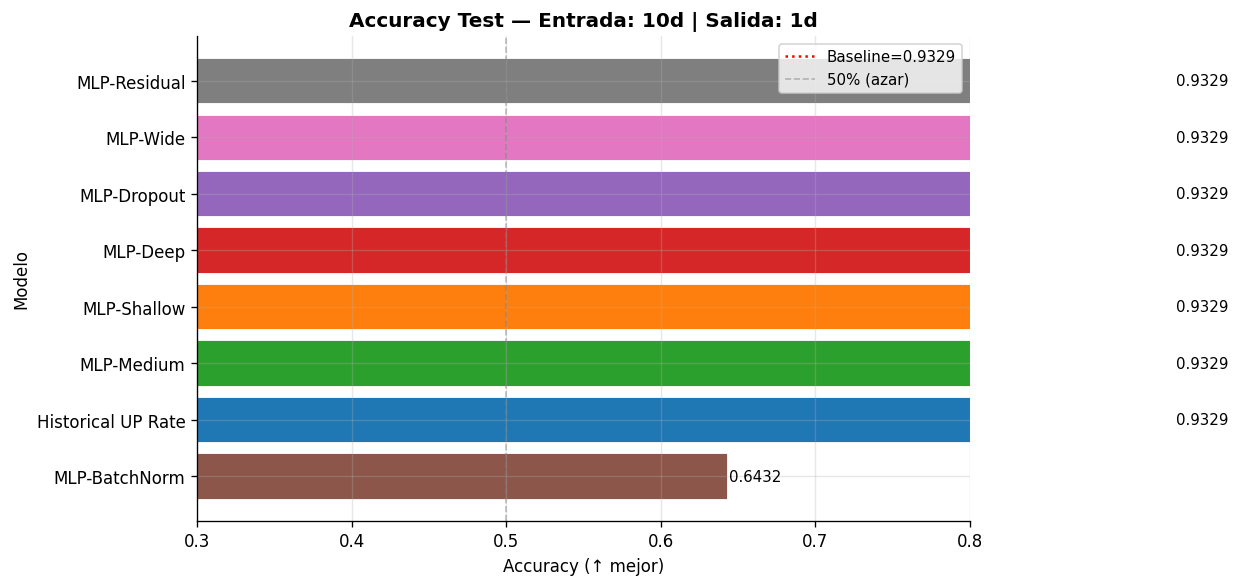

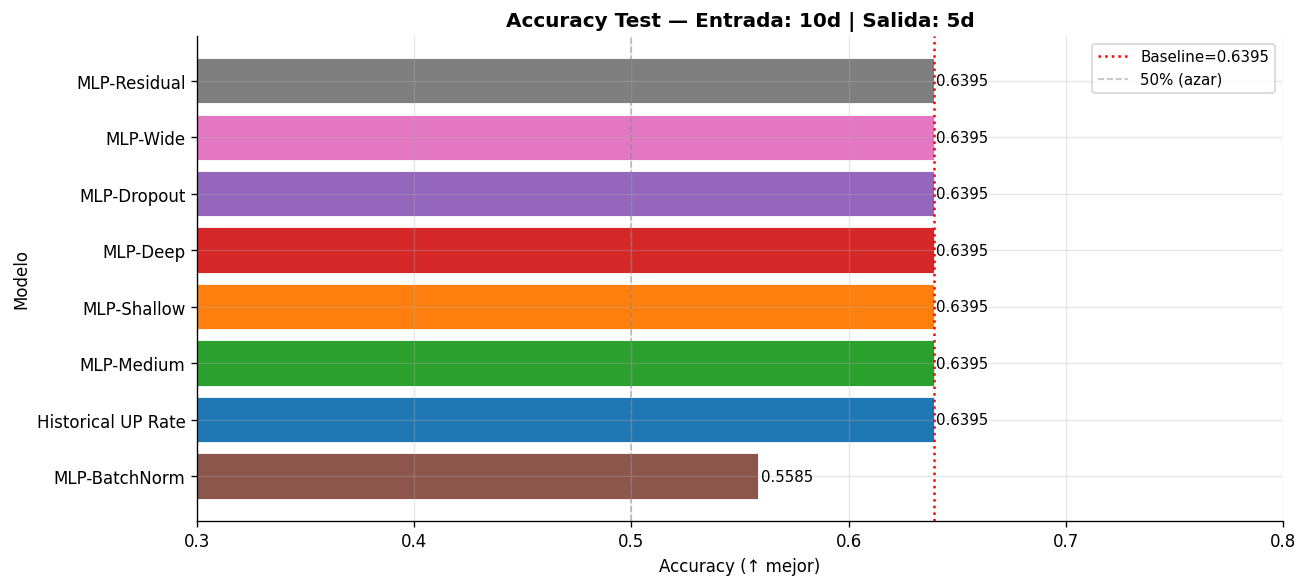

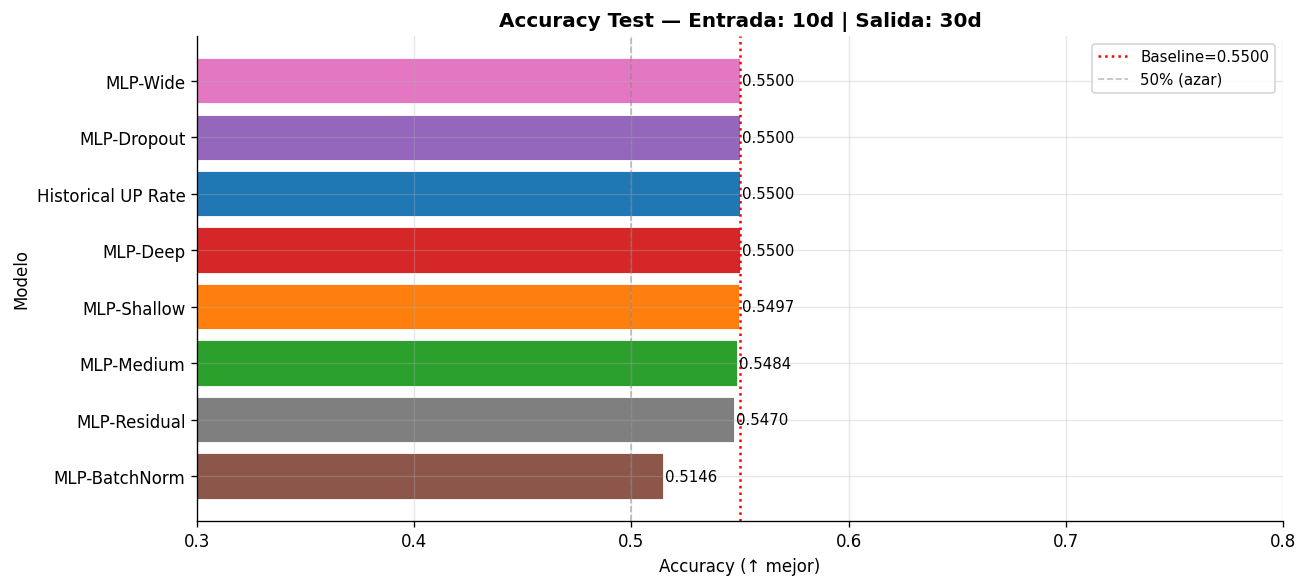

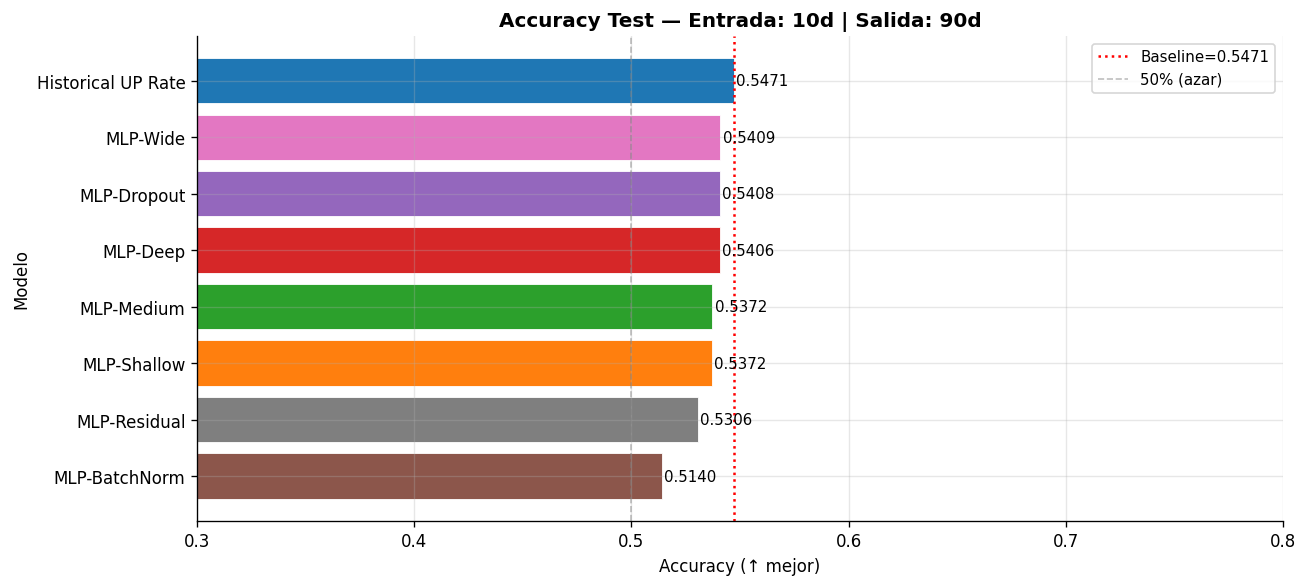

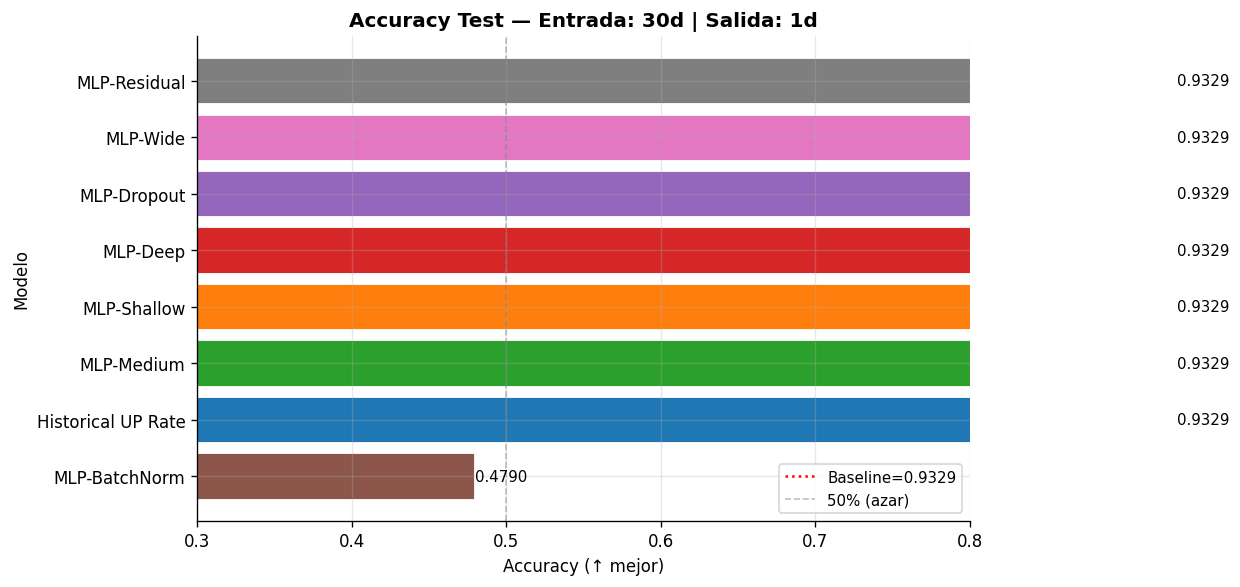

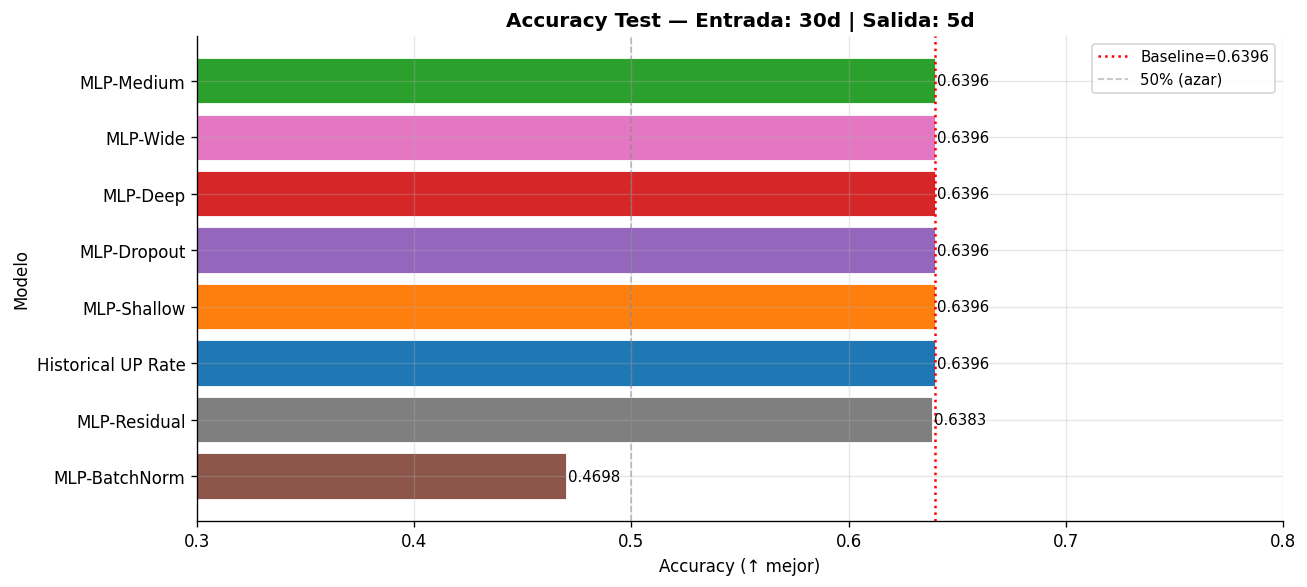

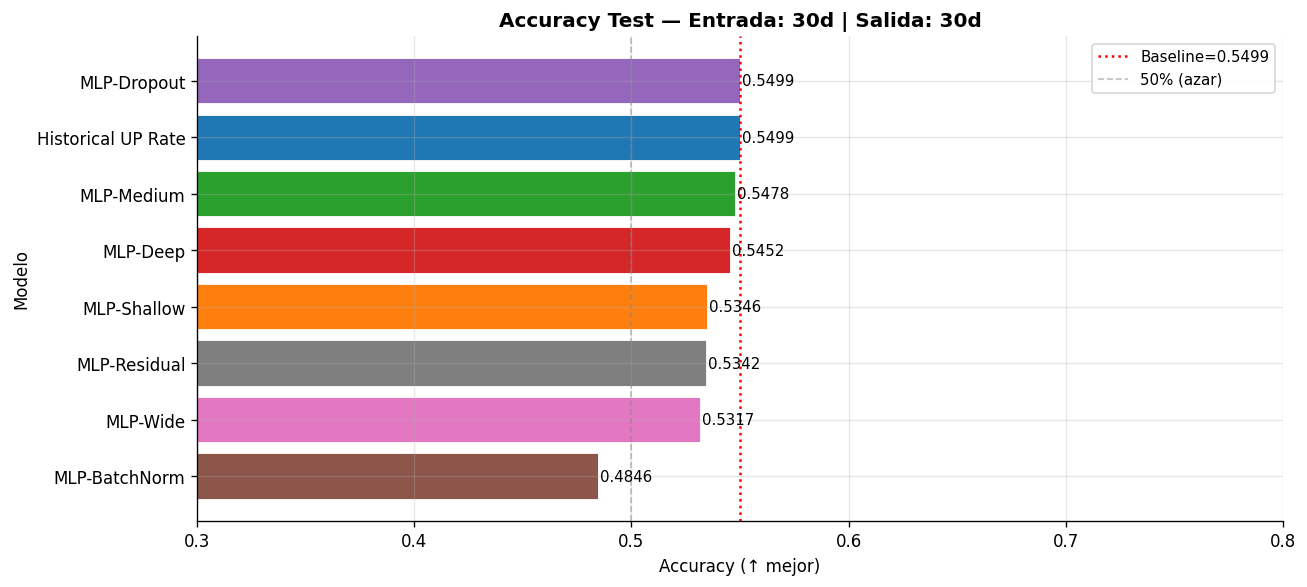

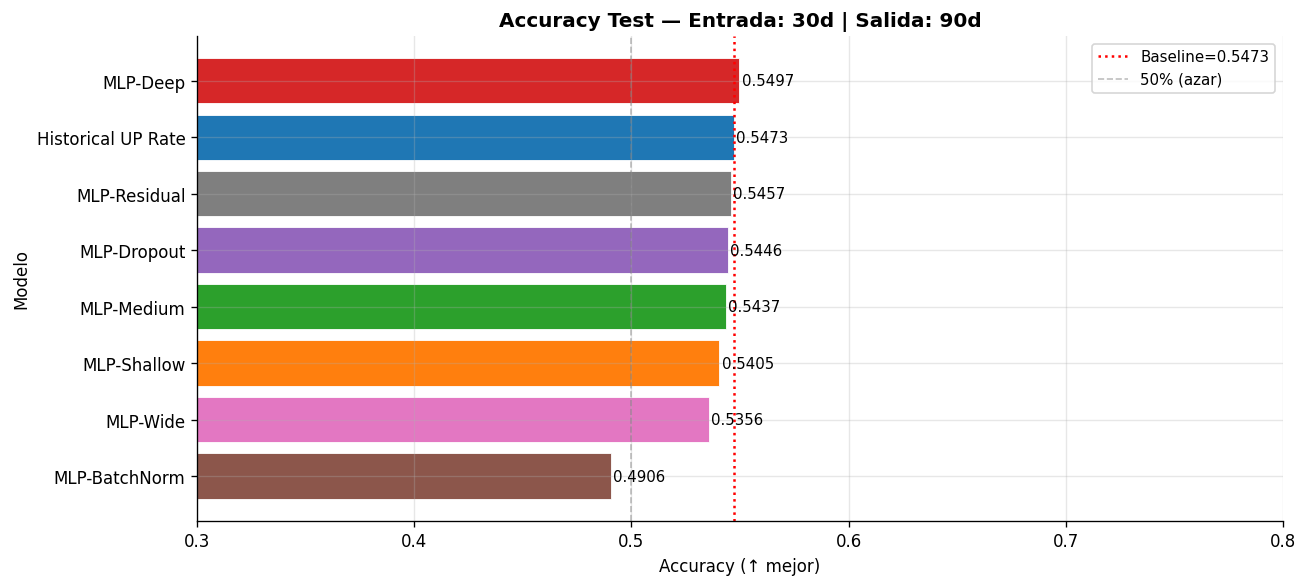

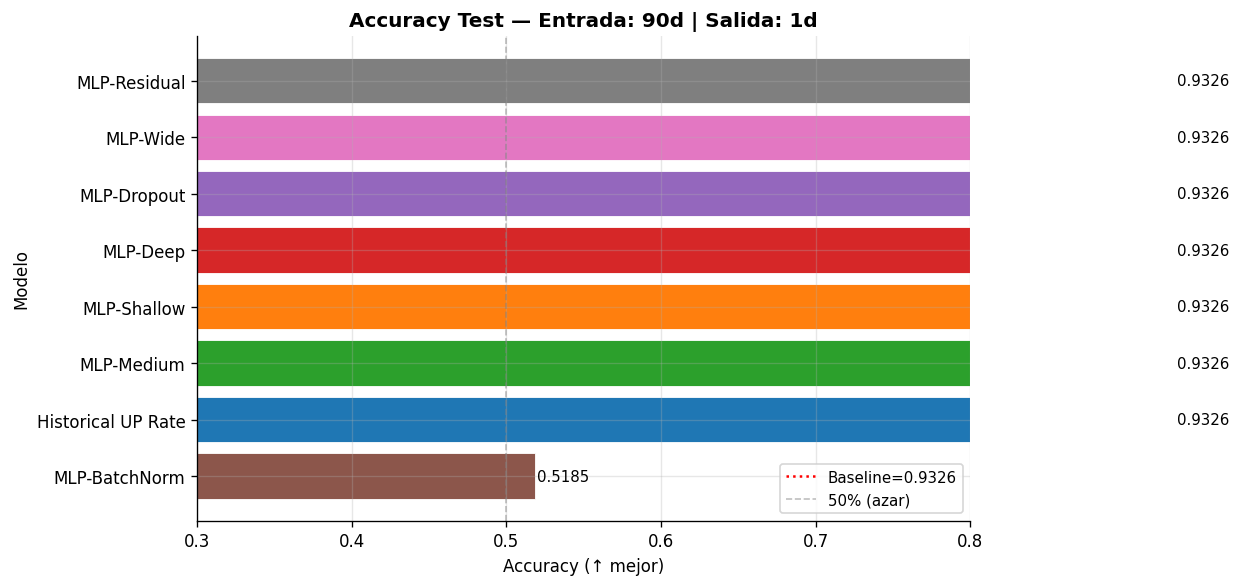

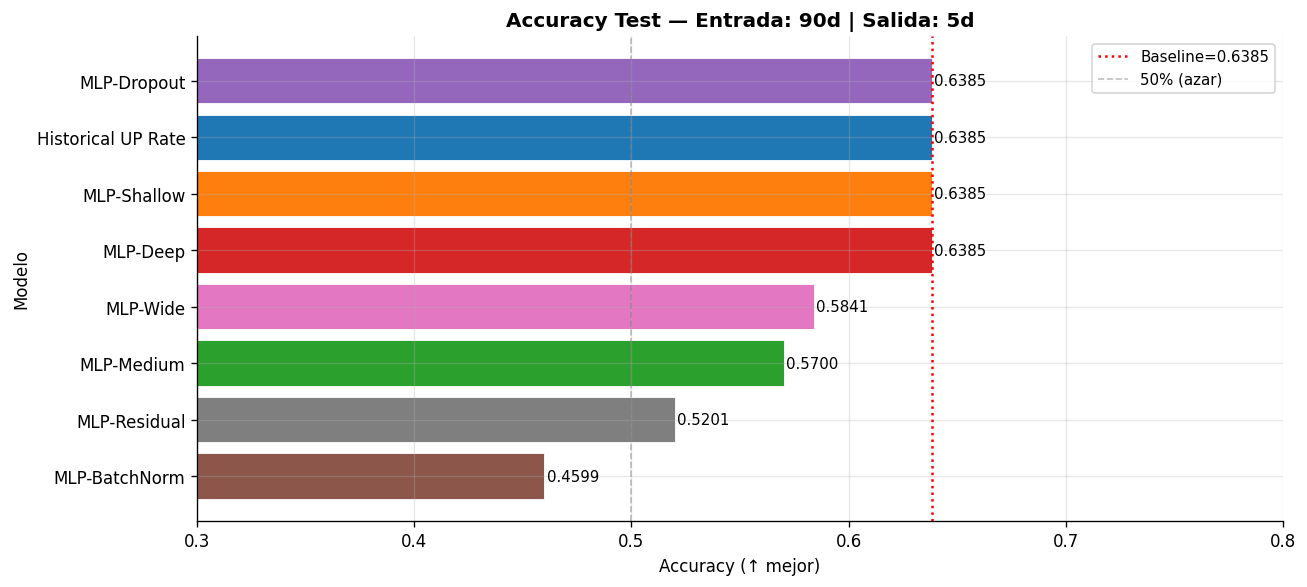

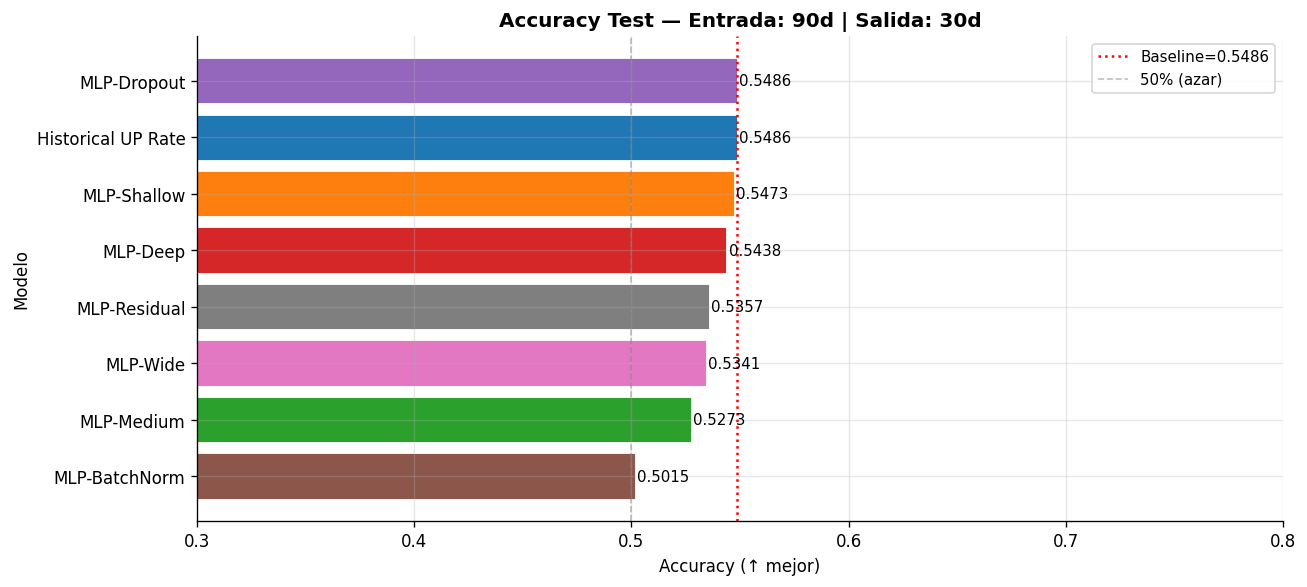

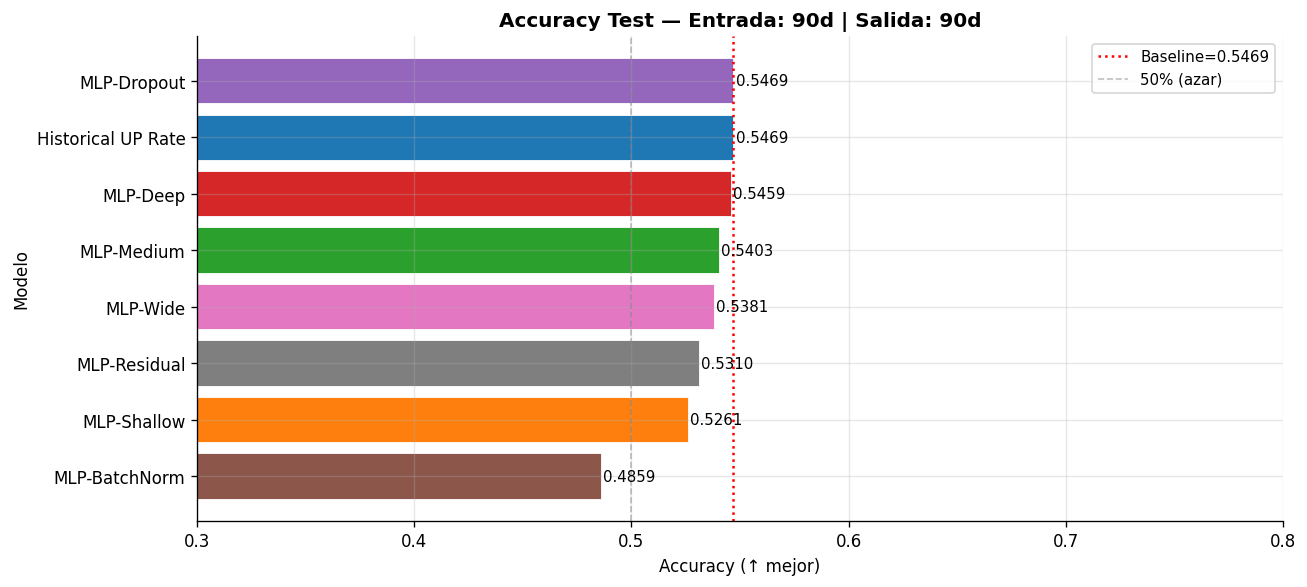

✓ 16 gráficas de comparación generadas.


In [16]:
MODEL_ORDER  = ['Historical UP Rate'] + list(MODEL_BUILDERS.keys())
palette      = plt.cm.tab10.colors
color_map    = {m: palette[i % len(palette)] for i, m in enumerate(MODEL_ORDER)}

for in_w in INPUT_WINDOWS:
    for out_w in OUTPUT_WINDOWS:
        sub = results_inv_df[
            (results_inv_df['in_window'] == in_w) &
            (results_inv_df['out_window'] == out_w)
        ].sort_values('acc_test', ascending=True)  # menor primero para barh

        if sub.empty: continue

        fig, ax = plt.subplots(figsize=(11, 5))
        bars = ax.barh(
            sub['model'], sub['acc_test'],
            color=[color_map.get(m, 'gray') for m in sub['model']],
            edgecolor='white', linewidth=0.5
        )
        for bar, val in zip(bars, sub['acc_test']):
            ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', ha='left', fontsize=9)

        # Línea de referencia: baseline
        baseline_val = sub[sub['model'] == 'Historical UP Rate']['acc_test'].values
        if len(baseline_val) > 0:
            ax.axvline(baseline_val[0], color='red', ls=':', lw=1.5,
                       label=f'Baseline={baseline_val[0]:.4f}')
        ax.axvline(0.5, color='gray', ls='--', lw=1, alpha=0.5, label='50% (azar)')

        ax.set_title(f'Accuracy Test — Entrada: {in_w}d | Salida: {out_w}d',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Accuracy (↑ mejor)')
        ax.set_ylabel('Modelo')
        ax.legend(fontsize=9); ax.set_xlim(0.3, 0.8)

        plt.tight_layout()
        fname = f'figuras_inv/comparacion_in{in_w}_out{out_w}.png'
        plt.savefig(fname, dpi=120, bbox_inches='tight')
        plt.show()

print('✓ 16 gráficas de comparación generadas.')

## 11. Matriz de competición — Investigación (Accuracy)

MATRIZ COMPETICIÓN — Investigación López de Prado
Métrica: Accuracy (↑ mejor) | Binary Cross-Entropy | Purged K-Fold
             Salida 1d  Salida 5d  Salida 30d  Salida 90d
Entrada 5d      0.9329     0.6394      0.5500      0.5476
Entrada 10d     0.9329     0.6395      0.5500      0.5471
Entrada 30d     0.9329     0.6396      0.5499      0.5497
Entrada 90d     0.9326     0.6385      0.5486      0.5469


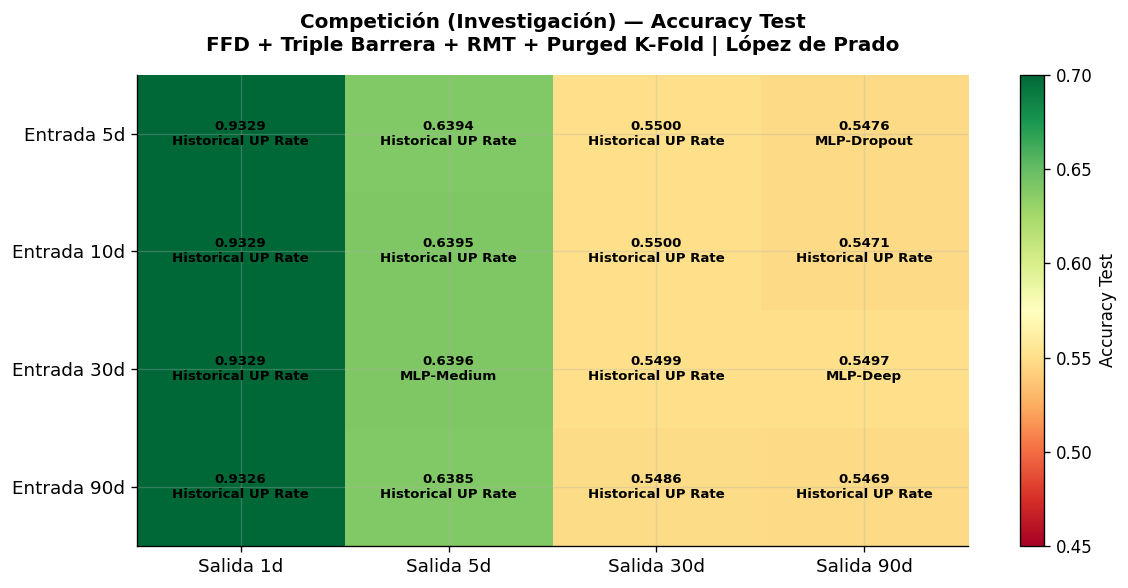

In [17]:
comp_mat  = pd.DataFrame(index=[f'Entrada {w}d' for w in INPUT_WINDOWS],
                         columns=[f'Salida {w}d' for w in OUTPUT_WINDOWS], dtype=float)
model_mat = comp_mat.copy().astype(str)

for in_w in INPUT_WINDOWS:
    for out_w in OUTPUT_WINDOWS:
        sub = results_inv_df[
            (results_inv_df['in_window'] == in_w) &
            (results_inv_df['out_window'] == out_w)
        ]
        if sub.empty: continue
        br = sub.loc[sub['acc_test'].idxmax()]   # mayor accuracy
        comp_mat.loc[f'Entrada {in_w}d', f'Salida {out_w}d']  = br['acc_test']
        model_mat.loc[f'Entrada {in_w}d', f'Salida {out_w}d'] = br['model']

print('MATRIZ COMPETICIÓN — Investigación López de Prado')
print('Métrica: Accuracy (↑ mejor) | Binary Cross-Entropy | Purged K-Fold')
print(comp_mat.to_string(float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(10, 5))
mat = comp_mat.values.astype(float)
# RdYlGn (no invertido): verde = accuracy alta
im  = ax.imshow(mat, cmap='RdYlGn', aspect='auto', vmin=0.45, vmax=0.70)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels([f'Salida {w}d' for w in OUTPUT_WINDOWS], fontsize=11)
ax.set_yticklabels([f'Entrada {w}d' for w in INPUT_WINDOWS], fontsize=11)
ax.set_title(
    'Competición (Investigación) — Accuracy Test\n'
    'FFD + Triple Barrera + RMT + Purged K-Fold | López de Prado',
    fontsize=12, fontweight='bold', pad=14
)
for i in range(4):
    for j in range(4):
        if not np.isnan(mat[i, j]):
            ax.text(j, i, f"{mat[i,j]:.4f}\n{model_mat.iloc[i,j]}",
                    ha='center', va='center', fontsize=8, fontweight='bold')
plt.colorbar(im, ax=ax, label='Accuracy Test')
plt.tight_layout()
plt.savefig('figuras_inv/matriz_competicion_inv.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Carteras 2025: Buy & Hold vs MLP-guided

El mejor modelo de salida=90d predice la **probabilidad de UP** para cada activo a 90 días. Usamos estas probabilidades para construir la cartera B:

| Cartera | Descripción |
|---|---|
| **A — Buy & Hold** | Igual peso en todos los activos, sin rebalanceo |
| **B — MLP-guided** | Rebalanceo mensual: largo en activos con p(UP)>0.5, pesos de mínima varianza con **covarianza RMT-limpia** |

In [18]:
print(f'Mejor modelo 90d: {best_name_90d} '
      f'(entrada {best_in_w_90d}d | Acc={best_acc_90d:.4f})')

TICKERS_COM      = [t for t in TICKERS if t in close_2025.columns]
ret_2025_com     = returns_2025[TICKERS_COM].fillna(0)
close_2025_com   = close_2025[TICKERS_COM]
log_2025_com     = np.log(close_2025_com)
print(f'Activos comunes en 2025: {len(TICKERS_COM)} | Días: {len(ret_2025_com)}')

# FFD sobre historia completa + 2025 (para tener contexto previo)
log_full = pd.concat([
    log_prices_base[TICKERS_COM],
    log_2025_com
]).sort_index()
log_full = log_full[~log_full.index.duplicated(keep='first')]

ffd_full = pd.DataFrame(
    {t: frac_diff_ffd(log_full[t], d_star_dict.get(t, 0.4)) for t in TICKERS_COM}
).dropna()
ffd_2025_full = ffd_full[ffd_full.index >= '2025-01-01']

print(f'Días 2025 disponibles en FFD: {len(ffd_2025_full)}')

Mejor modelo 90d: MLP-Deep (entrada 30d | Acc=0.5497)
Activos comunes en 2025: 23 | Días: 341
Días 2025 disponibles en FFD: 342


In [19]:
# Generar probabilidades diarias de UP para cada activo en 2025
predictions = []  # {'date': ..., ticker: prob_UP, ...}
in_w_best   = best_in_w_90d

for date in ffd_2025_full.index:
    pos = ffd_full.index.get_loc(date)
    if pos < in_w_best: continue
    window = ffd_full.iloc[pos - in_w_best : pos][TICKERS_COM].values  # (in_w, N)
    X_pred = window.flatten().reshape(1, -1)
    prob_up = best_model_90d.predict(X_pred, verbose=0)[0]  # (N,) probabilidades
    predictions.append({'date': date, **dict(zip(TICKERS_COM, prob_up))})

predictions_df = pd.DataFrame(predictions).set_index('date')
print(f'Predicciones p(UP) generadas: {len(predictions_df)} fechas')
print(f'Media p(UP) global: {predictions_df.mean().mean():.3f}')

Predicciones p(UP) generadas: 342 fechas
Media p(UP) global: 0.584


In [20]:
# Covarianza RMT-limpia para los activos comunes
tk_idx    = [TICKERS.index(t) for t in TICKERS_COM if t in TICKERS]
cov_sub   = cov_clean[np.ix_(tk_idx, tk_idx)]
N_PORT    = len(TICKERS_COM)

def min_variance_weights(prob_up, cov_matrix, threshold=0.5):
    """
    Cartera de mínima varianza long-only sobre activos con p(UP) > threshold.
    Pesos proporcionales a (p - threshold) para dar más peso a señales fuertes.
    """
    long_mask = prob_up > threshold
    if long_mask.sum() == 0:
        return np.ones(len(prob_up)) / len(prob_up)

    cov_l = cov_matrix[np.ix_(long_mask, long_mask)]
    n_l   = long_mask.sum()
    w0    = np.ones(n_l) / n_l

    result = minimize(
        lambda w: w @ cov_l @ w, w0,
        method='SLSQP',
        bounds=[(0, 1)] * n_l,
        constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}],
        options={'ftol': 1e-9, 'maxiter': 1000}
    )
    w_full = np.zeros(len(prob_up))
    w_full[long_mask] = result.x
    return w_full


# Simular carteras
dates_2025   = ret_2025_com.index
arr_2025     = ret_2025_com.values
w_bh         = np.ones(N_PORT) / N_PORT

# Días de rebalanceo: primero de cada mes
rebal_dates = set(
    dates_2025.to_series().groupby(dates_2025.to_period('M')).first().values
)

pa = np.zeros(len(dates_2025))  # Cartera A: Buy & Hold
pb = np.zeros(len(dates_2025))  # Cartera B: MLP-guided
w_b = w_bh.copy()

for i, date in enumerate(dates_2025):
    if date in rebal_dates and date in predictions_df.index:
        prob_up = predictions_df.loc[date, TICKERS_COM].values.astype(float)
        w_b = min_variance_weights(prob_up, cov_sub)
    pa[i] = arr_2025[i] @ w_bh
    pb[i] = arr_2025[i] @ w_b

cum_a = np.exp(np.cumsum(pa)) - 1
cum_b = np.exp(np.cumsum(pb)) - 1

print(f'Retorno acumulado 2025:')
print(f'  A (Buy & Hold) : {cum_a[-1]*100:+.2f}%')
print(f'  B (MLP-guided) : {cum_b[-1]*100:+.2f}%')

Retorno acumulado 2025:
  A (Buy & Hold) : +21.76%
  B (MLP-guided) : +27.68%


── Métricas Carteras 2025 ──


,Ret. Acum. (%),Ret. Anual. (%),Vol. Anual. (%),Sharpe,Max DD (%)
Cartera,,,,,
Buy & Hold (igual peso),21.76,14.55,13.15,1.106,-11.33
MLP-Deep + RMT | p(UP)>0.5,27.68,18.06,13.64,1.324,-7.42


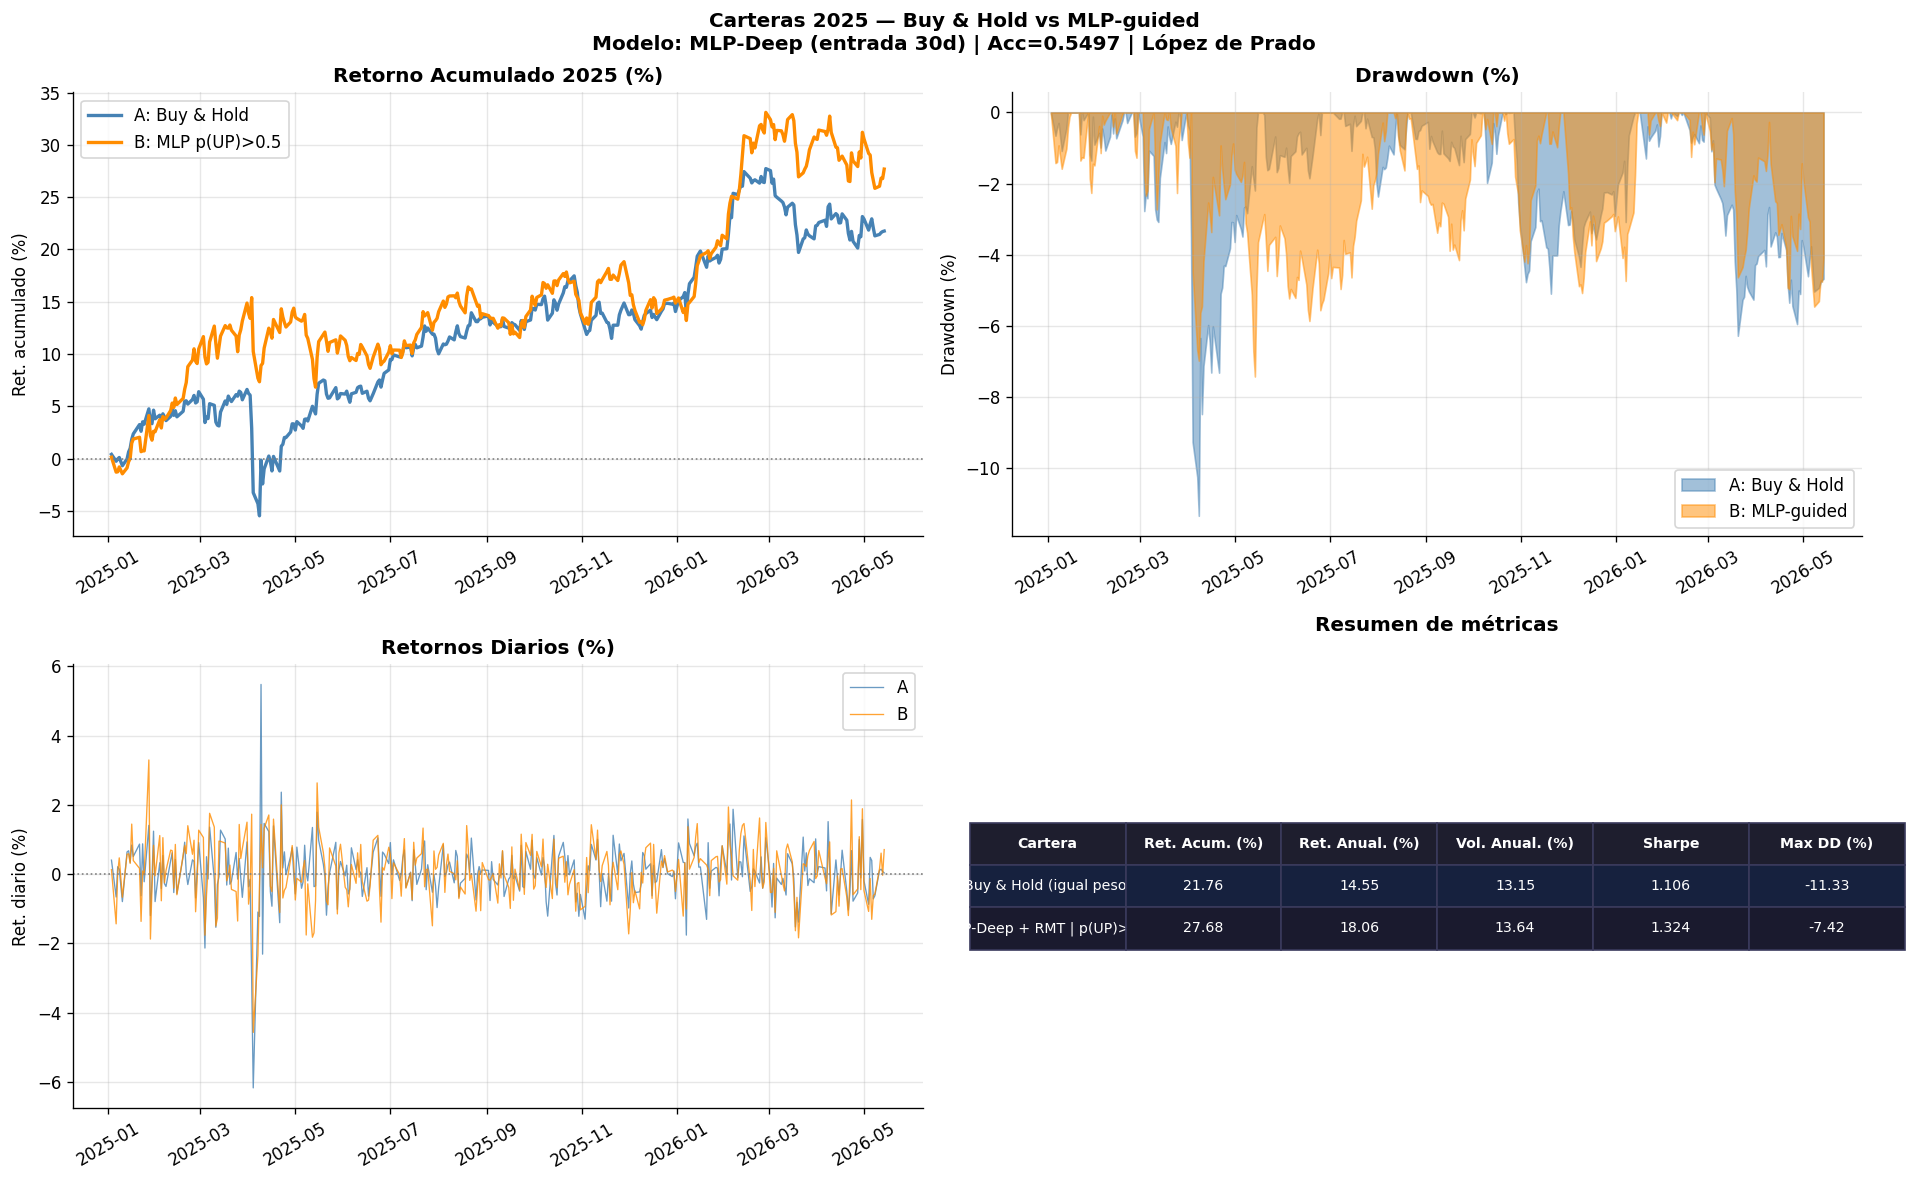

In [21]:
def port_metrics(r, name, td=252):
    ann_ret = np.sum(r) * td / max(len(r), 1)
    ann_vol = np.std(r) * np.sqrt(td)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0
    c       = np.exp(np.cumsum(r))
    pk      = np.maximum.accumulate(c)
    mdd     = ((c - pk) / pk).min()
    return {'Cartera': name,
            'Ret. Acum. (%)':  round((c[-1]-1)*100, 2),
            'Ret. Anual. (%)': round(ann_ret*100, 2),
            'Vol. Anual. (%)': round(ann_vol*100, 2),
            'Sharpe':          round(sharpe, 3),
            'Max DD (%)':      round(mdd*100, 2)}

m_a   = port_metrics(pa, 'Buy & Hold (igual peso)')
m_b   = port_metrics(pb, f'{best_name_90d} + RMT | p(UP)>0.5')
mdf   = pd.DataFrame([m_a, m_b]).set_index('Cartera')
print('── Métricas Carteras 2025 ──')
display(mdf)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    f'Carteras 2025 — Buy & Hold vs MLP-guided\n'
    f'Modelo: {best_name_90d} (entrada {best_in_w_90d}d) | '
    f'Acc={best_acc_90d:.4f} | López de Prado',
    fontsize=12, fontweight='bold'
)

ax = axes[0, 0]
ax.plot(dates_2025, cum_a*100, color='steelblue',  lw=2, label='A: Buy & Hold')
ax.plot(dates_2025, cum_b*100, color='darkorange', lw=2, label='B: MLP p(UP)>0.5')
ax.axhline(0, color='gray', ls=':', lw=1)
ax.set_title('Retorno Acumulado 2025 (%)', fontweight='bold')
ax.set_ylabel('Ret. acumulado (%)')
ax.legend(); ax.tick_params(axis='x', rotation=30)

def dd(r):
    c = np.exp(np.cumsum(r)); pk = np.maximum.accumulate(c)
    return (c - pk) / pk * 100

ax = axes[0, 1]
ax.fill_between(dates_2025, dd(pa), 0, alpha=0.5, color='steelblue',  label='A: Buy & Hold')
ax.fill_between(dates_2025, dd(pb), 0, alpha=0.5, color='darkorange', label='B: MLP-guided')
ax.set_title('Drawdown (%)', fontweight='bold')
ax.set_ylabel('Drawdown (%)'); ax.legend(); ax.tick_params(axis='x', rotation=30)

ax = axes[1, 0]
ax.plot(dates_2025, pa*100, color='steelblue',  lw=0.8, alpha=0.8, label='A')
ax.plot(dates_2025, pb*100, color='darkorange', lw=0.8, alpha=0.8, label='B')
ax.axhline(0, color='gray', ls=':', lw=1)
ax.set_title('Retornos Diarios (%)', fontweight='bold')
ax.set_ylabel('Ret. diario (%)'); ax.legend(); ax.tick_params(axis='x', rotation=30)

ax = axes[1, 1]; ax.axis('off')
tbl = ax.table(
    cellText=[[str(v) for v in row]
              for row in mdf.reset_index().values.tolist()],
    colLabels=['Cartera'] + list(mdf.columns),
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1.1, 2.0)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#3a3a5c')
    if r == 0:
        cell.set_facecolor('#1e1e2e')
        cell.get_text().set_color('white')
        cell.get_text().set_fontweight('bold')
    else:
        cell.set_facecolor('#1a1a2e' if r % 2 == 0 else '#16213e')
        cell.get_text().set_color('white')
ax.set_title('Resumen de métricas', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('figuras_inv/carteras_2025.png', dpi=130, bbox_inches='tight')
plt.show()

## 13. Exportar resultados

In [22]:
results_inv_df.to_csv('resultados_investigacion_ldp.csv', index=False)
comp_mat.to_csv('matriz_competicion_investigacion.csv')
mdf.to_csv('metricas_carteras_2025.csv')

print('Archivos exportados:')
print('  · resultados_investigacion_ldp.csv')
print('  · matriz_competicion_investigacion.csv')
print('  · metricas_carteras_2025.csv')
print()
print('Pipeline López de Prado:')
print(f'  T1 Dollar Bars   : comparativa estadística (kurtosis)')
print(f'  T2 FFD           : d* medio = {d_star_s.mean():.3f} | features X')
print(f'  T3 RMT           : {n_signal}/{N_ASSETS} eigenvalores señal | covarianza carteras')
print(f'  T4 Triple Barrera: Y binaria | horizonte=output_window por combinación')
print(f'  T5 Purged K-Fold : 5 folds, embargo=input_window')
print()
print(f'Clasificación: Binary Cross-Entropy | Accuracy')
print(f'Mejor modelo 90d   : {best_name_90d} (entrada {best_in_w_90d}d | Acc={best_acc_90d:.4f})')
print(f'Retorno 2025 A (B&H): {cum_a[-1]*100:+.2f}%')
print(f'Retorno 2025 B (MLP): {cum_b[-1]*100:+.2f}%')

Archivos exportados:
  · resultados_investigacion_ldp.csv
  · matriz_competicion_investigacion.csv
  · metricas_carteras_2025.csv

Pipeline López de Prado:
  T1 Dollar Bars   : comparativa estadística (kurtosis)
  T2 FFD           : d* medio = 0.204 | features X
  T3 RMT           : 1/23 eigenvalores señal | covarianza carteras
  T4 Triple Barrera: Y binaria | horizonte=output_window por combinación
  T5 Purged K-Fold : 5 folds, embargo=input_window

Clasificación: Binary Cross-Entropy | Accuracy
Mejor modelo 90d   : MLP-Deep (entrada 30d | Acc=0.5497)
Retorno 2025 A (B&H): +21.76%
Retorno 2025 B (MLP): +27.68%
